# OLDER STUFF

In [1]:
import matplotlib.pyplot as plt

In [4]:
#general imports
import os
import sys
sys.path.insert(0, os.path.abspath('..'))

import starry2 as starry

# # Directory structure
# __file__ = os.path.abspath('') # __file__ is not defined in jupyter
# maindir    = os.path.dirname(os.path.realpath(__file__))
# libdir     = os.path.join(maindir, 'lib')

# # Lib imports
# sys.path.append(libdir)
# print(sys.path)

# import starry2 as starry
# import numpy as np
# import matplotlib.pyplot as plt
# import sklearn

# # import faulthandler
# # faulthandler.enable()

In [145]:
# np.show_config()

In [146]:
#Setting up colored print statements
class style():
    BLACK = '\033[30m'
    RED = '\033[31m'
    GREEN = '\033[32m'
    YELLOW = '\033[33m'
    BLUE = '\033[34m'
    MAGENTA = '\033[35m'
    CYAN = '\033[36m'
    WHITE = '\033[37m'
    UNDERLINE = '\033[4m'
    RESET = '\033[0m'

In [ ]:
# Directory structure
__file__ = os.path.abspath('') # __file__ is not defined in jupyter
maindir    = os.path.dirname(os.path.realpath(__file__))
libdir     = os.path.join(maindir, 'lib')

# Lib imports
sys.path.append(libdir)
print(sys.path)


['/Users/a.j.devaux/.pyenv/versions/3.10.17/lib/python310.zip', '/Users/a.j.devaux/.pyenv/versions/3.10.17/lib/python3.10', '/Users/a.j.devaux/.pyenv/versions/3.10.17/lib/python3.10/lib-dynload', '', '/Users/a.j.devaux/Downloads/Research/stellar_null_space/null_rv/.venv/lib/python3.10/site-packages', '/Users/a.j.devaux/Downloads/Research/stellar_null_space/null_rv/.venv/lib/python3.10/site-packages/mc3/lib/', '/Users/a.j.devaux/Downloads/Research/stellar_null_space/null_rv/.venv/lib/python3.10/site-packages/mc3/lib', '/Users/a.j.devaux/Downloads/Research/stellar_null_space/null_rv/lib', '/Users/a.j.devaux/Downloads/Research/stellar_null_space/null_rv/lib', '/Users/a.j.devaux/Downloads/Research/stellar_null_space/null_rv/lib', '/Users/a.j.devaux/Downloads/Research/stellar_null_space/null_rv/lib', '/Users/a.j.devaux/Downloads/Research/stellar_null_space/lib', '/Users/a.j.devaux/Downloads/Research/stellar_null_space/lib']


In [148]:
# py imports
import create_eigens
import create_emaps

In [149]:
starry.config.quiet = True

# Starry seems to have a lot of recursion
sys.setrecursionlimit(10000)

In [150]:
from jup_lib import utils
from jup_lib import fitclass as fc
from jup_lib import eigen
cfile = "eridani.cfg"

In [151]:
fit = fc.Fit()

print("\tReading the configuration file & data.")
fit.read_config(cfile)
cfg = fit.cfg
fit.read_data()

lmax = cfg.twod.lmax
nsamples = cfg.twod.nsamples

star = utils.initstar(fit, lmax)
star.map.inc = 90

	Reading the configuration file & data.


In [152]:
print("\tSetting up new directory")
m = fc.Map()
m.ncurves = cfg.twod.ncurves
m.lmax    = cfg.twod.lmax

	Setting up new directory


In [ ]:
fit.sflux = star.map.flux(theta=fit.t.shape)


eigeny, evalues, evectors, ecurves, lcs = \
        eigen.mkcurves(star, fit.t, m.lmax, fit.sflux, ncurves=m.ncurves, method=cfg.method, \
                 negative = cfg.negative, remove_y00 = cfg.remove_y00, \
                 all_curves = cfg.all_curves, factor_bool = cfg.factor_bool, start_l=cfg.start_l)

In [ ]:
def emaps(star, eigeny, outdir, proj='ortho', transparent=False, plot_name=None):
    ncurves, ny = eigeny.shape
    eigenmaps = []

    if proj == 'ortho':
        extent = (-90, 90, -90, 90)
        fname = 'emaps-ecl.png'
    elif proj == 'rect':
        extent = (-180, 180, -90, 90)
        fname = 'emaps-rect.png'
    elif proj == 'moll':
        extent = (-180, 180, -90, 90)
        fname = 'emaps-moll.png'

    if plot_name:
        fname = plot_name

    lmax = np.int(ny**0.5 - 1)

    ncols = np.int(np.sqrt(ncurves) // 1)
    nrows = np.int(ncurves // ncols + (ncurves % ncols != 0))
    npane = ncols * nrows

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, squeeze=False,
                             sharex=True, sharey=True)
    

    for j in range(ncurves):
        star.map[1:,:] = 0

        xloc = j %  ncols
        yloc = j // ncols
        ax = axes[yloc, xloc]
        
        yi = 1
        for l in range(1, lmax + 1):
            for m in range(-l, l + 1):
                star.map[l, m] = eigeny[j, yi]
                yi += 1

        ax.imshow(star.map.render(theta=0, projection=proj).eval(),
                  origin="lower",
                  cmap="plasma",
                  extent=extent)
    
    
        eigenmaps.append(star.map.render(theta=0, projection=proj).eval())

        # Axes are wrong for non-rectangular projections
        if proj == 'ortho' or proj == 'moll':
            ax.axis('off')

    # Empty subplots
    for j in range(ncurves, npane):
        xloc = j %  ncols
        yloc = j // ncols
        ax = axes[yloc, xloc]

        ax.axis('off')

    fig.tight_layout()
    plt.savefig(os.path.join(outdir, fname), transparent=transparent)
    plt.close(fig)

    return np.array(eigenmaps)

In [ ]:
test_curve = np.zeros((24,24))
blank = np.zeros((24,1))
np.fill_diagonal(test_curve,1)

In [ ]:
test_curve = np.concatenate((blank,test_curve),axis=1)

In [ ]:
maps = emaps(star, test_curve, "test_code", proj='rect', transparent=False, plot_name="testing-90.png")

In [ ]:
def eflux(star, eigeny, outdir, transparent=False):

    ncurves, ny = eigeny.shape

    lmax = int(ny**0.5 - 1)
    thet = np.linspace(0, 360, ny)

    fig, ax = plt.subplots(nrows=ncurves, ncols=1, figsize=(10, ncurves))

    for j in range(ncurves):
        star.map[1:,:] = 0
        yi = 1
        for l in range(1, lmax + 1):
            for mn in range(-l, l + 1):
                star.map[l, mn] = eigeny[j, yi]
                yi += 1
        
        ax[j].plot(star.map.flux(theta=thet).eval())
    
    fig.tight_layout()
    plt.savefig(f"{outdir}/light_curve-90", transparent=transparent)
    plt.close(fig)

In [ ]:
eflux(star, test_curve, "test_code", transparent=False)

In [ ]:
lcs.T.shape

In [ ]:
ecurves.T.shape

In [ ]:
lmax = cfg.twod.lmax
nsamples = cfg.twod.nsamples

In [ ]:
print("Finding rank of the ecurve design matrix")
lcs_A = lcs.T

lcs_R = np.empty((nsamples, lmax))

for k in range(nsamples):
    
    lcs_R[k] = [
        np.linalg.matrix_rank(lcs_A[:, : (l + 1) ** 2]) for l in range(1, lmax + 1)
    ]

lcs_R = np.median(lcs_R, axis=0) 
#Display rank for each spherical harmonic degree of the ecurve design matrix
print(f"The rank for each degree is {lcs_R} for lmax = {lmax}")  
print("----------------------------------------------------------------------------")

In [ ]:
ecurves.T.shape

In [ ]:
print("----------------------------------------------------------------------------")
print("Finding rank of the ecurve design matrix")
ecurve_A = ecurves.T

ecurve_R = np.empty((nsamples, lmax))

for k in range(nsamples):
    
    ecurve_R[k] = [
        np.linalg.matrix_rank(ecurve_A[:, : (l + 1) ** 2]) for l in range(1, lmax + 1)
    ]

ecurve_R = np.median(ecurve_R, axis=0) 
#Display rank for each spherical harmonic degree of the ecurve design matrix
print(f"The rank for each degree is {ecurve_R} for lmax = {lmax}")  
print("----------------------------------------------------------------------------")

In [ ]:
[np.linalg.matrix_rank(ecurve_A[:, : (l + 1) ** 2]) for l in range(1, lmax + 1)]

In [ ]:
ecurve_A[:, : (4 + 1) ** 2]

In [ ]:
ecurves.shape

In [ ]:
ecurves2 = np.loadtxt("eridani-outputs/pos-pca-3-results-90i/stored-eigens/ecurves.txt")

In [ ]:
print("----------------------------------------------------------------------------")
print("Finding rank of the ecurve design matrix")
ecurve_A = ecurves2.T

ecurve_R = np.empty((nsamples, lmax))

for k in range(nsamples):
    
    ecurve_R[k] = [
        np.linalg.matrix_rank(ecurve_A[:, : (l + 1) ** 2]) for l in range(1, lmax + 1)
    ]

ecurve_R = np.median(ecurve_R, axis=0) 
#Display rank for each spherical harmonic degree of the ecurve design matrix
print(f"The rank for each degree is {ecurve_R} for lmax = {lmax}")  
print("----------------------------------------------------------------------------")

In [ ]:
def pca(arr, method='pca', ncomp=None):
    """
    Runs principle component analysis on the input array.

    Arguments
    ---------
    arr: 2D array
        (m, n) array, where n is the size of the dataset (e.g., times
        in an observation) and m is the number of vectors

    Returns
    -------
    evalues: 1D array
        array of eigenvalues of size n

    evectors: 2D array
        (m, m) array of sorted eigenvectors

    proj: 2D array
        (m, n) array of data projected in the new space

    Notes
    -----
    See https://glowingpython.blogspot.com/2011/07/pca-and-image-compression-with-numpy.html
    """
    nt = arr.shape[1]
    
    if method == 'pca':
        arr = arr.T
        # Subtract the mean
        m = (arr - np.mean(arr.T, axis=1)).T
        #m = arr
        # Compute eigenvalues
        evalues, evectors = np.linalg.eig(np.cov(m))
        # Sort descending
        idx = np.argsort(evalues)[::-1]
        evalues  = evalues[   idx]
        evectors = evectors[:,idx]
        # Calculate projection of the data in the new space
        # Need to do it this way for numpy==1.21 (see below)
        # print(np.array_equal(np.cov(m).T,np.linalg.inv(np.cov(m))))

        proj = np.dot(m.T,evectors).T

        """
        *NOTE* on proj
        The initial version had:
        proj = np.dot(evectors.T, m)
        This version will cause numpy 1.21 to crash!
        Need above version, which is equivalent:
        (m.T * evectors).T = evectors.T * m.T.T = evectors.T * m.T
        """
    
    elif method == 'tsvd':
        tpca = sklearn.decomposition.TruncatedSVD(n_components=ncomp)
        tpca.fit(arr.T)
        evalues  = tpca.explained_variance_
        evectors = tpca.components_
        proj = np.zeros((ncomp, nt))

        for i in range(ncomp):
            proj[i] = np.sum(evectors[i] * arr.T, axis=1)

        evectors = evectors.T
            
        
    return evalues, evectors, proj, np.cov(m), m

In [ ]:
# m = (lcs - np.mean(lcs.T, axis=1)).T
# evalues, evectors, proj, m_cov, m = pca(lcs)


In [ ]:
# for i in range(len(evectors)):
    # print(evalues[i],evectors[:,i])
    # print(np.allclose(evalues[i]*evectors[:,i],m_cov@evectors[:,i]))

In [ ]:
# np.allclose(np.real(proj),ecurves)

In [ ]:
# ecurves.shape

In [ ]:
# np.allclose(ecurves,np.dot(m.T,evectors).T)

In [ ]:
# np.allclose(np.real(proj),np.dot(m.T,evectors).T)

In [ ]:
# evectors.shape

In [ ]:
def pca2(arr, method='pca', ncomp=None):
    """
    Runs principle component analysis on the input array.

    Arguments
    ---------
    arr: 2D array
        (m, n) array, where n is the size of the dataset (e.g., times
        in an observation) and m is the number of vectors

    Returns
    -------
    evalues: 1D array
        array of eigenvalues of size n

    evectors: 2D array
        (m, m) array of sorted eigenvectors

    proj: 2D array
        (m, n) array of data projected in the new space

    Notes
    -----
    See https://glowingpython.blogspot.com/2011/07/pca-and-image-compression-with-numpy.html
    """
    nt = arr.shape[1]
    
    if method == 'pca':
        arr = arr.T
        # Subtract the mean
        m = (arr - np.mean(arr.T, axis=1)).T
        #m = arr
        # Compute eigenvalues
        evalues, evectors = np.linalg.eig(np.cov(m))
        # Sort descending
        idx = np.argsort(evalues)[::-1]
        evalues  = evalues[   idx]
        evectors = evectors[:,idx]
        # Calculate projection of the data in the new space
        # Need to do it this way for numpy==1.21 (see below)
        # print(np.array_equal(np.cov(m).T,np.linalg.inv(np.cov(m))))

        proj = np.dot(m.T,evectors).T

        """
        *NOTE* on proj
        The initial version had:
        proj = np.dot(evectors.T, m)
        This version will cause numpy 1.21 to crash!
        Need above version, which is equivalent:
        (m.T * evectors).T = evectors.T * m.T.T = evectors.T * m.T
        """
    
    elif method == 'tsvd':
        tpca = sklearn.decomposition.TruncatedSVD(n_components=ncomp)
        tpca.fit(arr.T)
        evalues  = tpca.explained_variance_
        evectors = tpca.components_
        proj = np.zeros((ncomp, nt))

        for i in range(ncomp):
            proj[i] = np.sum(evectors[i] * arr.T, axis=1)

        evectors = evectors.T
            
        
    return evalues, evectors, proj

In [ ]:
evalues2, evectors2, proj = pca2(lcs,method="tsvd",ncomp=15)

In [ ]:
evalues2.shape

In [ ]:
evectors2.shape

In [ ]:
lcs.shape

In [ ]:
(lcs.T@evectors[:,0]).shape

In [ ]:
evectors.shape

In [ ]:
(evalues[0]*evectors[:,0])

In [ ]:
cov_lcs = np.cov(lcs)

In [ ]:
evalues.shape

In [ ]:
(cov_lcs@evectors[:,0]).shape

In [ ]:
evalues.shape

In [ ]:
(evalues[0]*evectors.T[:,0]).shape

In [ ]:
for i in range(len(evectors.T)):
    # print(evalues[i],evectors[:,i])
    # print(evectors[:,i].shape)
    # print(i//2)
    print(np.allclose(evalues[i//2]*evectors[:,i],cov_lcs@evectors[:,i]))

In [ ]:
evectors.T[0,1]

In [ ]:
eigeny.shape

In [ ]:
(evectors.T[:,:15]).shape

In [ ]:
cov_lcs

In [ ]:
evalues

In [ ]:
np.allclose(np.real(proj),ecurves)

In [ ]:
ecurves.shape

In [ ]:
lcs.shape

In [ ]:
evectors.shape

In [ ]:
np.allclose(ecurves,np.dot(lcs.T,evectors).T)

In [ ]:
ecurves.shape

In [ ]:
lcs_repeats = {}

for i in range(lcs.shape[0]):
    for j in range(lcs.shape[0]):
        if i < j:
            if np.array_equal(lcs[i],lcs[j]):
                lcs_repeats[i] = lcs_repeats.get(i,[]) + [j]

In [ ]:
lcs_repeats

In [ ]:
lcs_repeats = {}

for i in range(lcs.shape[0]):
    for j in range(lcs.shape[0]):
        if i < j:
            if np.allclose(lcs[i],lcs[j]):
                lcs_repeats[i] = lcs_repeats.get(i,[]) + [j]

In [ ]:
lcs_repeats

In [ ]:
lcs_repeats = {}

for i in range(lcs.shape[0]):
    for j in range(lcs.shape[0]):
        if i < j:
            if np.array_equal(np.round(lcs[i],12),np.round(lcs[j],12)):
                lcs_repeats[i] = lcs_repeats.get(i,[]) + [j]

In [ ]:
for i in range(0,lcs.shape[0],2):
    print(np.mean((lcs[i],lcs[i+1])))
    print(np.unique(lcs[i] + lcs[i+1]))

In [ ]:
# np.unique(lcs[18])

In [ ]:
lcs_repeats

In [ ]:
eigeny_repeats = {}

for i in range(eigeny.shape[0]):
    for j in range(eigeny.shape[0]):
        if i < j:
            if np.allclose(eigeny[i],eigeny[j]):
                eigeny_repeats[i] = eigeny_repeats.get(i,[]) + [j]

In [ ]:
eigeny_repeats

In [ ]:
evector_repeats = {}

for i in range(evectors.T.shape[0]):
    for j in range(evectors.T.shape[0]):
        if i < j:
            if np.array_equal(evectors.T[i],evectors.T[j]):
                evector_repeats[i] = evector_repeats.get(i,[]) + [j]

In [ ]:
evector_repeats

In [ ]:
evalue_repeats = {}

for i in range(evalues.shape[0]):
    for j in range(evalues.shape[0]):
        if i < j:
            if np.array_equal(evalues[i],evalues[j]):
                evalue_repeats[i] = evalue_repeats.get(i,[]) + [j]

In [ ]:
evalue_repeats

In [ ]:
assert False == True

In [ ]:
lcs1 = np.loadtxt("eridani-outputs/condensed-tsvd-results-70i/stored-eigens/lcs.txt")
lcs2 = np.loadtxt("eridani-outputs/condensed-tsvd-results-70i-2/stored-eigens/lcs.txt")

In [ ]:
ecurves1 = np.loadtxt("eridani-outputs/condensed-tsvd-results-70i/stored-eigens/ecurves.txt")
eigeny1 = np.loadtxt("eridani-outputs/condensed-tsvd-results-70i/stored-eigens/eigeny.txt")
evalues1 = np.loadtxt("eridani-outputs/condensed-tsvd-results-70i/stored-eigens/evalues.txt")
evectors1 = np.loadtxt("eridani-outputs/condensed-tsvd-results-70i/stored-eigens/evectors.txt")
lcs1 = np.loadtxt("eridani-outputs/condensed-tsvd-results-70i/stored-eigens/lcs.txt")

In [ ]:
evectors1.T.shape

In [ ]:
ecurves2 = np.loadtxt("eridani-outputs/condensed-tsvd-results-70i-2/stored-eigens/ecurves.txt")
eigeny2 = np.loadtxt("eridani-outputs/condensed-tsvd-results-70i-2/stored-eigens/eigeny.txt")
evalues2 = np.loadtxt("eridani-outputs/condensed-tsvd-results-70i-2/stored-eigens/evalues.txt")
evectors2 = np.loadtxt("eridani-outputs/condensed-tsvd-results-70i-2/stored-eigens/evectors.txt")
lcs2 = np.loadtxt("eridani-outputs/condensed-tsvd-results-70i-2/stored-eigens/lcs.txt")

In [ ]:
np.array_equal(lcs1,lcs2)

In [ ]:
np.allclose(evalues1,evalues2)

In [ ]:
evectors1[2]

In [ ]:
evectors2[2]

In [ ]:
for i in range(evectors1.T.shape[0]):
    if not np.allclose(evectors1.T[i],evectors2.T[i], rtol=1e-05, atol=1e-15):
        print(i)

In [ ]:
for i in range(eigeny1.shape[0]):
    if not np.allclose(eigeny1[i],eigeny2[i], rtol=1e-05, atol=1e-10):
        print(i)

In [ ]:
eigeny1[2]

In [ ]:
eigeny2[2]

In [ ]:
check1 = np.ones(10) * 1e-16
check2 = np.ones(10) * 3e-16

In [ ]:
np.allclose(check1,check2, rtol=1e-05, atol=5e-16)

In [ ]:
e1 = np.loadtxt("eridani-outputs/pos-pca-results-70i/stored-eigens/eigeny.txt")
e2 = np.loadtxt("eridani-outputs/pos-pca-results-70i-2/stored-eigens/eigeny.txt")

In [ ]:
np.allclose(np.sort(e1),np.sort(e2)[:,:8145])

In [ ]:
print(e1[0] - e2[0,:8145])

In [ ]:
print(e1[-2] - e2[5,:8145])

In [ ]:
np.allclose(e1[-2],e2[5,:8145],rtol=1e-05, atol=5e-15)

In [ ]:
ecurves = np.loadtxt("eridani-outputs/condensed-pos-pca-4-results-70i/stored-eigens/ecurves.txt")
eigeny= np.loadtxt("eridani-outputs/condensed-pos-pca-4-results-70i/stored-eigens/eigeny.txt")
evalues = np.loadtxt("eridani-outputs/condensed-pos-pca-4-results-70i/stored-eigens/evalues.txt")
evectors = np.loadtxt("eridani-outputs/condensed-pos-pca-4-results-70i/stored-eigens/evectors.txt")
lcs = np.loadtxt("eridani-outputs/condensed-pos-pca-4-results-70i/stored-eigens/lcs.txt")

In [ ]:
for i in range(lcs.shape[0]):
    for j in range(lcs.shape[0]):
        if i < j:
            if np.array_equal(lcs[i],lcs[j]):
                # print(i,j)
                # print(lcs[i])
                # print(lcs[j])
                pass

In [ ]:
print(np.unique(lcs[3]))

In [ ]:
print(np.unique(lcs[8]))

In [ ]:
print(lcs[20])

In [ ]:
ecurves = np.loadtxt("eridani-outputs/pos-pca-6-results-70i/stored-eigens/ecurves.txt")
eigeny= np.loadtxt("eridani-outputs/pos-pca-6-results-70i/stored-eigens/eigeny.txt")
evalues = np.loadtxt("eridani-outputs/pos-pca-6-results-70i/stored-eigens/evalues.txt")
evectors = np.loadtxt("eridani-outputs/pos-pca-6-results-70i/stored-eigens/evectors.txt")
lcs = np.loadtxt("eridani-outputs/pos-pca-6-results-70i/stored-eigens/lcs.txt")

In [ ]:
# for i in range(lcs.shape[0]):
#     for j in range(lcs.shape[0]):
#         if i < j:
#             if np.array_equal(lcs[i],lcs[j]):
#                 print(i,j)
#                 # print(lcs[i])
#                 # print(lcs[j])


In [ ]:
lcs_repeats = {}

for i in range(lcs.shape[0]):
    for j in range(lcs.shape[0]):
        if i < j:
            if np.array_equal(np.round(lcs[i],12),np.round(lcs[j],12)):
                lcs_repeats[i] = lcs_repeats.get(i,[]) + [j]

In [ ]:
np.unique(np.round(lcs[4],12))

In [ ]:
for i in range(lcs.shape[0]):
    if len(np.unique(np.round(lcs[i],12))) == 1:
        print("----")
        print(i)
        print(np.unique(np.round(lcs[i],12)))
        print("----")

In [ ]:
lcs_repeats

In [ ]:
np.unique(np.round(lcs[25],14))

In [ ]:
np.matmul(lcs.T,evectors).T

In [ ]:
ecurves.T

In [ ]:
ecurves.shape

In [ ]:
eigeny.shape

In [ ]:
evalues.shape

In [ ]:
evectors.shape

In [ ]:
lcs.shape

In [ ]:
zero_error = 1e-9

non_ortho = {}

dot_results = {}



for i in range(lcs.shape[0]):
    for j in range(lcs.shape[0]):
        if i != j:
            dot_result = abs(np.dot(lcs[i],lcs[j]))
            # print(np.min(np.abs(ecurves[i])))
            # print(np.min(np.abs(ecurves[j])))
            # print("----")
            # print("----")
            if not np.isclose(dot_result, 0):
                non_ortho[i] = non_ortho.get(i,[]) + [j]
                if i < j:
                    # print(dot_result)
                    dot_results[f"({i},{j})"] = dot_result

if len(non_ortho) != 0:
    print(f"\tThe following lcs are {style.RED}not orthogonal{style.RESET}:")
    print(f"\t{non_ortho}")
    print()
else:
    print(f"\tAll lcs are {style.GREEN}orthogonal{style.RESET}")

In [ ]:
zero_error = 1e-9

non_ortho = {}

dot_results = {}

evectorsT = evectors.T

for i in range(evectorsT.shape[0]):
    for j in range(evectorsT.shape[0]):
        if i != j:
            dot_result = abs(np.dot(evectorsT[i],evectorsT[j]))
            # print(np.min(np.abs(ecurves[i])))
            # print(np.min(np.abs(ecurves[j])))
            # print("----")
            # print("----")
            if not np.isclose(dot_result, 0):
                non_ortho[i] = non_ortho.get(i,[]) + [j]
                if i < j:
                    print(dot_result)
                    dot_results[f"({i},{j})"] = dot_result

if len(non_ortho) != 0:
    print(f"\tThe following evectors are {style.RED}not orthogonal{style.RESET}:")
    print(f"\t{non_ortho}")
    print()
else:
    print(f"\tAll evectors are {style.GREEN}orthogonal{style.RESET}")

In [ ]:
evalues

In [ ]:
for i in range(evectors.T.shape[0]):
    print(f"{i} - {evectorsT[i]}")

In [ ]:
zero_error = 1e-9

non_ortho = {}

dot_results = {}

for i in range(ecurves.shape[0]):
    for j in range(ecurves.shape[0]):
        if i != j:
            dot_result = abs(np.dot(ecurves[i],ecurves[j]))
            # print(np.min(np.abs(ecurves[i])))
            # print(np.min(np.abs(ecurves[j])))
            # print("----")
            # print("----")
            if not np.isclose(dot_result, 0):
                print(dot_result)
                non_ortho[i] = non_ortho.get(i,[]) + [j]

                if i < j:
                    dot_results[f"({i},{j})"] = dot_result

if len(non_ortho) != 0:
    print(f"\tThe following ecurves are {style.RED}not orthogonal{style.RESET}:")
    print(f"\t{non_ortho}")
    print()
else:
    print(f"\tAll curves are {style.GREEN}orthogonal{style.RESET}")

In [ ]:
ecurves = np.loadtxt("eridani-outputs/tsvd-results-70i/stored-eigens/ecurves.txt")
eigeny= np.loadtxt("eridani-outputs/tsvd-results-70i-2/stored-eigens/eigeny.txt")
evalues = np.loadtxt("eridani-outputs/tsvd-results-70i/stored-eigens/evalues.txt")
evectors = np.loadtxt("eridani-outputs/tsvd-results-70i-2/stored-eigens/evectors.txt")
lcs = np.loadtxt("eridani-outputs/tsvd-results-70i/stored-eigens/lcs.txt")

In [ ]:
for i in range(0,evectors.shape[0],2):
    print(np.array_equal(evectors[i],evectors[i+1]))

In [ ]:
evectors

In [ ]:
np.allclose(evectors.T,np.linalg.inv(evectors))

In [ ]:
ecurves.shape

In [ ]:
eigeny.shape

In [ ]:
evalues.shape

In [ ]:
evectors.shape

In [ ]:
lcs.shape

In [ ]:
from lib import pca
import numpy as np

lcs = np.loadtxt("eridani-outputs/pos-pca-results-70i/stored-eigens/lcs.txt")

evalues, evectors, proj = pca.pca(lcs)

In [ ]:
np.allclose(evectors.T,np.linalg.inv(evectors))

In [ ]:
evalues

In [ ]:
evectors[:,0]

In [ ]:
evalues[0] * evectors[:,0]

In [ ]:
np.cov(lcs) * evectors[0]

In [ ]:
np.random.seed(26)
random_array = np.random.random((3,4),)
random_arrayT = random_array.T

In [ ]:
random_array

In [ ]:
random_arrayT

In [ ]:
np.mean(random_array,axis=1)

In [ ]:
random_arrayT - np.mean(random_array,axis=1)

In [ ]:
zero_error = 1e-9

non_ortho = {}

dot_results = {}

evectorsT = evectors.T

for i in range(evectorsT.shape[0]):
    for j in range(evectorsT.shape[0]):
        if i != j:
            dot_result = abs(np.dot(evectorsT[i],evectorsT[j]))
            # print(np.min(np.abs(ecurves[i])))
            # print(np.min(np.abs(ecurves[j])))
            # print("----")
            # print("----")
            if not np.isclose(dot_result, 0):
                print(dot_result)
                non_ortho[i] = non_ortho.get(i,[]) + [j]

                if i < j:
                    dot_results[f"({i},{j})"] = dot_result

if len(non_ortho) != 0:
    print(f"\tThe following evectors are {style.RED}not orthogonal{style.RESET}:")
    print(f"\t{non_ortho}")
    print()
else:
    print(f"\tAll evectors are {style.GREEN}orthogonal{style.RESET}")

In [ ]:
zero_error = 1e-9

non_ortho = {}

dot_results = {}

for i in range(ecurves.shape[0]):
    for j in range(ecurves.shape[0]):
        if i != j:
            dot_result = abs(np.dot(ecurves[i],ecurves[j]))
            # print(np.min(np.abs(ecurves[i])))
            # print(np.min(np.abs(ecurves[j])))
            # print("----")
            # print(dot_result)
            # print("----")
            if not np.isclose(dot_result, 0):
                non_ortho[i] = non_ortho.get(i,[]) + [j]

                if i < j:
                    dot_results[f"({i},{j})"] = dot_result

if len(non_ortho) != 0:
    print(f"\tThe following ecurves are {style.RED}not orthogonal{style.RESET}:")
    print(f"\t{non_ortho}")
    print()
else:
    print(f"\tAll curves are {style.GREEN}orthogonal{style.RESET}")

In [ ]:
# zero_error = 1e-9

# non_ortho = {}

# dot_results = {}


# for i in range(evectors.shape[0]):
#     for j in range(evectors.shape[0]):
#         if i != j:
#             dot_result = abs(np.dot(evectors[i],evectors[j]))
#             # print(np.min(np.abs(ecurves[i])))
#             # print(np.min(np.abs(ecurves[j])))
#             # print("----")
#             # print("----")
#             if not np.isclose(dot_result, 0):
#                 print(dot_result)
#                 non_ortho[i] = non_ortho.get(i,[]) + [j]

#                 if i < j:
#                     dot_results[f"({i},{j})"] = dot_result

# if len(non_ortho) != 0:
#     print(f"\tThe following evectors are {style.RED}not orthogonal{style.RESET}:")
#     print(f"\t{non_ortho}")
#     print()
# else:
#     print(f"\tAll evectors are {style.GREEN}orthogonal{style.RESET}")

In [ ]:
ecurves = np.loadtxt("eridani-outputs/pos-pca-6-results-70i/stored-eigens/ecurves.txt")
eigeny= np.loadtxt("eridani-outputs/pos-pca-6-results-70i/stored-eigens/eigeny.txt")
evalues = np.loadtxt("eridani-outputs/pos-pca-6-results-70i/stored-eigens/evalues.txt")
evectors = np.loadtxt("eridani-outputs/pos-pca-6-results-70i/stored-eigens/evectors.txt")
lcs = np.loadtxt("eridani-outputs/pos-pca-6-results-70i/stored-eigens/lcs.txt")

In [ ]:
for i in range(evalues.shape[0]):
    print(f"{i} - {evalues[i]}")

In [ ]:
def set_up_star(cfile):
    print("\nCalling create_eigens")
    print("----------------------------------------------------------------------------")
    eigeny, evalues, evectors, ecurves, lcs, star, cfg, fit = \
        create_eigens.create_eigens(cfile)

    print("Setting current directory")
    subdir = cfg.folder
    outdir = os.path.join(cfg.outdir, subdir)
    rv_path = os.path.join(outdir,"plots")

    if not os.path.isdir(rv_path):
        os.mkdir(rv_path)

    lmax = cfg.twod.lmax

    rv_star = utils.initstar(fit, lmax, include_rv=True)

    return rv_star, eigeny, cfg, fit, lmax

In [ ]:
os.getcwd()

In [ ]:
tsvd1 = np.loadtxt(f"eridani-outputs/tsvd-results-70i/stored-eigens/eigeny.txt")
tsvd2 = np.loadtxt(f"eridani-outputs/tsvd-results-70i-2/stored-eigens/eigeny.txt")

lcs1 = np.loadtxt(f"eridani-outputs/tsvd-results-70i/stored-eigens/lcs.txt")
lcs2 = np.loadtxt(f"eridani-outputs/tsvd-results-70i-2/stored-eigens/lcs.txt")

In [ ]:
for i in range(tsvd1.shape[0]):
    if not np.array_equal(tsvd1[i],tsvd2[i]):
        print(f"Not equal - {i}")
    else:
        print(f"Equal - {i}")

In [ ]:
tsvd1[0] - tsvd2[0]

In [ ]:
tsvd1[10] - tsvd2[10]

In [ ]:
for i in range(lcs1.shape[0]):
    if not np.array_equal(lcs1[i],lcs2[i]):
        print(f"Not equal - {i}")
    else:
        print(f"Equal - {i}")

In [ ]:
lcs1[0] - lcs2[0]

In [ ]:
np.unique(lcs1[0] - lcs2[0])

In [ ]:
lcs1[10] - lcs2[10]

In [ ]:
np.unique(lcs1[10] - lcs2[10])

In [ ]:
for i in range(lcs1.shape[0]):
    if not np.array_equal(lcs1[i],lcs2[i]):
        print(f"Not equal - {i}")
        print(np.unique(lcs1[i] - lcs2[i]))
    else:
        print(f"Equal - {i}")

In [ ]:
# tsvd1 = np.loadtxt(f"eridani-outputs/tsvd-results-70i/stored-eigens/eigeny.txt")
# tsvd2 = np.loadtxt(f"eridani-outputs/tsvd-results-70i-2/stored-eigens/eigeny.txt")

plcs1 = np.loadtxt(f"eridani-outputs/pos-pca-results-70i/stored-eigens/lcs.txt")
plcs2 = np.loadtxt(f"eridani-outputs/pos-pca-results-70i-2/stored-eigens/lcs.txt")

In [ ]:
for i in range(plcs1.shape[0]):
    if not np.array_equal(plcs1[i],plcs2[i]):
        print(f"Not equal - {i}")
    else:
        print(f"Equal - {i}")

In [ ]:
for i in range(plcs1.shape[0]):
    if not np.array_equal(plcs1[i],plcs2[i]):
        print(f"Not equal - {i}")
        print(np.unique(plcs1[i] - plcs2[i]))
    else:
        print(f"Equal - {i}")

In [ ]:
rv_star, eigeny, cfg, fit, lmax = set_up_star("eridani.cfg")

In [ ]:
%matplotlib inline

rv_star.map[1:,:] = 0

yi = 1
for l in range(1, lmax + 1):
    for m in range(-l, l + 1):
        rv_star.map[l, m] = eigeny[20, yi]
        yi += 1

# rv_star.map.show(rv=False,projection='moll')


theta = np.linspace(0, 360, 1000)

In [ ]:
# rv_star.map.show(rv=False,proj="rect")

In [ ]:
# Plot the flux
plt.figure(figsize=(12, 5))
plt.plot(theta, rv_star.map.flux(theta=theta).eval())
plt.xlabel("Angle of rotation [degrees]", fontsize=24)
plt.ylabel("Flux [normalized]", fontsize=24)
plt.show()

In [ ]:
# Plot the radial velocity
plt.figure(figsize=(12, 5))
plt.plot(theta, rv_star.map.rv(theta=theta).eval())
plt.xlabel("Angle of rotation [degrees]", fontsize=24)
plt.ylabel("Radial velocity [m/s]", fontsize=24)
plt.show()

In [ ]:
from jup_lib import pca

In [ ]:
def mkcurves(star, t, lmax, y00, ncurves=None, method='pca', negative = False, 
             remove_y00 = False, all_curves = False, factor_bool = True, start_l=1):
    """
    Generates light curves from a star+planet system at times t,
    for positive and negative spherical harmonics with l up to lmax.

    Arguments
    ---------
    star: object
        A starry star object, initialized with a cfg file

    t: 1D array
        Array of times at which to calculate eigencurves

    lmax: integer
        Maximum l to use in spherical harmonic maps

    y00: 1D array
        Light curve of a normalized, uniform map

    ncurves: integer
        Number of light curves to generate.  If left as None, it will equal nharm.
        nharm is ((lmax + 1)**2 - 1) by default but will be 
        ((lmax + 1)**2 - 1) * 2 if ngeative is True

    method: string
        Method to use for pca of light curve, by default it is pca.
        The other option is TSVD and is optimal for exoplanets

    negative: bool
        Designates if negative light curves should be generated.
        If True, negative curves will be made, otherwise only positive will be generated
        See factor_bool to learn about making only negative curves
        *NOTE* Need this to be True for TSVD method!

    remove_y00: bool
        Determines if the uniform map should be subtracted off.
        If True, y00 will be removed from each light curve.
        Otherwise there will be no subtraction.

    all_curves: bool
        When True, this will create eigenmaps for every curve.  
        *NOTE* This is only usable with method="pca" and negative=True
        When False, then only the inputted number of curves will be plotted.
    
    factor_bool: bool
        When True, positive maps will be used.  When False, negative maps are used.
        *NOTE* This is only possible when negative is False.
        

    Returns
    -------
    eigeny: 2D array
        nharm x ny array of y coefficients for each harmonic. nharm is
        the number of harmonics, including positive and negative versions
        and excluding Y00. That is, 2 * ((lmax + 1)**2 - 1). ny is the
        number of y coefficients to describe a harmonic with degree lmax.
        That is, (lmax + 1)**2.

    evalues: 1D array
        nharm length array of eigenvalues

    evectors: 2D array
        nharm x nt array of normalized (unit) eigenvectors

    proj: 2D array ("ecurves")
        nharm x nt array of the data projected in the new space (the PCA
        "eigencurves"). The imaginary part is discarded, if nonzero.

    lcs: 2D array
        ncurves x nt array of the light curves that are passed into pca
        to generate the other return values.
        *NOTE* ncurves may be 2xnharm or nharm depending on the value of negative 

    Extra Notes
    -------
    The following lists out ways to perform various pca calculations based on different input params.
    Generally, it is assumed that star, t, lmax, y00, & ncurves are changed by the user independent of these examples.

    Single Version PCA:
        Positive Changes - default parameters
        Negative Changes - Change factor_bool=False

    Exoplanet TSVD:
        Changes - Negative = True; remove_y00=True
    
    Standard PCA:
        Changes - Negative = True; remove_y00= True or False
    
    Complete PCA:
        Changes - Negative = True; remove_y00= True or False; all_curves = True

    File taken from Ryan Challener's github, 2024-10. Credit for
    Modifications made by A.J. deVaux.
    """    

    nt = len(t)

    thet = np.linspace(0, 360, nt)

    if negative:
        # Create harmonic maps of the planet, excluding Y00
        # (lmax**2 maps, plus a negative version for all but Y00)
        nharm = ((lmax + 1)**2 - start_l) * 2
        lcs = np.zeros((nharm, nt))
        ind = 0
        for i, l in enumerate(range(1, lmax + 1)):
            for j, m in enumerate(range(-l, l + 1)):  
                star.map[l, m] =  1.0 #set the map to be positive
                lcs[ind] = star.map.flux(theta=thet).eval()
        

                star.map[l, m] = -1.0 #set the map to be negative
                lcs[ind+1] = star.map.flux(theta=thet).eval()


                star.map[l, m] = 0.0 #reset map to initial state
                ind += 2
       
    else:

        # Check for if only positive or negative maps should be made
        if factor_bool:
            factor = 1.0
        else:
            factor = -1.0
    

        # Create harmonic maps of the planet, excluding Y00
        # (lmax**2 maps - 1, no negative/positive maps depending on factor_bool)
        nharm = ((lmax + 1)**2 - start_l) 
        lcs = np.zeros((nharm, nt))
        ind = 0
        for i, l in enumerate(range(1, lmax + 1)):
            for j, m in enumerate(range(-l, l + 1)):  
                star.map[l, m] =  factor #set the map based on factor
                lcs[ind] = star.map.flux(theta=thet).eval()

                star.map[l, m] = 0.0 #reset map to initial state
                ind += 1

    # Subtact uniform map contribution if remove_y00 = True 
    # (starry includes this in all light curves)
    # (subtraction more useful in exoplanet mapping)
    if remove_y00:
        lcs -= y00
            
    # Run PCA to determine orthogonal light curves
    if ncurves is None:
        ncurves = nharm
    
    evalues, evectors, proj = pca.pca(lcs, method=method, ncomp=ncurves)

    # Discard imaginary part of eigencurves to appease numpy
    proj = np.real(proj)
    evalues = np.real(evalues)
    evectors = np.real(evectors)

    #Check negative value to determine how many curves exist
    if negative:

        #Double the number of curves depending on input parameters
        if method == 'pca' and all_curves:
            ncurves = ncurves * 2

        # Convert orthogonal light curves into maps
        eigeny = np.zeros((ncurves, (lmax + 1)**2))
        eigeny[:,0] = 1.0 # Y00 = 1 for all maps
        for j in range(ncurves):
            yi  = 1
            shi = 0
            for l in range(1, lmax + 1):
                for m in range(-l, l + 1):
                    # (ok because evectors has only been sorted along
                    #  one dimension)
                    eigeny[j,yi] = evectors.T[j,shi] - evectors.T[j,shi+1]
                    yi  += 1
                    shi += 2
                    

    else:
        # Convert orthogonal light curves into maps
        eigeny = np.zeros((ncurves, (lmax + 1)**2))
        eigeny[:,0] = 1.0 # Y00 = 1 for all maps

        for j in range(ncurves):
            yi  = 1
            shi = 0
            for l in range(1, lmax + 1):
                for m in range(-l, l + 1):
                    # (ok because evectors has only been sorted along
                    #  one dimension)
                    eigeny[j,yi] = evectors.T[j,shi] #does not subtract negative part due to lack of curves
                    yi  += 1
                    shi += 1

    return eigeny, evalues, evectors, proj, lcs

In [ ]:
fit.sflux = star.map.flux(theta=fit.t.shape)


eigeny, evalues, evectors, ecurves, lcs = \
        mkcurves(star, fit.t, m.lmax, fit.sflux, ncurves=m.ncurves, method=cfg.method, \
                 negative = cfg.negative, remove_y00 = cfg.remove_y00, \
                 all_curves = cfg.all_curves, factor_bool = cfg.factor_bool, start_l=cfg.start_l)

In [ ]:
ecurves.shape

In [ ]:
evectors.shape

In [ ]:
evalues.shape

In [ ]:
eigeny[:,0]

In [ ]:
(evalues[14] * evectors.T[14])

In [ ]:
np.cov(lcs) @ evectors.T[14]

In [ ]:
for i in range(evalues.shape[0]):
    right = evalues[i]*evectors.T[i]
    left = np.cov(lcs)@ evectors.T[i]
    print(np.array_equal(right,left))

In [ ]:
ecurves = np.loadtxt("eridani-outputs/condensed2-pos-pca-4-results-70i/stored-eigens/ecurves.txt")

In [ ]:
ecurves[0]

In [ ]:
ecurves[1]

In [ ]:
ecurves[2]

In [ ]:
ecurves[3]

In [ ]:
ecurves = np.loadtxt("eridani-outputs/pos-pca-results-70i/stored-eigens/ecurves.txt")

In [ ]:
ecurves[0]

In [ ]:
ecurves[1]

In [ ]:
dot_product = np.dot(ecurves[0],ecurves[1])

In [ ]:
dot_product

In [ ]:
np.isclose(dot_product, 0.0, rtol=1e-05, atol=1e-9)

In [ ]:
import numpy as np

# Define two vectors
vector_a = ecurves[0]
vector_b = ecurves[1]

# Calculate the dot product
dot_product = np.dot(vector_a, vector_b)

# Calculate the magnitudes
magnitude_a = np.linalg.norm(vector_a)
magnitude_b = np.linalg.norm(vector_b)

# Calculate the cosine similarity
cosine_similarity = dot_product / (magnitude_a * magnitude_b)

print(f"Cosine Similarity: {cosine_similarity}")

In [ ]:
np.arccos(cosine_similarity) * 180 / np.pi

In [ ]:
eigeny = np.loadtxt("eridani-outputs/all-pca-results-70i/stored-eigens/eigeny.txt")

In [ ]:
for i in range(eigeny.shape[0]):
    for j in range(eigeny.shape[0]):
        if i < j:
            if np.allclose(eigeny[i],eigeny[j]):
                print((i,j))
            # elif np.array_equal(np.sort(eigeny[i]),np.sort(eigeny[j])):
            #     print(f"Sorted Matches - {(i,j)}")

In [ ]:
small_eigeny = np.loadtxt("eridani-outputs/pos-pca-results-70i/stored-eigens/eigeny.txt")

In [ ]:
for i in range(small_eigeny.shape[0]):
    for j in range(small_eigeny.shape[0]):
        if i < j:
            if np.allclose(small_eigeny[i],small_eigeny[j]):
                print((i,j))
            # elif np.array_equal(np.sort(small_eigeny[i]),np.sort(small_eigeny[j])):
            #     print(f"Sorted Matches - {(i,j)}")

In [ ]:
for i in range(eigeny.shape[0]):
    for j in range(small_eigeny.shape[0]):
            if np.array_equal(eigeny[i],small_eigeny[j]):
                print(f"Exact Matches - {(i,j)}")
            elif np.array_equal(eigeny[i],-1*small_eigeny[j]):
                print(f"Negative Matches - {(i,j)}")
            # elif np.array_equal(np.sort(eigeny[i]),np.sort(small_eigeny[j])):
            #     print(f"Sorted Matches - {(i,j)}")

In [ ]:
other_eigeny = np.loadtxt("eridani-outputs/pca-results-70i/stored-eigens/eigeny.txt")

In [ ]:
for i in range(eigeny.shape[0]):
    for j in range(other_eigeny.shape[0]):
            if np.array_equal(eigeny[i],other_eigeny[j]):
                print(f"Exact Matches - {(i,j)}")
            elif np.array_equal(eigeny[i],-1*other_eigeny[j]):
                print(f"Negative Matches - {(i,j)}")
            # elif np.array_equal(np.sort(eigeny[i]),np.sort(small_eigeny[j])):
            #     print(f"Sorted Matches - {(i,j)}")

In [ ]:
for i in range(small_eigeny.shape[0]):
    for j in range(other_eigeny.shape[0]):
            if np.array_equal(small_eigeny[i],other_eigeny[j]):
                print(f"Exact Matches - {(i,j)}")
            elif np.array_equal(small_eigeny[i],-1*other_eigeny[j]):
                print(f"Negative Matches - {(i,j)}")
            # elif np.array_equal(np.sort(eigeny[i]),np.sort(small_eigeny[j])):
            #     print(f"Sorted Matches - {(i,j)}")

In [ ]:
evectors = np.loadtxt("eridani-outputs/all-pca-results-70i/stored-eigens/evectors.txt")
# evectors.T

In [ ]:
other_evectors = np.loadtxt("eridani-outputs/pca-results-70i/stored-eigens/evectors.txt")

In [ ]:
for i in range(other_evectors.shape[0]):
    for j in range(other_evectors.shape[0]):
        if i < j:
            if np.allclose(other_evectors[i],other_evectors[j]):
                print((i,j))

In [ ]:
np.array_equal(evectors,other_evectors)

In [ ]:
small_evectors = np.loadtxt("eridani-outputs/pos-pca-results-70i/stored-eigens/evectors.txt")
# small_evectors.T

In [ ]:
# for i in range(0,evectors.T.shape[0],2):
#     test_vect = evectors.T[i] - evectors.T[i+1]
#     if np.allclose(test_vect,other_eigeny[i//2]):
#         print(i,j)

In [ ]:
import create_eigens
import os
import sys
import starry2 as starry
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# Directory structure
__file__ = os.path.abspath('') # __file__ is not defined in jupyter
maindir    = os.path.dirname(os.path.realpath(__file__))
libdir     = os.path.join(maindir, 'lib')

# Lib imports
sys.path.append(libdir)
print(sys.path)
from jup_lib import utils

cfile = "eridani.cfg"

print("\nCalling create_eigens")
print("----------------------------------------------------------------------------")
eigeny, evalues, evectors, ecurves, lcs, star, cfg, fit = \
    create_eigens.create_eigens(cfile)

print("Setting current directory")
subdir = cfg.folder
outdir = os.path.join(cfg.outdir, subdir)
rv_path = os.path.join(outdir,"rv_outputs")

if not os.path.isdir(rv_path):
    os.mkdir(rv_path)

print(rv_path)

lmax = cfg.twod.lmax
nsamples = cfg.twod.nsamples

rv_star = utils.initstar(fit, lmax, include_rv=True)

ncurves, ny = eigeny.shape



In [ ]:
rv_star.map[1:,:] = 0

yi = 1
for l in range(1, lmax + 1):
    for m in range(-l, l + 1):
        rv_star.map[l, m] = eigeny[2,yi] # + eigeny[7,yi] 
        yi += 1

theta = np.linspace(0, 360, 50)
print(eigeny[2])

map1 = rv_star.map.y / rv_star.map.amp
y1 = rv_star.map.y 
amp1 = rv_star.map.amp

image = rv_star.map.render(projection="rect",rv=False).eval()
plt.imshow(image, origin="lower", cmap="plasma", extent=(-180, 180, -90, 90))
plt.xlabel("longitude [deg]")
plt.ylabel("latitude [deg]")
plt.colorbar()
plt.show()


In [ ]:
rv_star.map[1:,:] = 0
rv_star.map.amp = .5

yi = 1
for l in range(1, lmax + 1):
    for m in range(-l, l + 1):
        rv_star.map[l, m] = eigeny[2,yi]#/2 # + eigeny[7,yi] 
        yi += 1

theta = np.linspace(0, 360, 50)
print(eigeny[2])

map2 = rv_star.map.y / rv_star.map.amp

y2 = rv_star.map.y 
amp2 = rv_star.map.amp

image2 = rv_star.map.render(projection="rect",rv=False).eval()
plt.imshow(image2, origin="lower", cmap="plasma", extent=(-180, 180, -90, 90))
plt.xlabel("longitude [deg]")
plt.ylabel("latitude [deg]")
plt.colorbar()
plt.show()

In [ ]:
np.min(image)

In [ ]:
np.min(image2)

In [ ]:
np.min(image2) - np.min(image)

In [ ]:
np.max(image) - np.max(image2)

In [ ]:
np.argmax(image)

In [ ]:
np.argmax(image2)

In [ ]:
image2/image

In [ ]:
np.isclose(np.abs(image2 - image), np.max(image) - np.max(image2),atol=1e-4)

In [ ]:
map1.eval()

In [ ]:
map2.eval()

In [ ]:
map1.eval() / map2.eval()

In [ ]:
amp1.eval()

In [ ]:
amp2.eval()

In [ ]:
y1.eval()

In [ ]:
y2.eval()

In [ ]:
import create_eigens
import os
import sys
import starry2 as starry
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# Directory structure
__file__ = os.path.abspath('') # __file__ is not defined in jupyter
maindir    = os.path.dirname(os.path.realpath(__file__))
libdir     = os.path.join(maindir, 'lib')

# Lib imports
sys.path.append(libdir)
print(sys.path)
from jup_lib import utils

cfile = "eridani.cfg"

print("\nCalling create_eigens")
print("----------------------------------------------------------------------------")
eigeny, evalues, evectors, ecurves, lcs, star, cfg, fit = \
    create_eigens.create_eigens(cfile)

print("Setting current directory")
subdir = cfg.folder
outdir = os.path.join(cfg.outdir, subdir)
rv_path = os.path.join(outdir,"rv_outputs")

if not os.path.isdir(rv_path):
    os.mkdir(rv_path)

print(rv_path)

lmax = cfg.twod.lmax
nsamples = cfg.twod.nsamples

rv_star = utils.initstar(fit, lmax, include_rv=True)

ncurves, ny = eigeny.shape


In [ ]:
rv_star.map[1:,:] = 0
# rv_star.map.amp = .25

i = 8

yi = 1
for l in range(1, lmax + 1):
    for m in range(-l, l + 1):
        rv_star.map[l, m] = eigeny[i,yi]/4 # + eigeny[7,yi] 
        yi += 1

# rv_star.map[1, 1] = .4
# rv_star.map[2, 1] = .4


theta = np.linspace(0, 360, 60)
print(eigeny[i])
print(eigeny[i]/5)

map2 = rv_star.map.y / rv_star.map.amp

y2 = rv_star.map.y 
amp2 = rv_star.map.amp

image2 = rv_star.map.render(projection="rect",rv=False).eval()
plt.imshow(image2, origin="lower", cmap="plasma", extent=(-180, 180, -90, 90))
plt.xlabel("longitude [deg]")
plt.ylabel("latitude [deg]")
plt.colorbar()
plt.show()

In [ ]:
rv_star.map.show(rv=False,theta=np.linspace(0,360,50))

In [ ]:
rv_star.map.show(rv=True,theta=np.linspace(0,360,50))

In [ ]:
rv_star.map.show(rv=True,theta=np.linspace(-90,270,60))

In [ ]:
lon,lat,val = rv_star.map.minimize()
print(lon.eval(),lat.eval(),val.eval())

In [ ]:
rv_star.map.rv(theta=theta).eval()[9]

In [ ]:
rv_star.map.intensity(rv=True,lat=-30,lon=-30).eval()


In [ ]:
rv_star.map.rv(theta=60,rv=True).eval()

In [ ]:
# Plot the radial velocity
plt.figure(figsize=(12, 5))
plt.plot(np.linspace(-90,270,60), rv_star.map.rv(theta=np.linspace(-90,270,60)).eval())
plt.xlabel("Angle of rotation [degrees]", fontsize=24)
plt.ylabel("Radial velocity [m/s]", fontsize=24)
plt.tight_layout()
# plt.savefig(f"example_rv-flux/{method}-mapi-{current_index}-rv.png")
plt.show()

In [ ]:
theta

In [ ]:
rv_star.map.rv(theta=theta).eval()

In [ ]:
# theta, rv_star.map.rv(theta=theta).eval()

nrows = 3
ncols = 4

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, squeeze=False,
                             sharex=True, sharey=True)

i = 0
for j in range(12):

    xloc = j %  ncols
    yloc = j // ncols
    ax = axes[yloc, xloc]

    print(rv_star.map.rv(theta=i).eval())

    rv_star.map.show(rv=True,theta=i,ax=ax)

    i += 30


In [ ]:
nrows = 3
ncols = 4

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, squeeze=False,
                             sharex=True, sharey=True)

i = 0
for j in range(12):

    xloc = j %  ncols
    yloc = j // ncols
    ax = axes[yloc, xloc]

    print(rv_star.map.rv(theta=i).eval())

    rv_star.map.show(rv=False,theta=i,ax=ax)

    i += 30

In [ ]:
nrows = 3
ncols = 4

fig, axes = plt.subplots(nrows=nrows, ncols=ncols*2, squeeze=False,
                             sharex=True, sharey=True)

i = 0
for j in range(12):

    xloc = j %  ncols
    yloc = j // ncols
    ax = axes[yloc, xloc]
    ax2 = axes[yloc, xloc+4]


    print(rv_star.map.rv(theta=i).eval(),rv_star.map.flux(theta=i).eval())

    rv_star.map.show(rv=True,theta=i,ax=ax)

    rv_star.map.show(rv=False,theta=i,ax=ax2)

    i += 30

In [ ]:
image2 = rv_star.map.render(projection="rect",rv=False)
a = plt.imshow(image2.eval(), origin="lower", cmap="plasma", extent=(-180, 180, -90, 90))
plt.xlabel("longitude [deg]")
plt.ylabel("latitude [deg]")
plt.colorbar()
plt.show()

In [ ]:
# a = plt.imshow(image2.eval(), origin="lower", cmap="plasma", extent=(-180, 180, -90, 90))

In [ ]:
b = a.get_array()

In [ ]:
b[149,149]

In [ ]:
star_matrix = rv_star.map.render(projection="rect",rv=False).eval()

In [ ]:
star_matrix[149,149]

In [ ]:
np.max(star_matrix)

In [ ]:
# type(star_matrix)

In [ ]:
np.sum(star_matrix[256])

In [ ]:
np.sum(star_matrix[169])

In [ ]:
np.isclose(np.sum(star_matrix[100]),np.sum(star_matrix[0]))

In [ ]:
for i in range(star_matrix.shape[0]):
    for j in range(star_matrix.shape[0]):
        if not np.isclose(np.sum(star_matrix[i]),np.sum(star_matrix[j])):
            print(i,j)

In [ ]:
np.sum(star_matrix[:150,0])

In [ ]:
np.sum(star_matrix[150:,0])

In [ ]:
rv_star.map[1:,:] = 0
thet = np.linspace(0, 360, 50)

rv_star.map[1, 0] =  1.0 #set the map to be positive
rv_star.map.flux(theta=thet).eval()

In [ ]:
rv_star.map[1:,:] = 0

rv_star.map[1,0] = 1

rv_star.map.flux(theta=np.linspace(0,360,50)).eval()

In [ ]:
star_matrix = rv_star.map.render(projection="rect",rv=False).eval()

In [ ]:

plt.imshow(star_matrix, origin="lower", cmap="plasma", extent=(-180, 180, -90, 90))
plt.xlabel("longitude [deg]")
plt.ylabel("latitude [deg]")
plt.colorbar()
plt.show()

In [ ]:
np.sum(star_matrix[299])

In [ ]:
np.sum(star_matrix[100])

In [ ]:
np.sum(star_matrix[:,0])

In [ ]:
np.sum(star_matrix[:,100])

In [ ]:
np.sum(star_matrix[:149,0])

In [ ]:
np.sum(star_matrix[149:,0])

In [ ]:
np.sum(star_matrix[:,0])

In [ ]:
np.sum(star_matrix[149:,0]) + np.sum(star_matrix[:149,0])

In [ ]:
for i in range(star_matrix.shape[0]):
    for j in range(star_matrix.shape[0]):
        if not np.isclose(np.sum(star_matrix[:,i]), np.sum(star_matrix[:,j])):
            print(i,j)

In [ ]:
rv_star.map.flux(theta=60,integrated=True).eval()

In [ ]:
lon,lat,val = rv_star.map.minimize()

In [ ]:
print(lon.eval(),lat.eval(),val.eval())

In [ ]:
for i in range(eigeny.shape[0]):
    print(np.max(np.abs(eigeny[i,1:])))

In [ ]:
lcs = np.loadtxt("eridani-outputs/pos-pca-results-70i/stored-eigens/lcs.txt")
eigeny = np.loadtxt("eridani-outputs/pos-pca-results-70i/stored-eigens/eigeny.txt")

In [ ]:
for i in range(lcs.shape[0]):
    print(np.unique(lcs[i]))

In [ ]:
star.map[1:,:] = 0
thet = np.linspace(0, 360, 50)

star.map[1, 1] =  1.0 #set the map to be positive
star.map.flux(theta=thet, integrated=True).eval()

In [ ]:
star.map.intensity(theta=thet,rv=False).eval()

In [ ]:
rv_star.map.amp.eval()
star.map.amp.eval()
star.map.y.eval()

In [ ]:
rv_star.map[1:,:] = 0
thet = np.linspace(0, 360, 50)

rv_star.map[1, 1] =  1 #set the map to be positive
print(rv_star.map.y.eval())
rv_star.map.flux(theta=thet,rv=False).eval()

In [ ]:
rv_star.map.rv(theta=thet).eval()

In [ ]:
rv_star.map.intensity(theta=thet,rv=False).eval()

In [ ]:
star.map[1:,:] = 0
yi = 1
for l in range(1, lmax + 1):
    for m in range(-l, l + 1):
        star.map[l, m] = eigeny[2,yi] # + eigeny[7,yi] 
        yi += 1

In [ ]:
star.map.flux(theta=thet, integrated=True).eval()

In [ ]:
rv_star.map[1:,:] = 0
yi = 1
for l in range(1, lmax + 1):
    for m in range(-l, l + 1):
        rv_star.map[l, m] = eigeny[2,yi] # + eigeny[7,yi] 
        yi += 1

In [ ]:
theta = np.linspace(0,360,50)

In [ ]:
rv_star.map.flux(theta=theta).eval()

In [ ]:
rv_star.map.flux(theta=theta).eval()[0]

In [ ]:
star.map.flux(theta=theta).eval()[0]

In [ ]:
for i in range(rv_star.map.flux(theta=theta).eval().shape[0]):
    if not np.isclose(rv_star.map.flux(theta=theta).eval()[i],star.map.flux(theta=thet, integrated=True).eval()[i]):
        print(i)

In [ ]:
np.allclose(rv_star.map.flux(theta=theta).eval(),star.map.flux(theta=thet, integrated=True).eval())

In [ ]:
plt.plot(theta, rv_star.map.flux(theta=theta).eval())

In [ ]:
#general imports
import os
import sys
import mc3
import pickle
import shutil
import subprocess
import progressbar
import numpy as np
import matplotlib.pyplot as plt
import starry2 as starry

import faulthandler
faulthandler.enable()

# Directory structure
__file__ = os.path.abspath('') # __file__ is not defined in jupyter
maindir    = os.path.dirname(os.path.realpath(__file__))
libdir     = os.path.join(maindir, 'lib')


# Directory structure
maindir    = os.path.dirname(os.path.realpath(__file__))
libdir     = os.path.join(maindir, 'lib')

# Lib imports
sys.path.append(libdir)
print(sys.path)
from jup_lib import utils
from jup_lib import eigen

# py imports
import create_eigens
import create_emaps
import check_eigens

#Setting up colored print statements
class style():
    BLACK = '\033[30m'
    RED = '\033[31m'
    GREEN = '\033[32m'
    YELLOW = '\033[33m'
    BLUE = '\033[34m'
    MAGENTA = '\033[35m'
    CYAN = '\033[36m'
    WHITE = '\033[37m'
    UNDERLINE = '\033[4m'
    RESET = '\033[0m'


starry.config.quiet = True

# Starry seems to have a lot of recursion
sys.setrecursionlimit(10000)

#Fix GUI backend that is changed by mc3
import matplotlib
matplotlib.use('TkAgg')
import matplotlib.pyplot as plt

# %matplotlib inline


In [ ]:
cfile = "eridani.cfg"
print("\nCalling create_eigens")
print("----------------------------------------------------------------------------")
eigeny, evalues, evectors, ecurves, lcs, star, cfg, fit = \
    create_eigens.create_eigens(cfile)

print("Setting current directory")
subdir = cfg.folder
outdir = os.path.join(cfg.outdir, subdir)
rv_path = os.path.join(outdir,"rv_outputs")

if not os.path.isdir(rv_path):
    os.mkdir(rv_path)

print("Creating a new star with rv=True")
lmax = cfg.twod.lmax
rv_star = utils.initstar(fit, lmax, include_rv=True)
ncurves, ny = eigeny.shape

theta = np.linspace(0, 360, 60)

print("Looping through each map and generating plots")
print("----------------------------------------------------------------------------")
for i in range(1,ncurves):
    print(f"\tCreating plots for map_{i}")
    rv_star.map[1:,:] = 0

    factor = 1

    yi = 1
    for l in range(1, lmax + 1):
        for m in range(-l, l + 1):
            rv_star.map[l, m] = eigeny[i,yi] / factor
            yi += 1

    while rv_star.map.minimize()[-1].eval() < .1:
        rv_star.map[1:,:] = 0

        factor += 1

        yi = 1
        for l in range(1, lmax + 1):
            for m in range(-l, l + 1):
                rv_star.map[l, m] = eigeny[i,yi] / factor
                yi += 1
    
    print(f"\tMap {i} has been normalized with a factor of {factor}.")


    if not os.path.isdir(f"{rv_path}/map_{i}"):
        os.mkdir(f"{rv_path}/map_{i}")

    # rv_star.map.show(theta=theta,rv=False)
    # rv_star.map.show(theta=theta,rv=True)
    break

In [ ]:
# fig, axes = plt.subplots(nrows=1, ncols=2, squeeze=False,
#                             sharex=False, sharey=False, figsize=(12, 6))

# ani1,img1,image2 = rv_star.map.show(theta=theta,rv=False, ax=axes[0,0],show_image=False)
# print(ani1)
# # ani2 = rv_star.map.show(theta=theta,rv=True, ax=axes[0,1],show_image=False)

# # fig.tight_layout()

# # # plt.savefig(f"{rv_path}/map_{i}/both_maps.png",bbox_inches="tight",dpi=300)
# # ani1.save(f"{rv_path}/map_{i}/both_maps.mp4", writer='ffmpeg')
# # plt.show()
# plt.close()

In [ ]:
print(rv_star.map.show.__doc__)

In [ ]:
import matplotlib.animation as animation


In [ ]:
print(new_theta[1])

In [ ]:
# Plot the flux
fig, axes = plt.subplots(nrows=2, ncols=2, squeeze=False,
                            sharex=False, sharey=False, figsize=(12, 6))

ax = axes[1,0]

ax_rv = axes[1,1]

new_theta = np.linspace(-180, 180, 60)[:-1]
y_data = rv_star.map.flux(theta=new_theta).eval()

y_data2 = rv_star.map.rv(theta=new_theta).eval()

flux_image = ax.plot(new_theta, rv_star.map.flux(theta=new_theta).eval())
ax.set_xlabel("Angle of rotation [degrees]", fontsize=24)
ax.set_ylabel("Flux [normalized]", fontsize=24)

rv_image = ax_rv.plot(new_theta, y_data2)
ax_rv.set_xlabel("Angle of rotation [degrees]", fontsize=24)
ax_rv.set_ylabel("Flux [normalized]", fontsize=24)

def init():
    #do nothing
    pass

def animate(i):
    current_index = np.round((i - new_theta[0]) / theta[1]).astype(int)
    # print(current_index)
    # print(y_data2)
    # print(np.concatenate((y_data2[current_index:],y_data2[:current_index])))

    print(flux_image[0].get_ydata())

    flux_image[0].set_ydata(np.concatenate((y_data[current_index:],y_data[:current_index])))

    print(flux_image[0].get_ydata())

    rv_image[0].set_ydata(np.concatenate((y_data2[current_index:],y_data2[:current_index])))

    return tuple(flux_image + rv_image)

ani = animation.FuncAnimation(
    fig,
    animate,
    interval=50,
    blit=False,  # blitting can't be used with Figure artists
    frames=new_theta,
    init_func=init
)

fig.tight_layout()
ani.save("testing2.mp4", writer="ffmpeg")
fig.show()


In [ ]:
y_data2 = rv_star.map.rv(theta=new_theta).eval()

In [ ]:
for i in new_theta:
    current_index = np.round((i - new_theta[0]) / theta[1]).astype(int)
    print(np.concatenate((y_data2[current_index:],y_data2[:current_index])))

In [ ]:
y_data2

In [ ]:
for i in new_theta:
    current_index = np.round((i - new_theta[0]) / theta[1]).astype(int)
    print(np.concatenate((y_data[current_index:],y_data[:current_index])))

In [ ]:
y_data

In [ ]:
rv_star

In [ ]:
rv_star.map.inc = 90

In [ ]:
rv_star.map[1:,:] = 0

In [ ]:
rv_star.map[1,-1] = 1

In [ ]:
rv_star.map.flux(theta=theta).eval()

# Week of 07/07/2025

In [ ]:
#general imports
import os
import sys
import mc3
import pickle
import shutil
import subprocess
import progressbar
import numpy as np
import matplotlib.pyplot as plt
import starry2 as starry

import faulthandler
faulthandler.enable()

# Directory structure
__file__ = os.path.abspath('') # __file__ is not defined in jupyter
maindir    = os.path.dirname(os.path.realpath(__file__))
libdir     = os.path.join(maindir, 'lib')


# Directory structure
maindir    = os.path.dirname(os.path.realpath(__file__))
libdir     = os.path.join(maindir, 'lib')

# Lib imports
sys.path.append(libdir)
print(sys.path)
from jup_lib import utils
from jup_lib import eigen

# py imports
import create_eigens
import create_emaps
import check_eigens

#Setting up colored print statements
class style():
    BLACK = '\033[30m'
    RED = '\033[31m'
    GREEN = '\033[32m'
    YELLOW = '\033[33m'
    BLUE = '\033[34m'
    MAGENTA = '\033[35m'
    CYAN = '\033[36m'
    WHITE = '\033[37m'
    UNDERLINE = '\033[4m'
    RESET = '\033[0m'


starry.config.quiet = True

# Starry seems to have a lot of recursion
sys.setrecursionlimit(10000)

#Fix GUI backend that is changed by mc3
import matplotlib
matplotlib.use('TkAgg')
import matplotlib.pyplot as plt

%matplotlib inline

In [ ]:
from jup_lib import fitclass    as fc

cfile = "eridani.cfg"

# print("\nCalling create_eigens")
# print("----------------------------------------------------------------------------")
# eigeny, evalues, evectors, ecurves, lcs, star, cfg, fit = \
#     create_eigens.create_eigens(cfile)

fit = fc.Fit()

print("\tReading the configuration file & data.")
fit.read_config(cfile)
cfg = fit.cfg
fit.read_data()

print("Setting current directory")
subdir = cfg.folder
outdir = os.path.join(cfg.outdir, subdir)
rv_path = os.path.join(outdir,"rv_outputs")

if not os.path.isdir(rv_path):
    os.mkdir(rv_path)

print(rv_path)

lmax = cfg.twod.lmax
nsamples = cfg.twod.nsamples

rv_star = utils.initstar(fit, lmax, include_rv=True)


# ncurves, ny = eigeny.shape

In [ ]:
eigeny_70 = np.loadtxt("eridani-outputs/pos-pca-4-results-70i/stored-eigens/eigeny.txt")
eigeny_90 = np.loadtxt("eridani-outputs/pos-pca-4-results-90i/stored-eigens/eigeny.txt")

In [ ]:
ecurves_70 = np.loadtxt("eridani-outputs/pos-pca-4-results-70i/stored-eigens/ecurves.txt")
ecurves_90 = np.loadtxt("eridani-outputs/pos-pca-4-results-90i/stored-eigens/ecurves.txt")

In [ ]:
lcs_70 = np.loadtxt("eridani-outputs/pos-pca-4-results-70i/stored-eigens/lcs.txt")
lcs_90 = np.loadtxt("eridani-outputs/pos-pca-4-results-90i/stored-eigens/lcs.txt")

In [ ]:
evectors_70 = np.loadtxt("eridani-outputs/pos-pca-4-results-70i/stored-eigens/evectors.txt")
evectors_90 = np.loadtxt("eridani-outputs/pos-pca-4-results-90i/stored-eigens/evectors.txt")

In [ ]:
evectors_70.shape

In [ ]:
eigeny_70[0].shape

In [ ]:
ecurves_70.T.shape

In [ ]:
flux_1 = np.dot(ecurves_70.T,eigeny_70[0,1:])
flux_2 = np.dot(ecurves_70.T,eigeny_70[1,1:])
flux_20 = np.dot(ecurves_70.T,eigeny_70[20,1:])

In [ ]:
flux_20

In [ ]:
flux_1 = np.dot(lcs_70.T,eigeny_70[0,1:])
flux_2 = np.dot(lcs_70.T,eigeny_70[1,1:])
flux_8 = np.dot(lcs_70.T,eigeny_70[8,1:])
flux_20 = np.dot(lcs_70.T,eigeny_70[20,1:])

In [ ]:
np.unique(flux_8)

In [ ]:
flux_20[0]

In [ ]:
np.unique(flux_20)[1]

In [ ]:
np.unique(flux_8)[1] - np.unique(flux_8)[3]

In [ ]:
flux_11 = np.dot(ecurves_70.T,evectors_70[0])
flux_21 = np.dot(ecurves_70.T,evectors_70[1])
flux_81 = np.dot(ecurves_70.T,evectors_70[8])
flux_201 = np.dot(ecurves_70.T,evectors_70[20])

In [ ]:
np.unique(flux_201)

In [ ]:
idek = np.dot(ecurves_70.T,evectors_70[:,0])

In [ ]:
idek[0]

In [ ]:
idek[1]

In [ ]:
rv_star.map[1:,:] = 0
# rv_star.map.amp = .25

i = 4

yi = 1
for l in range(1, lmax + 1):
    for m in range(-l, l + 1):
        rv_star.map[l, m] = eigeny_70[i,yi]/4
        yi += 1

# rv_star.map[1, 1] = .4
# rv_star.map[2, 1] = .4


theta = np.linspace(0, 360, 60)
# print(eigeny[i])
# print(eigeny[i]/5)

map2 = rv_star.map.y / rv_star.map.amp

y2 = rv_star.map.y 
amp2 = rv_star.map.amp




In [ ]:
rv_star.map.flux(theta=np.linspace(0,360,60)).eval()

In [ ]:
plt.plot(rv_star.map.flux(theta=np.linspace(0,360,60)).eval())

In [ ]:
# x = np.unique(rv_star.map.flux(theta=np.linspace(0,360,60)).eval())

# for i in range(x.shape[0]):
#     for j in range(x.shape[0]):
#         if i < j:
#             print(x[i] - x[j])

In [ ]:
flux_15 = np.dot(lcs_70.T,eigeny_70[i,1:])


In [ ]:
flux_15.shape[0] / 60

In [ ]:
flux_15[::679]

In [ ]:
plt.plot(flux_15[::679])

In [ ]:
np.unique(flux_15)

In [ ]:
current_image = rv_star.map.show(rv=False,theta=0,show_image=False)

In [ ]:
second_image = rv_star.map.show(rv=False,theta=30,show_image=False)

In [ ]:
current_image.shape

In [ ]:
# np.unique(current_image)

In [ ]:
plt.imshow(current_image, origin="lower", cmap="plasma", extent=(-180, 180, -90, 90))

In [ ]:
test_flux = rv_star.map.render(rv=False,theta=0).eval()
plt.imshow(test_flux, origin="lower", cmap="plasma", extent=(-180, 180, -90, 90))


In [ ]:
plt.imshow(second_image, origin="lower", cmap="plasma", extent=(-180, 180, -90, 90))

In [ ]:
i1 = np.nan_to_num(current_image)
i2 = np.nan_to_num(second_image)


# # print(np.argmin(i2[1]))
# for i in range(i2.shape[0]):
#     print(np.sum(i2.T[i],axis=0))
# np.sum(i2.T,axis=0)

In [ ]:
# i2.T[1].sum()

In [ ]:
current_sum = np.sum(i1,axis=0)
second_sum = np.sum(i2,axis=0)

current_val = np.sum(i1)
second_val = np.sum(i2)

In [ ]:
test_sums = np.sum(np.nan_to_num(test_flux),axis=0)
np.sum(np.nan_to_num(test_flux))


In [ ]:
for i in range(test_sums.shape[0]):
    print(test_sums[i] == current_sum[i])
    if not test_sums[i] == current_sum[i]:
        print(test_sums[i],current_sum[i])

In [ ]:
np.array_equal(current_sum,test_sums)

In [ ]:
np.array_equal(current_sum,second_sum)

In [ ]:
current_val == second_val

In [ ]:
current_val

In [ ]:
second_val

In [ ]:
# current_sum

In [ ]:
# second_sum

In [ ]:
test_flux = rv_star.map.render(rv=False,theta=0).eval()
test_flux.shape

In [ ]:
np.allclose(test_flux[0],current_image[0])

In [ ]:
import matplotlib.ticker as ticker

def custom_formatter(x, pos):
    return f"{round(x, 2):.2f}" # Rounds to nearest integer

fig, axes = plt.subplots(nrows=2, ncols=2, squeeze=False,
                            sharex=False, sharey=False, figsize=(12, 6))
        

ax_flux = axes[1,0]
ax_rv = axes[1,1]

new_theta = np.linspace(-180, 180, 60)[:-1]
flux_data = rv_star.map.flux(theta=new_theta).eval()

rv_data = rv_star.map.rv(theta=new_theta).eval()

flux_image = ax_flux.plot(new_theta, flux_data)
ax_flux.set_xlabel("Angle of rotation [degrees]", fontsize=16)
ax_flux.set_ylabel("Flux [normalized]", fontsize=16)
ax_flux.yaxis.set_major_formatter(ticker.FuncFormatter(custom_formatter))

rv_image = ax_rv.plot(new_theta, rv_data)
ax_rv.set_xlabel("Angle of rotation [degrees]", fontsize=16)
ax_rv.set_ylabel("Radial velocity [m/s]", fontsize=16)

plt.tight_layout()

img1,image1,lonlines1,latlines1 = rv_star.map.show(theta=theta,rv=False, ax=axes[0,0],
                                                    show_image=False,colorbar="bottom")

rv_star.map.show(theta=theta,rv=True, ax=axes[0,1],show_image=True, colorbar="bottom", 
                    norm=matplotlib.colors.CenteredNorm(),
                    extra_image=[img1,image1,lonlines1,latlines1],
                    extra_lines = [(flux_data,flux_image),(rv_data,rv_image)])

In [ ]:
image_flux = rv_star.map.render(projection="rect",rv=False).eval()
plt.imshow(image_flux, origin="lower", cmap="plasma", extent=(-180, 180, -90, 90))
plt.xlabel("longitude [deg]")
plt.ylabel("latitude [deg]")
plt.colorbar()
plt.show()

In [ ]:
image_rv = rv_star.map.render(projection="rect").eval()
plt.imshow(image_rv, origin="lower", cmap="RdBu_r", extent=(-180, 180, -90, 90))
plt.xlabel("longitude [deg]")
plt.ylabel("latitude [deg]")
plt.colorbar()
plt.show()

In [ ]:
image_flux

In [ ]:
np.unique(image_rv[1])

In [ ]:
# rv_star.map.rv(theta=theta).eval()

In [ ]:
for i in range(image_rv.T.shape[0]):
    print(np.unique(image_rv.T[i]))

In [ ]:
new_rv = np.nan_to_num(image_rv)

In [ ]:
plt.imshow(new_rv, origin="lower", cmap="RdBu_r", extent=(-180, 180, -90, 90))
plt.xlabel("longitude [deg]")
plt.ylabel("latitude [deg]")
plt.colorbar()
plt.show()

In [ ]:
rv_star.map.show()

In [ ]:
nrows = 3
ncols = 4

fig, axes = plt.subplots(nrows=nrows, ncols=ncols*2, squeeze=False,
                                    sharex=False, sharey=False, figsize=(12, 6))

        
degree = 0
number_plots = nrows*ncols
for j in range(number_plots):

    xloc = j %  ncols
    yloc = j // ncols
    ax = axes[yloc, xloc]
    ax2 = axes[yloc, xloc+ncols]


    rv_star.map.show(rv=False,theta=degree,ax=ax,figsize=(5,5))
    ax.set_title(f"{rv_star.map.flux(theta=degree).eval()[0]:.3f}")

    rv_star.map.show(rv=True,theta=degree,ax=ax2,figsize=(5,5))
    ax2.set_title(f"{rv_star.map.rv(theta=degree).eval()[0]:.3f}")

    degree += int(360/number_plots)

fig.text(.22, 0.95, f"Flux Maps",fontsize="large")
fig.text(.72, 0.95, f"RV Maps",fontsize="large")
fig.suptitle(f"Plots range from 0 to 360 in {int(360/number_plots)} degree intervals.",y=0.02)
fig.tight_layout()

# Week of 07/14 Stuff

In [ ]:
#general imports
import os
import sys
import mc3
import pickle
import shutil
import subprocess
import progressbar
import numpy as np
import matplotlib.pyplot as plt
import starry2 as starry

import faulthandler
faulthandler.enable()

# Directory structure
__file__ = os.path.abspath('') # __file__ is not defined in jupyter
maindir    = os.path.dirname(os.path.realpath(__file__))
libdir     = os.path.join(maindir, 'lib')


# Directory structure
maindir    = os.path.dirname(os.path.realpath(__file__))
libdir     = os.path.join(maindir, 'lib')

# Lib imports
sys.path.append(libdir)
print(sys.path)
from jup_lib import utils
from jup_lib import eigen

# py imports
import create_eigens
import create_emaps
import check_eigens

#Setting up colored print statements
class style():
    BLACK = '\033[30m'
    RED = '\033[31m'
    GREEN = '\033[32m'
    YELLOW = '\033[33m'
    BLUE = '\033[34m'
    MAGENTA = '\033[35m'
    CYAN = '\033[36m'
    WHITE = '\033[37m'
    UNDERLINE = '\033[4m'
    RESET = '\033[0m'


starry.config.quiet = True

# Starry seems to have a lot of recursion
sys.setrecursionlimit(10000)

#Fix GUI backend that is changed by mc3
import matplotlib
matplotlib.use('TkAgg')
import matplotlib.pyplot as plt

%matplotlib inline

In [ ]:
from jup_lib import fitclass    as fc

cfile = "eridani.cfg"

# print("\nCalling create_eigens")
# print("----------------------------------------------------------------------------")
# eigeny, evalues, evectors, ecurves, lcs, star, cfg, fit = \
#     create_eigens.create_eigens(cfile)

fit = fc.Fit()

print("\tReading the configuration file & data.")
fit.read_config(cfile)
cfg = fit.cfg
fit.read_data()

print("Setting current directory")
subdir = cfg.folder
outdir = os.path.join(cfg.outdir, subdir)
rv_path = os.path.join(outdir,"rv_outputs")

if not os.path.isdir(rv_path):
    os.mkdir(rv_path)

print(rv_path)

lmax = cfg.twod.lmax
nsamples = cfg.twod.nsamples

rv_star = utils.initstar(fit, lmax, include_rv=True)


In [ ]:
eigeny_50 = np.loadtxt("eridani-outputs/pos-pca-4-results-50i/stored-eigens/eigeny.txt")
eigeny_70 = np.loadtxt("eridani-outputs/pos-pca-4-results-70i/stored-eigens/eigeny.txt")
eigeny_90 = np.loadtxt("eridani-outputs/pos-pca-4-results-90i/stored-eigens/eigeny.txt")

In [ ]:
lcs_50 = np.loadtxt("eridani-outputs/pos-pca-4-results-50i/stored-eigens/lcs.txt")
lcs_70 = np.loadtxt("eridani-outputs/pos-pca-4-results-70i/stored-eigens/lcs.txt")
lcs_90 = np.loadtxt("eridani-outputs/pos-pca-4-results-90i/stored-eigens/lcs.txt")

In [ ]:
lcs_50.shape

In [ ]:
for i in range(eigeny_50.shape[0]):
    found = False
    for j in range(eigeny_70.shape[0]):
        if np.array_equal(eigeny_50[i],eigeny_70[j]):
            print(f"Index {i} for 50 matches index {j} for 70!")
            found = True
            break
    if not found:
        print(f"No match found for Index {i} for 50 in 70")

In [ ]:
for i in range(eigeny_50.shape[0]):
    found = False
    for j in range(eigeny_70.shape[0]):
        if np.array_equal(eigeny_50[j],eigeny_70[i]):
            print(f"Index {i} for 70 matches index {j} for 50!")
            found = True
            break
    if not found:
        print(f"No match found for Index {i} for 70 in 50")

In [ ]:
for i in range(eigeny_50.shape[0]):
    found = False
    for j in range(eigeny_70.shape[0]):
        if np.array_equal(eigeny_50[i],eigeny_90[j]):
            print(f"Index {i} for 50 matches index {j} for 90!")
            found = True
            break
    if not found:
        print(f"No match found for Index {i} for 50 in 90")

In [ ]:
for i in range(eigeny_50.shape[0]):
    found = False
    for j in range(eigeny_70.shape[0]):
        if np.array_equal(eigeny_90[j],eigeny_70[i]):
            print(f"Index {i} for 70 matches index {j} for 90!")
            found = True
            break
    if not found:
        print(f"No match found for Index {i} for 70 in 90")

In [ ]:
for i in range(lcs_50.shape[0]):
    found = False
    for j in range(lcs_50.shape[0]):
        if np.array_equal(lcs_70[j],lcs_50[i]):
            print(f"Index {i} for 70 matches index {j} for 90!")
            found = True
            break
    if not found:
        print(f"No match found for Index {i} for 70 in 90")

In [ ]:
eigeny_50 = np.loadtxt("eridani-outputs/pos-pca-5-results-50i/stored-eigens/eigeny.txt")
eigeny_70 = np.loadtxt("eridani-outputs/pos-pca-5-results-70i/stored-eigens/eigeny.txt")

In [ ]:
for i in range(eigeny_50.shape[0]):
    found = False
    for j in range(eigeny_70.shape[0]):
        if np.array_equal(eigeny_50[i],eigeny_70[j]):
            print(f"Index {i} for 50 matches index {j} for 70!")
            found = True
            break
    if not found:
        print(f"No match found for Index {i} for 50 in 70")

In [ ]:
eigeny_25 = np.loadtxt("eridani-outputs/pos-pca-5-results-70i/checks/inclination_eigens/eigeny.txt")

In [ ]:
for i in range(eigeny_25.shape[0]):
    found = False
    for j in range(eigeny_25.shape[0]):
        if i < j:
            if np.array_equal(eigeny_25[i],eigeny_25[j]):
                print(f"Index {i} for 50 matches index {j} for 70!")
                found = True
                break
    if not found:
        print(f"No match found for Index {i} for 50 in 70")

In [ ]:
eigeny_25 = np.loadtxt("eridani-outputs/pos-pca-4-results-70i/checks/inclination_eigens/eigeny.txt")

In [ ]:
for i in range(eigeny_25.shape[0]):
    found = False
    for j in range(eigeny_25.shape[0]):
        if i < j:
            if np.array_equal(eigeny_25[i],eigeny_25[j]):
                print(f"Index {i} for 50 matches index {j} for 70!")
                found = True
                break
    if not found:
        print(f"No match found for Index {i} for 50 in 70")

In [ ]:
eigeny= np.loadtxt("eridani-outputs/pos-pca-4-results-70i/stored-eigens/eigeny.txt")

In [ ]:
rv_star.map[1:,:] = 0

i = -6

factor = 1

yi = 1
for l in range(1, lmax + 1):
    for m in range(-l, l + 1):
        rv_star.map[l, m] = eigeny[i,yi] / factor
        yi += 1

while rv_star.map.minimize()[-1].eval() < .1:
    rv_star.map[1:,:] = 0

    factor += 1

    yi = 1
    for l in range(1, lmax + 1):
        for m in range(-l, l + 1):
            rv_star.map[l, m] = eigeny[i,yi] / factor
            yi += 1

print(f"\tMap {i} has been normalized with a factor of {factor}.")

In [ ]:
image = rv_star.map.render(projection="rect",rv=False).eval()

In [ ]:
plt.imshow(image, origin="lower", cmap="plasma", extent=(-180, 180, -90, 90))
plt.xlabel("longitude [deg]")
plt.ylabel("latitude [deg]")
plt.colorbar()
plt.show()

In [ ]:
theta = np.linspace(0, 360, 60)

In [ ]:
# Plot the flux
plt.figure(figsize=(12, 5))
plt.plot(theta, rv_star.map.flux(theta=theta).eval())
plt.xlabel("Angle of rotation [degrees]", fontsize=24)
plt.ylabel("Flux [normalized]", fontsize=24)
plt.tight_layout()
plt.show()

# Plot the radial velocity
plt.figure(figsize=(12, 5))
plt.plot(theta, rv_star.map.rv(theta=theta).eval())
plt.xlabel("Angle of rotation [degrees]", fontsize=24)
plt.ylabel("Radial velocity [m/s]", fontsize=24)
plt.tight_layout()
plt.show()

In [ ]:
h = 360*5

image2 = rv_star.map.render(projection="rect",rv=False,res=h).eval()

image2[:,h//2-h//5:h//2+h//5] = 0

In [ ]:
# h = 360*10

# lon_grid = rv_star.map.get_latlon_grid(projection='rect',res=h)[1].eval()
# lon_grid[:,h//2]

In [ ]:
plt.figure(figsize=(12, 5))
plt.imshow(image2, origin="lower", cmap="plasma", extent=(-180, 180, -90, 90))
plt.xlabel("longitude [deg]")
plt.ylabel("latitude [deg]")
plt.colorbar()
plt.savefig("test_code/test_star_map.png")
plt.show()

In [ ]:
new_rv_star = utils.initstar(fit, lmax, include_rv=True)

In [ ]:
new_rv_star.map.load(image2)

In [ ]:
rv_star.map.show(rv=False,projection="ortho",colorbar=True)

In [ ]:
rv_star.map.show(rv=True,projection="ortho",colorbar=True,norm=matplotlib.colors.CenteredNorm())

In [ ]:
new_rv_star.map.flux(theta=0).eval()

In [ ]:
rv_star.map.rv(theta=180).eval()

In [ ]:
rv_star.map.show(rv=False,projection="ortho",colorbar=True,theta=180)

In [ ]:
rv_star.map.show(rv=True,projection="ortho",colorbar=True,theta=180,norm=matplotlib.colors.CenteredNorm())

In [ ]:
new_rv_star.map.flux(theta=180).eval()

In [ ]:
new_rv_star.map.show(rv=False,projection="ortho",colorbar=True,theta=180)

In [ ]:
new_rv_star.map.show(rv=True,projection="ortho",colorbar=True,theta=180,norm=matplotlib.colors.CenteredNorm())

In [ ]:
new_rv_star.map.flux(theta=40).eval()

In [ ]:
rv_star.map.rv(theta=40).eval()

In [ ]:
# Plot the flux
plt.figure(figsize=(12, 5))
plt.plot(theta, new_rv_star.map.flux(theta=theta).eval())
plt.xlabel("Angle of rotation [degrees]", fontsize=24)
plt.ylabel("Flux [normalized]", fontsize=24)
plt.tight_layout()
plt.show()

# Plot the radial velocity
plt.figure(figsize=(12, 5))
plt.plot(theta, new_rv_star.map.rv(theta=theta).eval())
plt.xlabel("Angle of rotation [degrees]", fontsize=24)
plt.ylabel("Radial velocity [m/s]", fontsize=24)
plt.tight_layout()
plt.show()

In [ ]:
assert False == True, "setting a break point"

In [ ]:
part1 = np.nan_to_num(image[:,:150])
part2 = np.nan_to_num(image[:,150:])

In [ ]:
np.array_equal(part1,part2)

In [ ]:
np.sum(part1,axis=0)[1]

In [ ]:
np.sum(part2,axis=0)[-1]

In [ ]:
lon_grid = rv_star.map.get_latlon_grid(projection='rect',res=360)[1].eval()

In [ ]:
lon_grid[:,-1]

In [ ]:
eigeny_25_5 = np.loadtxt("eridani-outputs/pos-pca-5-results-70i/checks/inclination_eigens/eigeny.txt")

In [ ]:
for i in range(eigeny_25_5.shape[0]):
    found = False
    for j in range(eigeny_25_5.shape[0]):
        if i < j:
            if np.array_equal(eigeny_25_5[i],eigeny_25_5[j]):
                print(f"Index {i} and {j} are equal!")
                found = True
                break
    if not found:
        print(f"No match found for Index {i}!")

In [ ]:
e5 = np.loadtxt("eridani-outputs/pos-pca-5-results-70i/stored-eigens/eigeny.txt")

In [ ]:
np.allclose(e5[11],e5[12])

In [ ]:
e5[11]

In [ ]:
e5[12].shape

In [ ]:
rv_star.map[1:,:] = 0

i = 11

factor = 1

yi = 1
for l in range(1, lmax + 1):
    for m in range(-l, l + 1):
        rv_star.map[l, m] = e5[i,yi] / factor
        yi += 1

while rv_star.map.minimize()[-1].eval() < .1:
    rv_star.map[1:,:] = 0

    factor += 1

    yi = 1
    for l in range(1, lmax + 1):
        for m in range(-l, l + 1):
            rv_star.map[l, m] = e5[i,yi] / factor
            yi += 1

print(f"\tMap {i} has been normalized with a factor of {factor}.")

In [ ]:
i1 = np.nan_to_num(rv_star.map.render(rv=False).eval())
rv_star.map.show(rv=False)

In [ ]:
rv_star.map[1:,:] = 0

i = 12

factor = 1

yi = 1
for l in range(1, lmax + 1):
    for m in range(-l, l + 1):
        rv_star.map[l, m] = e5[i,yi] / factor
        yi += 1

while rv_star.map.minimize()[-1].eval() < .1:
    rv_star.map[1:,:] = 0

    factor += 1

    yi = 1
    for l in range(1, lmax + 1):
        for m in range(-l, l + 1):
            rv_star.map[l, m] = e5[i,yi] / factor
            yi += 1

print(f"\tMap {i} has been normalized with a factor of {factor}.")

In [ ]:
i2 = np.nan_to_num(rv_star.map.render(rv=False).eval())
rv_star.map.show(rv=False)

In [ ]:
np.allclose(i1,i2)

In [ ]:
for i in range(i1.shape[0]):
    for j in range(i1.shape[0]):
        if np.allclose(i1[i],i2[j]):
            print(f"{i},{j} are close to eachother")

# 07/16 Stuff - udeg

In [ ]:
#general imports
import os
import sys
import mc3
import pickle
import shutil
import subprocess
import progressbar
import numpy as np
import matplotlib.pyplot as plt
import starry2 as starry

import faulthandler
faulthandler.enable()

# Directory structure
__file__ = os.path.abspath('') # __file__ is not defined in jupyter
maindir    = os.path.dirname(os.path.realpath(__file__))
libdir     = os.path.join(maindir, 'lib')


# Directory structure
maindir    = os.path.dirname(os.path.realpath(__file__))
libdir     = os.path.join(maindir, 'lib')

# Lib imports
sys.path.append(libdir)
print(sys.path)
from jup_lib import utils
from jup_lib import eigen

# py imports
import create_eigens
import create_emaps
import check_eigens

#Setting up colored print statements
class style():
    BLACK = '\033[30m'
    RED = '\033[31m'
    GREEN = '\033[32m'
    YELLOW = '\033[33m'
    BLUE = '\033[34m'
    MAGENTA = '\033[35m'
    CYAN = '\033[36m'
    WHITE = '\033[37m'
    UNDERLINE = '\033[4m'
    RESET = '\033[0m'


starry.config.quiet = True

# Starry seems to have a lot of recursion
sys.setrecursionlimit(10000)

#Fix GUI backend that is changed by mc3
import matplotlib
matplotlib.use('TkAgg')
import matplotlib.pyplot as plt

%matplotlib inline

In [ ]:
from jup_lib import fitclass    as fc

cfile = "eridani.cfg"

# print("\nCalling create_eigens")
# print("----------------------------------------------------------------------------")
# eigeny, evalues, evectors, ecurves, lcs, star, cfg, fit = \
#     create_eigens.create_eigens(cfile)

fit = fc.Fit()

print("\tReading the configuration file & data.")
fit.read_config(cfile)
cfg = fit.cfg
fit.read_data()

print("Setting current directory")
subdir = cfg.folder
outdir = os.path.join(cfg.outdir, subdir)
rv_path = os.path.join(outdir,"rv_outputs")

if not os.path.isdir(rv_path):
    os.mkdir(rv_path)

print(rv_path)

lmax = cfg.twod.lmax
nsamples = cfg.twod.nsamples
udeg = cfg.twod.udeg

star = utils.initstar(fit, lmax, include_rv=False)
limb_star = utils.initstar(fit, lmax, udeg=udeg, include_rv=False)
rv_star = utils.initstar(fit, lmax, udeg=udeg, include_rv=True)


In [ ]:
eigeny = np.loadtxt("eridani-outputs/pos-pca-4-results-70i/stored-eigens/eigeny.txt")
leigeny = np.loadtxt("limb-eridani-outputs/pos-pca-4-results-70i/stored-eigens/eigeny.txt")

In [ ]:
np.array_equal(eigeny,leigeny)

In [ ]:
for i in range(eigeny.shape[0]):
    if np.array_equal(eigeny[i],leigeny[i]):
        print(i,j)

In [ ]:
theta = np.linspace(0, 360, 1000)
lm = 3
map = starry.Map(lm, 1)
map.inc = 70
map[1] = 0.5
A = map.design_matrix(theta=theta)
# compute_info(A)

In [ ]:
R = np.empty((nsamples, lm))

for k in range(nsamples):
    
    R[k] = [
        np.linalg.matrix_rank(A.eval()[:, : (l + 1) ** 2]) for l in range(1, lm + 1)
    ]

R = np.median(R, axis=0)

#Display rank for each spherical harmonic degree
print("\t-------------------")
print(f"\tThe rank for each degree is {R} for lmax = {lm}")
print("\t-------------------")


In [ ]:
e5l = np.loadtxt("limb-eridani-outputs/pos-pca-5-results-70i/stored-eigens/evectors.txt")

In [ ]:
for i in range(e5l.shape[0]-1):
    if np.array_equal(e5l.T[i],e5l.T[i+1]):
        print(i)

In [ ]:
e5l.T[31]

In [ ]:
e5l.T[32]

In [ ]:
rv_star.map.get_latlon_grid()[1].eval()

In [ ]:
rv_star = utils.initstar(fit, lmax, udeg=udeg, include_rv=True)
theta = np.linspace(0, 360, 60)

In [ ]:
e_normal = np.loadtxt("limb-eridani-outputs/pos-pca-5-results-70i/stored-eigens/eigeny.txt")
e_full = np.loadtxt("limb-eridani-outputs/pos-pca-full-5-results-70i/stored-eigens/eigeny.txt")
e_cov = np.loadtxt("limb-eridani-outputs/pos-pca-cov-5-results-70i/stored-eigens/eigeny.txt")

In [ ]:
rv_star.map[1:,:] = 0
yi = 1
for l in range(1, lmax + 1):
    for mn in range(-l, l + 1):
        rv_star.map[l, mn] = e_normal[17, yi]
        yi += 1
np.unique(rv_star.map.flux(theta=theta).eval())

In [ ]:
np.unique(rv_star.map.flux(theta=theta).eval())[0] - np.unique(rv_star.map.flux(theta=theta).eval())[5]

In [ ]:
rv_star.map[1:,:] = 0
yi = 1
for l in range(1, lmax + 1):
    for mn in range(-l, l + 1):
        rv_star.map[l, mn] = e_cov[17, yi]
        yi += 1
np.unique(rv_star.map.flux(theta=theta).eval())

In [ ]:
np.unique(rv_star.map.flux(theta=theta).eval())[0] - np.unique(rv_star.map.flux(theta=theta).eval())[5]

In [ ]:
rv_star.map[1:,:] = 0
yi = 1
for l in range(1, lmax + 1):
    for mn in range(-l, l + 1):
        rv_star.map[l, mn] = e_full[17, yi]
        yi += 1
np.unique(rv_star.map.flux(theta=theta).eval())

In [ ]:
np.unique(rv_star.map.flux(theta=theta).eval())[0] - np.unique(rv_star.map.flux(theta=theta).eval())[5]

In [ ]:
rv_star2 = utils.initstar(fit, lmax, udeg=[], include_rv=True)

e_normal = np.loadtxt("eridani-outputs/pos-pca-5-results-70i/stored-eigens/eigeny.txt")

In [ ]:
rv_star.map[1:,:] = 0
yi = 1
for l in range(1, lmax + 1):
    for mn in range(-l, l + 1):
        rv_star.map[l, mn] = e_full[17, yi]
        yi += 1
np.unique(rv_star.map.flux(theta=theta).eval())

In [ ]:
x = np.unique(rv_star.map.flux(theta=theta).eval())[0] - np.unique(rv_star.map.flux(theta=theta).eval())[5]

In [ ]:
repr(x)

In [ ]:
str(x)

In [ ]:
x = rv_star.map.flux(theta=theta).eval()[0]

In [ ]:
repr(x)

In [ ]:
str(x)

In [ ]:
type(x)

In [ ]:
print(sys.float_info.dig)

In [ ]:
rv_star2 = utils.initstar(fit, lmax, udeg=[.2,.3,.4,.1,.5], include_rv=True)

In [ ]:
rv_star2.map[4].eval()

In [ ]:
sample_eigeny = np.loadtxt("test-eridani-outputs/pca-full-3-results-70i/stored-eigens/eigeny.txt")

# 07/23 Stuff - normalizing

In [ ]:
#general imports
import os
import sys
import mc3
import pickle
import shutil
import subprocess
import progressbar
import numpy as np
import matplotlib.pyplot as plt
import starry2 as starry

import faulthandler
faulthandler.enable()

# Directory structure
__file__ = os.path.abspath('') # __file__ is not defined in jupyter
maindir    = os.path.dirname(os.path.realpath(__file__))
libdir     = os.path.join(maindir, 'lib')


# Directory structure
maindir    = os.path.dirname(os.path.realpath(__file__))
libdir     = os.path.join(maindir, 'lib')

# Lib imports
sys.path.append(libdir)
print(sys.path)
from jup_lib import utils
from jup_lib import eigen

# py imports
import create_eigens
import create_emaps
import check_eigens

#Setting up colored print statements
class style():
    BLACK = '\033[30m'
    RED = '\033[31m'
    GREEN = '\033[32m'
    YELLOW = '\033[33m'
    BLUE = '\033[34m'
    MAGENTA = '\033[35m'
    CYAN = '\033[36m'
    WHITE = '\033[37m'
    UNDERLINE = '\033[4m'
    RESET = '\033[0m'


starry.config.quiet = True

# Starry seems to have a lot of recursion
sys.setrecursionlimit(10000)

#Fix GUI backend that is changed by mc3
import matplotlib
matplotlib.use('TkAgg')
import matplotlib.pyplot as plt

%matplotlib inline

In [ ]:
from jup_lib import fitclass    as fc

cfile = "eridani.cfg"

# print("\nCalling create_eigens")
# print("----------------------------------------------------------------------------")
# eigeny, evalues, evectors, ecurves, lcs, star, cfg, fit = \
#     create_eigens.create_eigens(cfile)

fit = fc.Fit()

print("\tReading the configuration file & data.")
fit.read_config(cfile)
cfg = fit.cfg
fit.read_data()

print("Setting current directory")
subdir = cfg.folder
outdir = os.path.join(cfg.outdir, subdir)
rv_path = os.path.join(outdir,"rv_outputs")

if not os.path.isdir(rv_path):
    os.mkdir(rv_path)

print(rv_path)

lmax = cfg.twod.lmax
# lmax=3
nsamples = cfg.twod.nsamples
udeg = cfg.twod.udeg



# star = utils.initstar(fit, lmax, include_rv=False)
# limb_star = utils.initstar(fit, lmax, udeg=udeg, include_rv=False)
# rv_star = utils.initstar(fit, lmax, udeg=udeg, include_rv=True)
# rv_star2 = utils.initstar(fit, lmax, udeg=udeg, include_rv=True)
# rv_star3 = utils.initstar(fit, lmax, udeg=udeg, include_rv=True)
# rv_star4 = utils.initstar(fit, lmax, udeg=udeg, include_rv=True)
# rv_star5 = utils.initstar(fit, lmax, udeg=udeg, include_rv=True)


# theta = np.linspace(0, 360, 60)


In [ ]:
rv_star = utils.initstar(fit, lmax, udeg=udeg, include_rv=True)
eigeny = np.loadtxt("eridani-outputs/pos-pca-full-5-quad_limb-results-70i/stored-eigens/eigeny.txt")

In [ ]:
rv_star.map[1:,:] = 0

yi = 1
for l in range(1, lmax + 1):
    for m in range(-l, l + 1):
        rv_star.map[l, m] = eigeny[-1,yi]
        yi += 1

In [ ]:
rv_star.map.show(rv=False,projection="rect",colorbar=True)

In [ ]:
rv_star = utils.initstar(fit, lmax, udeg=udeg, include_rv=True)
rv_star.map.inc = 90

eigeny = np.loadtxt("old-eridani-outputs/pos-pca-4-results-90i/stored-eigens/eigeny.txt")

In [ ]:
rv_star.map[1:,:] = 0

yi = 1
for l in range(1, lmax + 1):
    for m in range(-l, l + 1):
        rv_star.map[l, m] = eigeny[15,yi]
        yi += 1

rv_star.map.show(theta=theta,rv=False, transparent=True,file="ajdv_website.gif")

In [ ]:
rv_star.map[0,0] = 2

In [ ]:
rv_star.map.y.eval()

In [ ]:
rv_star5.map.u.eval()

In [ ]:
eigeny = np.loadtxt("test-eridani-outputs/pos-pca-full-3-results-70i/stored-eigens/eigeny.txt")
x = 9

In [ ]:
rv_star.map[1:,:] = 0

yi = 1
for l in range(1, lmax + 1):
    for m in range(-l, l + 1):
        rv_star.map[l, m] = eigeny[x,yi]
        yi += 1


print(rv_star.map.minimize()[-1].eval())
map1 = rv_star.map.render(projection="rect",rv=False).eval()
# rv_star.map[1:,:] = 0
# map2 = rv_star.map.render(projection="rect",rv=False).eval()
# print(rv_star.map.minimize()[-1].eval())

In [ ]:
rv_star2.map[1:,:] = 0

yi = 1
for l in range(1, lmax + 1):
    for m in range(-l, l + 1):
        rv_star2.map[l, m] = eigeny[x,yi]
        yi += 1

In [ ]:
rv_star3.map[1:,:] = 0

In [ ]:
new_map = map1 + abs(rv_star.map.minimize()[-1].eval())*2

In [ ]:
rv_star.map.load(new_map)

In [ ]:
print(rv_star.map.minimize()[-1].eval())

In [ ]:
rv_star.map.show(theta=theta)
rv_star.map.show(theta=theta,rv=False)

In [ ]:
rv_star2.map.show(theta=theta)
rv_star2.map.show(theta=theta,rv=False)

In [ ]:
rv_star3.map.show(theta=theta)
rv_star3.map.show(theta=theta,rv=False)

In [ ]:
# Plot the flux
plt.figure(figsize=(12, 5))
plt.plot(theta, rv_star.map.flux(theta=theta).eval())
plt.xlabel("Angle of rotation [degrees]", fontsize=24)
plt.ylabel("Flux [normalized]", fontsize=24)
plt.tight_layout()
plt.show()

# Plot the flux
plt.figure(figsize=(12, 5))
plt.plot(theta, rv_star2.map.flux(theta=theta).eval())
plt.xlabel("Angle of rotation [degrees]", fontsize=24)
plt.ylabel("Flux [normalized]", fontsize=24)
plt.tight_layout()
plt.show()

# Plot the flux
plt.figure(figsize=(12, 5))
plt.plot(theta, rv_star3.map.flux(theta=theta).eval())
plt.xlabel("Angle of rotation [degrees]", fontsize=24)
plt.ylabel("Flux [normalized]", fontsize=24)
plt.tight_layout()
plt.show()

In [ ]:
# Plot the radial velocity
plt.figure(figsize=(12, 5))
plt.plot(theta, rv_star.map.rv(theta=theta).eval())
plt.xlabel("Angle of rotation [degrees]", fontsize=24)
plt.ylabel("Radial velocity [m/s]", fontsize=24)
plt.tight_layout()
plt.show()

# Plot the radial velocity
plt.figure(figsize=(12, 5))
plt.plot(theta, rv_star2.map.rv(theta=theta).eval())
plt.xlabel("Angle of rotation [degrees]", fontsize=24)
plt.ylabel("Radial velocity [m/s]", fontsize=24)
plt.tight_layout()
plt.show()

# Plot the radial velocity
plt.figure(figsize=(12, 5))
plt.plot(theta, rv_star3.map.rv(theta=theta).eval())
plt.xlabel("Angle of rotation [degrees]", fontsize=24)
plt.ylabel("Radial velocity [m/s]", fontsize=24)
plt.tight_layout()
plt.show()

In [ ]:
rv_star.map.y.eval()

In [ ]:
eigeny[x]

In [ ]:
rv_star.map.rv(theta=theta).eval()[15]

In [ ]:
rv_star2.map.rv(theta=theta).eval()[15]

In [ ]:

# p = pm.Uniform("p", lower=0.0, upper=1.0, shape=(npix,))

In [ ]:
np.unique(rv_star3.map.render(projection="rect",rv=False).eval())

In [ ]:
rv_star3.map.show(projection="rect",rv=False)

In [ ]:
new_map

In [ ]:
map_1 = rv_star.map.render(rv=False,projection="rect").eval()

In [ ]:
rv_star.map.show(rv=False,projection="rect",colorbar=True)

In [ ]:
rv_star2.map.show(rv=False,projection="rect",colorbar=True)

In [ ]:
rv_star4.map[1:,:] = 0

yi = 1
for l in range(1, lmax + 1):
    for m in range(-l, l + 1):
        rv_star4.map[l, m] = eigeny[x,yi] / 3
        yi += 1

In [ ]:
rv_star4.map.minimize()[-1].eval()

In [ ]:
map_4 = rv_star4.map.render(projection="rect",rv=False).eval()

In [ ]:
map_2 = rv_star2.map.render(projection="rect",rv=False).eval()

In [ ]:
map_4 / map_2

In [ ]:
rv_star4.map.show(rv=False,projection="rect",colorbar=True)

In [ ]:
map_1 - map_2

In [ ]:
rv_star2.map.y.eval()

In [ ]:
rv_star4.map.y.eval()

In [ ]:
rv_star2.map.y.eval() / rv_star4.map.y.eval()

In [ ]:
lcs = np.loadtxt("test-eridani-outputs/pos-pca-full-3-results-70i/stored-eigens/lcs.txt")

In [ ]:
for i in range(eigeny[4:].shape[0]):
    print(np.unique(lcs.T @ eigeny[i][1:]))

In [ ]:
for i in range(eigeny[4:].shape[0]):
    print(np.unique(lcs.T @ eigeny[i][1:]/4))

In [ ]:
rv_star5.map[1:,:] = 0

yi = 1
for l in range(1, lmax + 1):
    for m in range(-l, l + 1):
        rv_star5.map[l, m] = eigeny[10,yi]
        yi += 1

In [ ]:
np.unique(rv_star5.map.flux(theta=theta).eval())

In [ ]:
map_5 = rv_star5.map.render(projection="rect",rv=False).eval()
np.unique(map_5)

In [ ]:
rv_star6 = utils.initstar(fit, lmax, udeg=udeg, include_rv=True)
rv_star6.map[1:,:] = 0

In [ ]:
rv_star7 = utils.initstar(fit, lmax, udeg=udeg, include_rv=True)
rv_star7.map[:,:] = 5

rv_star7.map[1:,:] = 0

yi = 1
for l in range(1, lmax + 1):
    for m in range(-l, l + 1):
        rv_star7.map[l, m] = eigeny[10,yi] * 5
        yi += 1

rv_star7.map.amp = 1

In [ ]:


rv_star7.map.y.eval()

In [ ]:
rv_star7.map.show(projection="rect",rv=False,colorbar=True)

In [ ]:
# Plot the flux
plt.figure(figsize=(12, 5))
plt.plot(theta, rv_star7.map.flux(theta=theta).eval())
plt.xlabel("Angle of rotation [degrees]", fontsize=24)
plt.ylabel("Flux [normalized]", fontsize=24)
plt.tight_layout()
plt.show()

# Plot the radial velocity
plt.figure(figsize=(12, 5))
plt.plot(theta, rv_star7.map.rv(theta=theta).eval())
plt.xlabel("Angle of rotation [degrees]", fontsize=24)
plt.ylabel("Radial velocity [m/s]", fontsize=24)
plt.tight_layout()
plt.show()

In [ ]:
# Plot the flux
plt.figure(figsize=(12, 5))
plt.plot(theta, rv_star5.map.flux(theta=theta).eval())
plt.xlabel("Angle of rotation [degrees]", fontsize=24)
plt.ylabel("Flux [normalized]", fontsize=24)
plt.tight_layout()
plt.show()

# Plot the radial velocity
plt.figure(figsize=(12, 5))
plt.plot(theta, rv_star5.map.rv(theta=theta).eval())
plt.xlabel("Angle of rotation [degrees]", fontsize=24)
plt.ylabel("Radial velocity [m/s]", fontsize=24)
plt.tight_layout()
plt.show()

In [ ]:
eigeny[10]

In [ ]:
rv_star7.map.y.eval()

In [ ]:
rv_star7.map.y.eval() / eigeny[10]

In [ ]:
rv_star6.map.load(map_5,oversample=1,esp=1e-20,smoothing=.0001)

In [ ]:
rv_star5.map.show(projection="rect",rv=False,colorbar=True)
rv_star6.map.show(projection="rect",rv=False,colorbar=True)
rv_star7.map.show(projection="rect",rv=False,colorbar=True)

In [ ]:
# Plot the flux
plt.figure(figsize=(12, 5))
plt.plot(theta, rv_star5.map.flux(theta=theta).eval())
plt.xlabel("Angle of rotation [degrees]", fontsize=24)
plt.ylabel("Flux [normalized]", fontsize=24)
plt.tight_layout()
plt.show()

# Plot the flux
plt.figure(figsize=(12, 5))
plt.plot(theta, rv_star6.map.flux(theta=theta).eval())
plt.xlabel("Angle of rotation [degrees]", fontsize=24)
plt.ylabel("Flux [normalized]", fontsize=24)
plt.tight_layout()
plt.show()

In [ ]:
rv_star8 = utils.initstar(fit, lmax, udeg=udeg, include_rv=True)
rv_star8.map[1:,:] = 0
map8 = rv_star8.map.render(projection="rect",rv=False).eval()

rv_star9 = utils.initstar(fit, lmax, udeg=udeg, include_rv=True)
rv_star9.map.load(map8)


In [ ]:
rv_star8.map.show(projection="rect",rv=False,colorbar=True)
rv_star9.map.show(projection="rect",rv=False,colorbar=True)

In [ ]:
# Plot the flux
plt.figure(figsize=(12, 5))
plt.plot(theta, rv_star8.map.flux(theta=theta).eval())
plt.xlabel("Angle of rotation [degrees]", fontsize=24)
plt.ylabel("Flux [normalized]", fontsize=24)
plt.tight_layout()
plt.show()

# Plot the flux
plt.figure(figsize=(12, 5))
plt.plot(theta, rv_star9.map.flux(theta=theta).eval())
plt.xlabel("Angle of rotation [degrees]", fontsize=24)
plt.ylabel("Flux [normalized]", fontsize=24)
plt.tight_layout()
plt.show()


In [ ]:
# Plot the radial velocity
plt.figure(figsize=(12, 5))
plt.plot(theta, rv_star8.map.rv(theta=theta).eval())
plt.xlabel("Angle of rotation [degrees]", fontsize=24)
plt.ylabel("Radial velocity [m/s]", fontsize=24)
plt.tight_layout()
plt.show()

# Plot the radial velocity
plt.figure(figsize=(12, 5))
plt.plot(theta, rv_star9.map.rv(theta=theta).eval())
plt.xlabel("Angle of rotation [degrees]", fontsize=24)
plt.ylabel("Radial velocity [m/s]", fontsize=24)
plt.tight_layout()
plt.show()

In [ ]:
np.unique(rv_star6.map.render(projection="rect",rv=False).eval())

In [ ]:
rv_star6.map.y.eval()

In [ ]:
rv_star7.map.amp = 2

In [ ]:
rv_star7.map.intensity_design_matrix().eval()

In [ ]:
# rv_star7.map[0] = 5

In [ ]:
np.nan + 20

In [ ]:
rv_star10 = utils.initstar(fit, lmax, udeg=udeg, include_rv=True)
rv_star11 = utils.initstar(fit, lmax, udeg=udeg, include_rv=True)

rv_star10.map[1:,:] = 0

yi = 1
for l in range(1, lmax + 1):
    for m in range(-l, l + 1):
        rv_star10.map[l, m] = eigeny[10,yi]
        yi += 1


rv_star11.map[1:,:] = 0

yi = 1
for l in range(1, lmax + 1):
    for m in range(-l, l + 1):
        rv_star11.map[l, m] = eigeny[10,yi] / 5
        yi += 1

In [ ]:
rv_star10.map.show(projection="rect",rv=False,colorbar=True)
rv_star11.map.show(projection="rect",rv=False,colorbar=True)

In [ ]:
# Plot the radial velocity
plt.figure(figsize=(12, 5))
plt.plot(theta, rv_star10.map.rv(theta=theta).eval())
plt.xlabel("Angle of rotation [degrees]", fontsize=24)
plt.ylabel("Radial velocity [m/s]", fontsize=24)
plt.tight_layout()
plt.show()

# Plot the radial velocity
plt.figure(figsize=(12, 5))
plt.plot(theta, rv_star11.map.rv(theta=theta).eval())
plt.xlabel("Angle of rotation [degrees]", fontsize=24)
plt.ylabel("Radial velocity [m/s]", fontsize=24)
plt.tight_layout()
plt.show()

In [ ]:
# Plot the flux
plt.figure(figsize=(12, 5))
plt.plot(theta, rv_star10.map.flux(theta=theta).eval())
plt.xlabel("Angle of rotation [degrees]", fontsize=24)
plt.ylabel("Flux [normalized]", fontsize=24)
plt.tight_layout()
plt.show()

# Plot the flux
plt.figure(figsize=(12, 5))
plt.plot(theta, rv_star11.map.flux(theta=theta).eval())
plt.xlabel("Angle of rotation [degrees]", fontsize=24)
plt.ylabel("Flux [normalized]", fontsize=24)
plt.tight_layout()
plt.show()

In [ ]:
rv_star10.map.amp = 4
rv_star11.map.amp = 4

rv_star10.map.show(projection="rect",rv=False,colorbar=True)
rv_star11.map.show(projection="rect",rv=False,colorbar=True)

In [ ]:
# Plot the radial velocity
plt.figure(figsize=(12, 5))
plt.plot(theta, rv_star10.map.rv(theta=theta).eval())
plt.xlabel("Angle of rotation [degrees]", fontsize=24)
plt.ylabel("Radial velocity [m/s]", fontsize=24)
plt.tight_layout()
plt.show()

# Plot the radial velocity
plt.figure(figsize=(12, 5))
plt.plot(theta, rv_star11.map.rv(theta=theta).eval())
plt.xlabel("Angle of rotation [degrees]", fontsize=24)
plt.ylabel("Radial velocity [m/s]", fontsize=24)
plt.tight_layout()
plt.show()

In [ ]:
# Plot the flux
plt.figure(figsize=(12, 5))
plt.plot(theta, rv_star10.map.flux(theta=theta).eval())
plt.xlabel("Angle of rotation [degrees]", fontsize=24)
plt.ylabel("Flux [normalized]", fontsize=24)
plt.tight_layout()
plt.show()

# Plot the flux
plt.figure(figsize=(12, 5))
plt.plot(theta, rv_star11.map.flux(theta=theta).eval())
plt.xlabel("Angle of rotation [degrees]", fontsize=24)
plt.ylabel("Flux [normalized]", fontsize=24)
plt.tight_layout()
plt.show()

In [ ]:
rv_star12 = utils.initstar(fit, lmax, udeg=udeg, include_rv=True)
rv_star13 = utils.initstar(fit, lmax, udeg=udeg, include_rv=True)

rv_star12.map[:,:] = 1
rv_star12.map[1:,:] = 0

yi = 1
for l in range(1, lmax + 1):
    for m in range(-l, l + 1):
        rv_star12.map[l, m] = eigeny[10,yi]
        yi += 1


rv_star13.map[:,:] = 5 #average flux is y00^2 but not anymore!  It is now just y00 (ish)
rv_star13.map[1:,:] = 0

yi = 1
for l in range(1, lmax + 1):
    for m in range(-l, l + 1):
        rv_star13.map[l, m] = eigeny[10,yi]
        yi += 1

In [ ]:
rv_star13.map.y.eval()

In [ ]:
rv_star12.map.show(projection="rect",rv=False,colorbar=True)
rv_star13.map.show(projection="rect",rv=False,colorbar=True)

In [ ]:
# Plot the radial velocity
plt.figure(figsize=(12, 5))
plt.plot(theta, rv_star12.map.rv(theta=theta).eval())
plt.xlabel("Angle of rotation [degrees]", fontsize=24)
plt.ylabel("Radial velocity [m/s]", fontsize=24)
plt.tight_layout()
plt.show()

# Plot the radial velocity
plt.figure(figsize=(12, 5))
plt.plot(theta, rv_star13.map.rv(theta=theta).eval())
plt.xlabel("Angle of rotation [degrees]", fontsize=24)
plt.ylabel("Radial velocity [m/s]", fontsize=24)
plt.tight_layout()
plt.show()

In [ ]:
# Plot the flux
plt.figure(figsize=(12, 5))
plt.plot(theta, rv_star12.map.flux(theta=theta).eval())
plt.xlabel("Angle of rotation [degrees]", fontsize=24)
plt.ylabel("Flux [normalized]", fontsize=24)
plt.tight_layout()
plt.show()

# Plot the flux
plt.figure(figsize=(12, 5))
plt.plot(theta, rv_star13.map.flux(theta=theta).eval())
plt.xlabel("Angle of rotation [degrees]", fontsize=24)
plt.ylabel("Flux [normalized]", fontsize=24)
plt.tight_layout()
plt.show()


In [ ]:
rv_star13.map[0,0] = 1

In [ ]:
radius = cfg.star.r #in solar
distance = cfg.star.d #in pc
temp = cfg.star.t
sigma = 5.67037441e-8 #W/m^2/K^4

solar_to_m = 6.957e+8 #meters per solar radii
pc_to_m = 3.086e+16 # meters per pc

In [ ]:
L = sigma * 4 * np.pi * (radius * solar_to_m)**2 * temp**4
L

In [ ]:
f = L / (4*np.pi*(distance*pc_to_m)**2)
f

In [ ]:
other_f = sigma * temp**4
other_f

In [ ]:
rv_star.map.ydeg

In [ ]:
import create_rv
%matplotlib inline

eigeny = np.loadtxt("test-eridani-outputs/pos-pca-full-5-no_limb-results-70i/stored-eigens/eigeny.txt")

rv_star.map[1,1] = 1

_, _ = create_rv.adjust_star(rv_star,eigeny[0])

In [ ]:

create_rv.multi_phase_plot(rv_star)

In [ ]:
create_rv.flux_rv_line(rv_star,theta=theta)

In [ ]:
rv_star.map.show(projection="rect",rv=False,colorbar=True)

In [ ]:
create_rv.rv_flux_map_ani(rv_star,theta=theta,fname="test.mp4")

In [ ]:
create_rv.map_curve_ani(rv_star,theta=theta,fname="test2.mp4")

In [ ]:
create_rv.map_curve_ani(rv_star,theta=theta,fname=None)

# New Stuff from star_sim

Issue was I was trying to do .4 of the flux when it should be compared to the median intensity on the grid.  We can't ever reach 1/3 the flux, duh!

In [ ]:
#setting up first test star with no limb darkening applied
t1_star1_no = utils.initstar(fit, lmax, udeg=[0], include_rv=True)
et1_eigeny1_no = np.loadtxt("eridani-outputs/pos-pca-full-5-no_limb-results-70i/stored-eigens/eigeny.txt")
lcs = np.loadtxt("eridani-outputs/pos-pca-full-5-no_limb-results-70i/stored-eigens/lcs.txt")



In [ ]:
for i in range(0,8):
    t1_star1_no.map[1:,:] = 0

    yi = 1
    for l in range(1, t1_star1_no.map.ydeg + 1):
        for m in range(-l, l + 1):
            t1_star1_no.map[l, m] = et1_eigeny1_no[i,yi]
            yi += 1
    print(np.mean(t1_star1_no.map.flux(theta=theta).eval()))
    print("_______________________")

In [ ]:
for i in range(8,et1_eigeny1_no.shape[0]):
    print(et1_eigeny1_no[i].sum())
    # single = np.unique(np.round(lcs.T @ et1_eigeny1_no[i][1:],12))[0]
    single = np.median(lcs.T @ et1_eigeny1_no[i][1:])
    print(single)
    print(single*1/single)
    print("--------------------")

In [ ]:
for i in range(8,et1_eigeny1_no.shape[0]):
    print(et1_eigeny1_no[i].sum())
    single = np.unique(np.round(lcs.T @ et1_eigeny1_no[i][1:],12))[0]
    print(single)
    print(single*1/single)
    print("--------------------")


In [ ]:
for i in range(8,et1_eigeny1_no.shape[0]):
    t1_star1_no.map[1:,:] = 0

    yi = 1
    for l in range(1, t1_star1_no.map.ydeg + 1):
        for m in range(-l, l + 1):
            t1_star1_no.map[l, m] = et1_eigeny1_no[i,yi]
            yi += 1
    print(t1_star1_no.map.flux().eval())
    print("_______________________")

In [ ]:
a = 5
b = 1
x = 12

t1_star1_no.map[0,0] = a

t1_star1_no.map[1:,:] = 0

yi = 1
for l in range(1, lmax + 1):
    for m in range(-l, l + 1):
        t1_star1_no.map[l, m] = et1_eigeny1_no[x,yi]
        yi += 1

In [ ]:
min_flux = .4 * t1_star1_no.map.flux().eval()[0]
min_flux

In [ ]:
mins = []
for i in range(8,et1_eigeny1_no.shape[0]):

    yi = 1
    for l in range(1, lmax + 1):
        for m in range(-l, l + 1):
            t1_star1_no.map[l, m] = et1_eigeny1_no[i,yi]
            yi += 1
    mins.append(t1_star1_no.map.minimize()[-1].eval())

In [ ]:
mins

In [ ]:
yi = 1
for l in range(1, lmax + 1):
    for m in range(-l, l + 1):
        t1_star1_no.map[l, m] = et1_eigeny1_no[11,yi] / 100
        yi += 1

t1_star1_no.map.minimize()[-1].eval()

In [ ]:
t1_star1_no.map[0,0] = 1

In [ ]:
t1_star1_no.map.flux().eval()[0]

In [ ]:
t1_star1_no.map.show(projection="rect",rv=False,colorbar=True)

In [ ]:
create_rv.flux_rv_line(t1_star1_no,theta=theta)

# 09/03 Stuff

In [ ]:
#general imports
import os
import sys
import mc3
import pickle
import shutil
import subprocess
import progressbar
import numpy as np
import matplotlib.pyplot as plt
import starry2 as starry

import faulthandler
faulthandler.enable()

# Directory structure
__file__ = os.path.abspath('') # __file__ is not defined in jupyter
maindir    = os.path.dirname(os.path.realpath(__file__))
libdir     = os.path.join(maindir, 'lib')


# Directory structure
maindir    = os.path.dirname(os.path.realpath(__file__))
libdir     = os.path.join(maindir, 'lib')

# Lib imports
sys.path.append(libdir)
print(sys.path)
from jup_lib import utils
from jup_lib import eigen

# py imports
import create_eigens
import create_emaps
import check_eigens

#Setting up colored print statements
class style():
    BLACK = '\033[30m'
    RED = '\033[31m'
    GREEN = '\033[32m'
    YELLOW = '\033[33m'
    BLUE = '\033[34m'
    MAGENTA = '\033[35m'
    CYAN = '\033[36m'
    WHITE = '\033[37m'
    UNDERLINE = '\033[4m'
    RESET = '\033[0m'


starry.config.quiet = True

# Starry seems to have a lot of recursion
sys.setrecursionlimit(10000)

#Fix GUI backend that is changed by mc3
import matplotlib
matplotlib.use('TkAgg')
import matplotlib.pyplot as plt

%matplotlib inline

In [ ]:
from jup_lib import fitclass    as fc

cfile = "eridani.cfg"

# print("\nCalling create_eigens")
# print("----------------------------------------------------------------------------")
# eigeny, evalues, evectors, ecurves, lcs, star, cfg, fit = \
#     create_eigens.create_eigens(cfile)

fit = fc.Fit()

print("\tReading the configuration file & data.")
fit.read_config(cfile)
cfg = fit.cfg
fit.read_data()

print("Setting current directory")
subdir = cfg.folder
outdir = os.path.join(cfg.outdir, subdir)
rv_path = os.path.join(outdir,"rv_outputs")

if not os.path.isdir(rv_path):
    os.mkdir(rv_path)

print(rv_path)

lmax = cfg.twod.lmax
nsamples = cfg.twod.nsamples
udeg = cfg.twod.udeg



# star = utils.initstar(fit, lmax, include_rv=False)
# limb_star = utils.initstar(fit, lmax, udeg=udeg, include_rv=False)
# rv_star = utils.initstar(fit, lmax, udeg=udeg, include_rv=True)
# rv_star2 = utils.initstar(fit, lmax, udeg=udeg, include_rv=True)
# rv_star3 = utils.initstar(fit, lmax, udeg=udeg, include_rv=True)
# rv_star4 = utils.initstar(fit, lmax, udeg=udeg, include_rv=True)
# rv_star5 = utils.initstar(fit, lmax, udeg=udeg, include_rv=True)


theta = np.linspace(0, 360, 60)

In [ ]:
rv_star = utils.initstar(fit, lmax, udeg=udeg, include_rv=True)
eigeny = np.loadtxt("eridani-outputs/pos-pca-full-5-quad_limb-results-70i/stored-eigens/eigeny.txt")

In [ ]:
rv_star.map[:,:] = 1

yi = 1
for l in range(1, lmax + 1):
    for m in range(-l, l + 1):
        rv_star.map[l, m] = eigeny[11,yi]
        yi += 1

rv_star.map.show(projection="rect",rv=False,colorbar=True)

In [ ]:
flux1 = rv_star.map.flux(theta=theta).eval()

# Plot the flux
plt.figure(figsize=(12, 5))
plt.plot(theta, flux1)
plt.xlabel("Angle of rotation [degrees]", fontsize=24)
plt.ylabel("Flux [normalized]", fontsize=24)
# plt.gca().yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
# plt.yticks([flux1[0]])
plt.tight_layout()
plt.show()

# Plot the radial velocity
plt.figure(figsize=(12, 5))
plt.plot(theta, rv_star.map.rv(theta=theta).eval())
plt.xlabel("Angle of rotation [degrees]", fontsize=24)
plt.ylabel("Radial velocity [m/s]", fontsize=24)
plt.tight_layout()
plt.show()

In [ ]:
# fluxes = {}

# for i in range(eigeny.shape[0]):
#     rv_star.map[:,:] = 0

#     yi = 1
#     for l in range(1, lmax + 1):
#         for m in range(-l, l + 1):
#             rv_star.map[l, m] = eigeny[i,yi]
#             yi += 1
#     fluxes[i] = rv_star.map.flux(theta=theta).eval()
        

In [ ]:
# for i in range(10,eigeny.shape[0]):
#     print(np.mean(fluxes[i]))

In [ ]:
lcs = np.loadtxt("eridani-outputs/pos-pca-full-5-quad_limb-results-70i/stored-eigens/lcs.txt")
lcs.shape

In [ ]:
eigeny.shape

In [ ]:
flux = np.array([np.dot(lcs.T,eigeny_comp[1:]) for eigeny_comp in eigeny])
flux2 = np.array([np.dot(lcs.T,2*eigeny_comp[1:]) for eigeny_comp in eigeny])

In [ ]:
flux2 / flux

In [ ]:
null_i = []
for i in range(flux.shape[0]):
    if np.allclose(flux[i],flux[i][0]):
        null_i.append(i)

In [ ]:
actual_flux = []
actual_intensity = []

for j in range(10,eigeny.shape[0]):
    rv_star.map[1:,:] = 0
    yi = 1
    for l in range(1, lmax + 1):
        for mn in range(-l, l + 1):
            rv_star.map[l, mn] = eigeny[j, yi]
            yi += 1
    
    actual_flux.append(rv_star.map.flux(theta=theta).eval())
    actual_intensity.append(rv_star.map.intensity(rv=False, theta=theta).eval())

In [ ]:
actual_flux = np.array(actual_flux)
np.allclose(actual_flux[:,0],flux[10:,0])

In [ ]:
actual_flux[0][0]

In [ ]:
flux[1][0] / actual_flux[1][0]

In [ ]:
# for j in range(10,eigeny.shape[0]):
rv_star.map[:,:] = 0
yi = 1
for l in range(1, lmax + 1):
    for mn in range(-l, l + 1):
        rv_star.map[l, mn] = eigeny[15, yi]
        yi += 1

# rv_star.map.intensity(rv=False,theta=theta).eval()

In [ ]:
# rv_star.map.intensity(rv=False).eval()

In [ ]:
rv_star.map.flux(theta=theta).eval()

In [ ]:
for f in flux[10:]:
    print(f[0])

In [ ]:
for f in actual_flux:
    print(f[0] * 1/f[0])

In [ ]:
# rv_star.map.flux(theta=theta,integrated=True).eval()

In [ ]:
rv_star.map[1:,:] = 0
# rv_star.map[0,0] = 1
# yi = 1
# for l in range(1, lmax + 1):
#     for mn in range(-l, l + 1):
#         rv_star.map[l, mn] = eigeny[15, yi]
#         yi += 1

In [ ]:
base_flux = rv_star.map.flux(theta=theta).eval()
base_flux

In [ ]:
removed_flux = []

for flux in actual_flux:
    removed_flux.append(flux - 1)

In [ ]:
np.array(removed_flux)[:,0]

In [ ]:
rv_star.map[1:,:] = 0
yi = 1
for l in range(1, lmax + 1):
    for mn in range(-l, l + 1):
        rv_star.map[l, mn] = eigeny[15, yi]
        yi += 1

In [ ]:
plt.imshow(rv_star.map.render(theta=0,rv=False).eval(),
                  origin="lower",
                  cmap="plasma")

In [ ]:
rv_star.map.show(theta=0,rv=False)

In [ ]:
star_grid = rv_star.map.render(theta=0,rv=False).eval()
star_grid2 = rv_star.map.render(theta=90,rv=False).eval()
star_grid3 = rv_star.map.render(theta=180,rv=False).eval()
star_grid4 = rv_star.map.render(theta=270,rv=False).eval()

In [ ]:
print(np.sum(star_grid[~np.isnan(star_grid)]))
print(np.sum(star_grid2[~np.isnan(star_grid2)]))
print(np.sum(star_grid3[~np.isnan(star_grid3)]))
print(np.sum(star_grid4[~np.isnan(star_grid4)]))

In [ ]:
rv_star = utils.initstar(fit, lmax, udeg=udeg, include_rv=True)

rv_star.map[0,0] = 1
rv_star.map[1:,:] = 0
# yi = 1
# for l in range(1, lmax + 1):
#     for mn in range(-l, l + 1):
#         rv_star.map[l, mn] = eigeny[15, yi]
#         yi += 1

In [ ]:
np.pi * 1 ** 2 * rv_star.map.intensity(lat=0, lon=45,rv=False).eval()

In [ ]:
rv_star.map.flux().eval()

In [ ]:
rv_star.map.minimize()[-1].eval()

In [ ]:
np.pi * 1 ** 2 * rv_star.map.minimize()[-1].eval()

In [ ]:
np.sqrt(1.26154887 / 0.99659893 / np.pi)

In [ ]:
theta = np.linspace(-90,90,60)
limb = rv_star.map.intensity(lat=0, lon=theta,rv=False).eval()
plt.plot(theta,limb)

In [ ]:
rv_star.map[0,0] = 1
rv_star.map[1:,:] = 0
yi = 1
for l in range(1, lmax + 1):
    for mn in range(-l, l + 1):
        rv_star.map[l, mn] = eigeny[12, yi]
        yi += 1

m = np.pi * 0.738 ** 2 * rv_star.map.intensity(lat=0, lon=0,rv=False).eval()
a = rv_star.map.flux().eval()

np.sqrt(m / a / np.pi)
m

In [ ]:
rv_star.r.eval()

In [ ]:
new_star = utils.initstar(fit, lmax, udeg=udeg, include_rv=True)

new_star.map.y.eval()


In [ ]:
eigeny[15]

In [ ]:
new_star.map[:,:] = [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 1.324254, 0., 0., 0., 1.324254, 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0.]
print(new_star.map.y.eval())
print(new_star.map.flux(theta=theta).eval())
print(np.mean(new_star.map.flux(theta=theta).eval()))

In [ ]:
new_star.map[:,:] = [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0, 0., 0., 0., 0, 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0.]
# print(new_star.map.y.eval())
# print(new_star.map.rv(theta=theta).eval())
print(new_star.map.flux(theta=theta).eval())
print(np.mean(new_star.map.flux(theta=theta).eval()))
print(new_star.map.intensity(theta=1,rv=False).eval() * np.pi)
star_grid = new_star.map.render(theta=0,rv=False).eval()
print(np.sum(star_grid[~np.isnan(star_grid)]))

In [ ]:
1/0.38732469

In [ ]:
new_star.map[:,:] = [1.*.42, 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0, 0., 0., 0., 0, 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0.]
# print(new_star.map.y.eval())
print(new_star.map.flux(theta=theta).eval())
print(np.mean(new_star.map.flux(theta=theta).eval()))
print(new_star.map.intensity(theta=1,rv=False).eval())
star_grid = new_star.map.render(theta=0,rv=False).eval()
print(np.sum(star_grid[~np.isnan(star_grid)]))

In [ ]:
.42 / 0.16267637

In [ ]:
new_star.map[:,:] = [1.*1.35, 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0, 0., 0., 0., 0, 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0.]
# print(new_star.map.y.eval())
print(new_star.map.flux(theta=theta).eval())
print(np.mean(new_star.map.flux(theta=theta).eval()))
print(new_star.map.intensity(theta=1,rv=False).eval())
star_grid = new_star.map.render(theta=0,rv=False).eval()
print(np.sum(star_grid[~np.isnan(star_grid)]))

In [ ]:
1.3500000000000005 / 0.52288833

In [ ]:
one = 0.38732469
small = 0.16267637
big = 0.52288833

In [ ]:
small / one

In [ ]:
big / one

In [ ]:
9448.28545121981 / 22495.917740999546 

In [ ]:
30369.488950349394 / 22495.917740999546 

In [ ]:
rv_star.map[0,0] = 1
rv_star.map[1:,:] = 0
yi = 1
for l in range(1, lmax + 1):
    for mn in range(-l, l + 1):
        rv_star.map[l, mn] = eigeny[12, yi]
        yi += 1

f = rv_star.map.flux(theta=theta).eval()
avg_i = np.median(rv_star.map.render(theta=0,rv=False,projection="rect").eval())
min_f =  rv_star.map.minimize()[-1].eval()

# rv_star.map[0,0] = 1
# rv_star.map[1:,:] = 0

# avg_i = np.median(rv_star.map.render(theta=0,rv=False,projection="rect").eval())

print(f)
print(avg_i)
print(f/avg_i)
print(min_f)

In [ ]:
rv_star.map[0,0] = 1
rv_star.map[1:,:] = 0
yi = 1
for l in range(1, lmax + 1):
    for mn in range(-l, l + 1):
        rv_star.map[l, mn] = eigeny[12, yi] / 4
        yi += 1

f = rv_star.map.flux(theta=theta).eval()
avg_i = np.median(rv_star.map.render(theta=0,rv=False,projection="rect").eval())
min_f =  rv_star.map.minimize()[-1].eval()

# rv_star.map[0,0] = 1
# rv_star.map[1:,:] = 0

# avg_i = np.median(rv_star.map.render(theta=0,rv=False,projection="rect").eval())

print(f)
print(avg_i)
print(f/avg_i)
print(min_f)

In [ ]:
(1 - 0.9432571) / (1 - 0.77302841)

In [ ]:
rv_star.map[0,0] = 1
rv_star.map[1:,:] = 0
yi = 1
for l in range(1, lmax + 1):
    for mn in range(-l, l + 1):
        rv_star.map[l, mn] = eigeny[12, yi] / 8
        yi += 1

f = rv_star.map.flux(theta=theta).eval()
avg_i = np.median(rv_star.map.render(theta=0,rv=False,projection="rect").eval())
min_f =  rv_star.map.minimize()[-1].eval()

# rv_star.map[0,0] = 1
# rv_star.map[1:,:] = 0

# avg_i = np.median(rv_star.map.render(theta=0,rv=False,projection="rect").eval())

print(f)
print(avg_i)
print(f/avg_i)
print(min_f)

In [ ]:
0.1866235626588259

In [ ]:
0.25246672444569496

In [ ]:
print(f"Uniform component is always Y00 over 2.5818132037246713?")
u_comp = 1 / 2.5818132037246713
print(u_comp)

In [ ]:
rv_star.map[0,0] = 0
rv_star.map[1:,:] = 0
yi = 1
for l in range(1, lmax + 1):
    for mn in range(-l, l + 1):
        rv_star.map[l, mn] = eigeny[12, yi]
        yi += 1

f = rv_star.map.flux(theta=theta).eval()
avg_i = np.median(rv_star.map.render(theta=0,rv=False,projection="rect").eval())
min_f =  rv_star.map.minimize()[-1].eval()

# rv_star.map[0,0] = 1
# rv_star.map[1:,:] = 0

# avg_i = np.median(rv_star.map.render(theta=0,rv=False,projection="rect").eval())

print(f)
print(avg_i)
print(f/avg_i)
print(min_f)

In [ ]:
-0.02837145

In [ ]:
u_comp

In [ ]:
rv_star.map[0,0] = 7
rv_star.map[1:,:] = 0
rv_star.map.amp = 1
# yi = 1
# for l in range(1, lmax + 1):
#     for mn in range(-l, l + 1):
#         rv_star.map[l, mn] = eigeny[12, yi]
#         yi += 1

# f = rv_star.map.flux(theta=theta).eval()
# avg_i = np.median(rv_star.map.render(theta=0,rv=False,projection="rect").eval())
# min_f =  rv_star.map.minimize()[-1].eval()

rv_star.map.intensity(lat=0, lon=0,rv=False).eval()

In [ ]:
7 / 2.71127283

In [ ]:
1 / 0.38732469 

In [ ]:
2.71127283 / 0.38732469 

In [ ]:
rv_star.map.y.eval()

In [ ]:
import numpy as np

np.pi * 1.0 ** 2 * rv_star.map.intensity(lat=0, lon=0, rv=False).eval()

In [ ]:
rv_star.map.intensity(lat=0, lon=0,rv=False).eval()

In [ ]:
rv_star.map.intensity_design_matrix(lat=0, lon=0).eval()

In [ ]:
rv_star.map.intensity_design_matrix(lat=0, lon=0).eval()

In [ ]:
rv_star.map.amp.eval()

In [ ]:
rv_star.map.y.eval()

In [ ]:
rv_star.map.amp = 2

In [ ]:
flux1 = rv_star.map.flux(theta=theta).eval()

# Plot the flux
plt.figure(figsize=(12, 5))
plt.plot(theta, flux1)
plt.xlabel("Angle of rotation [degrees]", fontsize=24)
plt.ylabel("Flux [normalized]", fontsize=24)
# plt.gca().yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
# plt.yticks([flux1[0]])
plt.tight_layout()
plt.show()

# Plot the radial velocity
plt.figure(figsize=(12, 5))
plt.plot(theta, rv_star.map.rv(theta=theta).eval())
plt.xlabel("Angle of rotation [degrees]", fontsize=24)
plt.ylabel("Radial velocity [m/s]", fontsize=24)
plt.tight_layout()
plt.show()

In [ ]:
rv_star.map.show(rv=False, colorbar=True)

In [ ]:
rv_star.map.amp.eval() * rv_star.map.intensity_design_matrix(lat=50, lon=50).eval() * rv_star.map.y.eval() #without limb

In [ ]:
rv_star.map.intensity(lat=0, lon=0,rv=False,limbdarken=False).eval()

In [ ]:
rv_star.map.intensity(lat=0, lon=0,rv=False,limbdarken=True).eval()

In [ ]:
rv_star.map.amp.eval() * rv_star.map.intensity_design_matrix(lat=0, lon=0).eval() * rv_star.map.y.eval()

In [ ]:
rv_star.map.angle_unit

In [ ]:
rv_star.map.u.eval()

In [ ]:
new_star.map[:,:] = [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0, 0., 0., 0., 0, 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0.]
# print(new_star.map.y.eval())
print(new_star.map.flux(theta=theta).eval())
print(np.mean(new_star.map.flux(theta=theta).eval()))
print(new_star.map.intensity(theta=1,rv=False).eval())
star_grid = new_star.map.render(theta=0,rv=False).eval()
print(np.sum(star_grid[~np.isnan(star_grid)]))

In [ ]:
new_star.map.get_latlon_grid()[0].eval()

In [ ]:
new_star.map.design_matrix().eval()

In [ ]:
new_star.map[0,0] = 1
new_star.map[1:,:] = 0
yi = 1
for l in range(1, lmax + 1):
    for mn in range(-l, l + 1):
        new_star.map[l, mn] = eigeny[12, yi]
        yi += 1

In [ ]:
new_star.map.design_matrix(theta=theta).eval().shape

In [ ]:
lcs.shape

In [ ]:
test_flux = new_star.map.amp * new_star.map.design_matrix(theta=theta) * new_star.map.y

In [ ]:
test_flux.eval()

In [ ]:
new_star.map.flux().eval()

In [ ]:
new_star.map.render(theta=theta,projection="rect",rv=False).eval()

# 10/02 Stuff

In [ ]:
#general imports
import os
import sys
import mc3
import pickle
import shutil
import subprocess
import progressbar
import numpy as np
import matplotlib.pyplot as plt
import starry2 as starry

import faulthandler
faulthandler.enable()

# Directory structure
__file__ = os.path.abspath('') # __file__ is not defined in jupyter
maindir    = os.path.dirname(os.path.realpath(__file__))
libdir     = os.path.join(maindir, 'lib')


# Directory structure
maindir    = os.path.dirname(os.path.realpath(__file__))
libdir     = os.path.join(maindir, 'lib')

# Lib imports
sys.path.append(libdir)
print(sys.path)
from jup_lib import utils
from jup_lib import eigen

# py imports
import create_eigens
import create_emaps
import check_eigens

#Setting up colored print statements
class style():
    BLACK = '\033[30m'
    RED = '\033[31m'
    GREEN = '\033[32m'
    YELLOW = '\033[33m'
    BLUE = '\033[34m'
    MAGENTA = '\033[35m'
    CYAN = '\033[36m'
    WHITE = '\033[37m'
    UNDERLINE = '\033[4m'
    RESET = '\033[0m'


starry.config.quiet = True

# Starry seems to have a lot of recursion
sys.setrecursionlimit(10000)

#Fix GUI backend that is changed by mc3
import matplotlib
matplotlib.use('TkAgg')
import matplotlib.pyplot as plt

%matplotlib inline

In [ ]:
from jup_lib import fitclass    as fc

cfile = "eridani.cfg"

# print("\nCalling create_eigens")
# print("----------------------------------------------------------------------------")
# eigeny, evalues, evectors, ecurves, lcs, star, cfg, fit = \
#     create_eigens.create_eigens(cfile)

fit = fc.Fit()

print("\tReading the configuration file & data.")
fit.read_config(cfile)
cfg = fit.cfg
fit.read_data()

print("Setting current directory")
subdir = cfg.folder
outdir = os.path.join(cfg.outdir, subdir)
rv_path = os.path.join(outdir,"rv_outputs")

if not os.path.isdir(rv_path):
    os.mkdir(rv_path)

print(rv_path)

lmax = cfg.twod.lmax
nsamples = cfg.twod.nsamples
udeg = cfg.twod.udeg



# star = utils.initstar(fit, lmax, include_rv=False)
# limb_star = utils.initstar(fit, lmax, udeg=udeg, include_rv=False)
# rv_star = utils.initstar(fit, lmax, udeg=udeg, include_rv=True)
# rv_star2 = utils.initstar(fit, lmax, udeg=udeg, include_rv=True)
# rv_star3 = utils.initstar(fit, lmax, udeg=udeg, include_rv=True)
# rv_star4 = utils.initstar(fit, lmax, udeg=udeg, include_rv=True)
# rv_star5 = utils.initstar(fit, lmax, udeg=udeg, include_rv=True)


theta = np.linspace(0, 360, 60)

In [ ]:
rv_star = utils.initstar(fit, lmax, udeg=udeg, include_rv=True)
no_limb = utils.initstar(fit, lmax, include_rv=True)
eigeny = np.loadtxt("eridani-outputs/pos-pca-full-5-quad_limb-results-70i/stored-eigens/eigeny.txt")

null_eigney = np.loadtxt(f"test_corrections/null_eigeny.txt")
null_neg_eigney = np.loadtxt(f"test_corrections/null_neg_eigeny.txt")

In [ ]:
null_neg_eigney[-1]

In [ ]:
#map 

to_use = null_neg_eigney[2]

uni_comp = 1

rv_star.map[0,0] = to_use[0] + uni_comp
rv_star.map[1:,:] = 0
yi = 1
for l in range(1, lmax + 1):
    for mn in range(-l, l + 1):
        rv_star.map[l, mn] = to_use[yi]
        yi += 1

min_val = rv_star.map.minimize()[-1].eval()
max_val = rv_star.map.render(rv=False,projection="rect").eval().max()


uniform_val = uni_comp / 2.5818132037246713
print(uniform_val)
print(min_val,min_val/uniform_val)
print(max_val,max_val/uniform_val)

In [ ]:
print(to_use)

In [ ]:
rv_star.map.amp = 1

rv_star.map.show(projection="rect",rv=False,colorbar=True)

In [ ]:
print(rv_star.map.amp)
print(rv_star.map.y.eval())

flux1 = rv_star.map.flux(theta=theta).eval()

# Plot the flux
plt.figure(figsize=(12, 5))
plt.plot(theta, flux1)
plt.xlabel("Angle of rotation [degrees]", fontsize=24)
plt.ylabel("Flux [normalized]", fontsize=24)
# plt.gca().yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
# plt.yticks([flux1[0]])
plt.tight_layout()
plt.show()

# Plot the radial velocity
plt.figure(figsize=(12, 5))
plt.plot(theta, rv_star.map.rv(theta=theta).eval())
plt.xlabel("Angle of rotation [degrees]", fontsize=24)
plt.ylabel("Radial velocity [m/s]", fontsize=24)
plt.tight_layout()
plt.show()

# 10/05 Stuff

In [3]:
#general imports
import os
import sys
import mc3
import pickle
import shutil
import subprocess
import progressbar
import numpy as np
import matplotlib.pyplot as plt
import starry2 as starry

import faulthandler
faulthandler.enable()

# Directory structure
__file__ = os.path.abspath('') # __file__ is not defined in jupyter
maindir    = os.path.dirname(os.path.realpath(__file__))
libdir     = os.path.join(maindir, 'lib')


# Directory structure
maindir    = os.path.dirname(os.path.realpath(__file__))
libdir     = os.path.join(maindir, 'lib')

# Lib imports
sys.path.append(libdir)
print(sys.path)
from jup_lib import utils
from jup_lib import eigen

# py imports
import create_eigens
import create_emaps
import check_eigens

#Setting up colored print statements
class style():
    BLACK = '\033[30m'
    RED = '\033[31m'
    GREEN = '\033[32m'
    YELLOW = '\033[33m'
    BLUE = '\033[34m'
    MAGENTA = '\033[35m'
    CYAN = '\033[36m'
    WHITE = '\033[37m'
    UNDERLINE = '\033[4m'
    RESET = '\033[0m'


starry.config.quiet = True

# Starry seems to have a lot of recursion
sys.setrecursionlimit(10000)

#Fix GUI backend that is changed by mc3
import matplotlib
matplotlib.use('TkAgg')
import matplotlib.pyplot as plt

%matplotlib inline

['/Users/a.j.devaux/.pyenv/versions/3.10.17/lib/python310.zip', '/Users/a.j.devaux/.pyenv/versions/3.10.17/lib/python3.10', '/Users/a.j.devaux/.pyenv/versions/3.10.17/lib/python3.10/lib-dynload', '', '/Users/a.j.devaux/Downloads/Research/stellar_null_space/null_rv/.venv/lib/python3.10/site-packages', '/Users/a.j.devaux/Downloads/Research/stellar_null_space/null_rv/.venv/lib/python3.10/site-packages/mc3/lib/', '/Users/a.j.devaux/Downloads/Research/stellar_null_space/null_rv/.venv/lib/python3.10/site-packages/mc3/lib', '/Users/a.j.devaux/Downloads/Research/stellar_null_space/null_rv/lib', '/Users/a.j.devaux/Downloads/Research/stellar_null_space/null_rv/lib', '/Users/a.j.devaux/Downloads/Research/stellar_null_space/null_rv/lib', '/Users/a.j.devaux/Downloads/Research/stellar_null_space/null_rv/lib', '/Users/a.j.devaux/Downloads/Research/stellar_null_space/lib']


In [4]:
from jup_lib import fitclass    as fc

cfile = "eridani.cfg"

# print("\nCalling create_eigens")
# print("----------------------------------------------------------------------------")
# eigeny, evalues, evectors, ecurves, lcs, star, cfg, fit = \
#     create_eigens.create_eigens(cfile)

fit = fc.Fit()

print("\tReading the configuration file & data.")
fit.read_config(cfile)
cfg = fit.cfg
fit.read_data()

print("Setting current directory")
subdir = cfg.folder
outdir = os.path.join(cfg.outdir, subdir)
rv_path = os.path.join(outdir,"rv_outputs")

if not os.path.isdir(rv_path):
    os.mkdir(rv_path)

print(rv_path)

lmax = cfg.twod.lmax
nsamples = cfg.twod.nsamples
udeg = cfg.twod.udeg



# star = utils.initstar(fit, lmax, include_rv=False)
# limb_star = utils.initstar(fit, lmax, udeg=udeg, include_rv=False)
# rv_star = utils.initstar(fit, lmax, udeg=udeg, include_rv=True)
# rv_star2 = utils.initstar(fit, lmax, udeg=udeg, include_rv=True)
# rv_star3 = utils.initstar(fit, lmax, udeg=udeg, include_rv=True)
# rv_star4 = utils.initstar(fit, lmax, udeg=udeg, include_rv=True)
# rv_star5 = utils.initstar(fit, lmax, udeg=udeg, include_rv=True)


theta = np.linspace(0, 360, 60)

	Reading the configuration file & data.
Setting current directory
eridani-outputs/pos-pca-full-5-quad_limb-results-70i/rv_outputs


In [5]:
rv_star = utils.initstar(fit, lmax, udeg=udeg, include_rv=True)
no_limb = utils.initstar(fit, lmax, include_rv=True)
eigeny = np.loadtxt("eridani-outputs/pos-pca-full-5-quad_limb-results-70i/stored-eigens/eigeny.txt")

null_eigney = np.loadtxt(f"test_corrections/null_eigeny.txt")
null_neg_eigney = np.loadtxt(f"test_corrections/null_neg_eigeny.txt")

In [6]:

rv_star.map[0,0] = 1
rv_star.map[1:,:] = 0

no_limb.map[0,0] = 1
no_limb.map[1:,:] = 0

In [7]:
print(np.pi * 1 ** 2 * rv_star.map.intensity(lat=0, lon=45,rv=False).eval())
np.pi * 1 ** 2 * no_limb.map.intensity(lat=0, lon=45,rv=False).eval()

[1.04064597]


array([1.])

In [8]:
rv_star.map.flux().eval()

array([1.])

In [9]:
rv_star.map.minimize()[-1].eval()

array(0.31830989)

In [10]:
np.pi * 1 ** 2 * rv_star.map.minimize()[-1].eval()

1.0000000000000004

In [11]:
np.sqrt(1.26154887 / 0.99659893 / np.pi)

0.6347707330748462

In [12]:
rv_star.map.inc.eval()

array(70.)

In [13]:
# rv_star.map.inc = 180

In [14]:
# print(np.max(rv_star.map.intensity(lat=theta, lon=0,rv=False).eval()))
# print(np.argmax(rv_star.map.intensity(lat=theta, lon=0,rv=False).eval()))
# theta[179]

In [15]:
# rv_star.map.show(rv=False,colorbar=True)

In [16]:
# np.max(rv_star.map.render(projection="rect",rv=False).eval())

In [17]:
# print(rv_star.map.get_latlon_grid()[0].eval())

1.2168113079002534
0.3873230689248793
0.3183098861837908
1.2168113079002534
0.7746461378497586
0.6366197723675816
1.2168113079002534
1.1619692067746379
0.9549296585513725
1.2168113079002534
1.549292275699517
1.2732395447351632
1.2168113079002534
1.9366153446243963
1.591549430918954


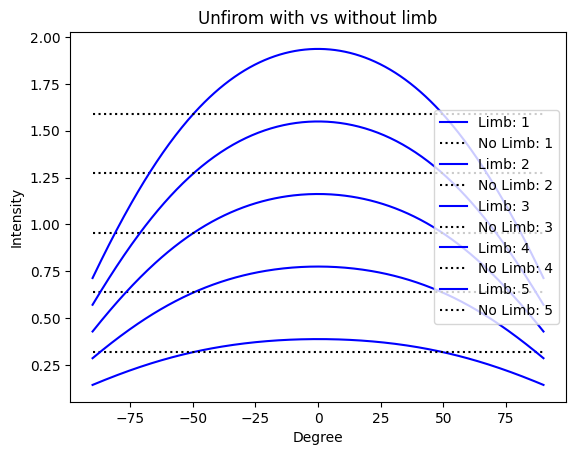

In [18]:
theta = np.linspace(-90,90,360)
for i in range(1,6):
    rv_star.map.amp = i
    no_limb.map.amp = i
    limb = rv_star.map.intensity(lat=0, lon=theta,rv=False).eval()
    limb_less = no_limb.map.intensity(lat=0, lon=theta,rv=False).eval()
    plt.plot(theta,limb,color="blue",label=f"Limb: {i}")
    plt.plot(theta,limb_less,color="black",linestyle=":",label=f"No Limb: {i}")
    print(np.max(limb) / np.max(limb_less))
    print(np.max(limb))
    print(np.max(limb_less))

ratio = np.max(limb) / np.max(limb_less)
reverse_ratio = np.max(limb_less) / np.max(limb)

plt.title("Unfirom with vs without limb")
plt.xlabel("Degree")
plt.ylabel("Intensity")
plt.legend(loc="center right")
plt.show()

In [19]:
mu = np.cos(theta * np.pi/180)

limb_law = 1 - udeg[0]*(1-mu) - udeg[1] * (1-mu)**2

1.2168113079002534
1.2168113079002534
1.2168113079002534
1.2168113079002534
1.2168113079002534


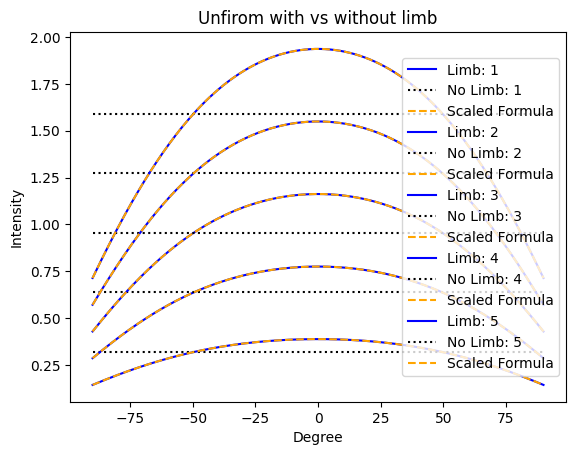

In [20]:
for i in range(1,6):
    rv_star.map.amp = i
    no_limb.map.amp = i
    limb = rv_star.map.intensity(lat=0, lon=theta,rv=False).eval()
    limb_less = no_limb.map.intensity(lat=0, lon=theta,rv=False).eval()

    ratio_to_law = limb[0] / limb_law[0]

    plt.plot(theta,limb,color="blue",label=f"Limb: {i}")
    plt.plot(theta,limb_less,color="black",linestyle=":",label=f"No Limb: {i}")
    plt.plot(theta,limb_law * ratio_to_law,color="orange",linestyle="--",label=f"Scaled Formula")

    print(np.max(limb) / np.max(limb_less))
    # print(np.max(limb))
    # print(np.max(limb_less))

# plt.plot(theta,limb_law,color="orange",linestyle="--",label=f"Limb from Formula")

ratio = np.max(limb) / np.max(limb_less)
reverse_ratio = np.max(limb_less) / np.max(limb)

plt.title("Unfirom with vs without limb")
plt.xlabel("Degree")
plt.ylabel("Intensity")
plt.legend(loc="center right")
plt.show()

1.0
1.0
1.0000000000000002
1.0
0.9999999999999999


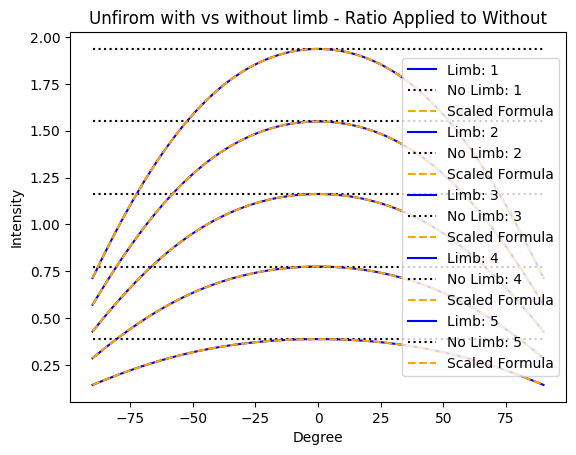

In [21]:
# theta = np.linspace(-90,90,1000)
for i in range(1,6):
    rv_star.map.amp = i
    no_limb.map.amp = i * ratio
    limb = rv_star.map.intensity(lat=0, lon=theta,rv=False).eval()
    limb_less = no_limb.map.intensity(lat=0, lon=theta,rv=False).eval()

    ratio_to_law = limb[0] / limb_law[0]

    plt.plot(theta,limb,color="blue",label=f"Limb: {i}")
    plt.plot(theta,limb_less,color="black",linestyle=":",label=f"No Limb: {i}")
    plt.plot(theta,limb_law * ratio_to_law,color="orange",linestyle="--",label=f"Scaled Formula")
    print(np.max(limb) / np.max(limb_less))
    

ratio = np.max(limb) / np.max(limb_less)

plt.title("Unfirom with vs without limb - Ratio Applied to Without")
plt.xlabel("Degree")
plt.ylabel("Intensity")
plt.legend(loc="center right")
plt.show()

1.0
1.0
1.0
1.0
1.0000000000000002


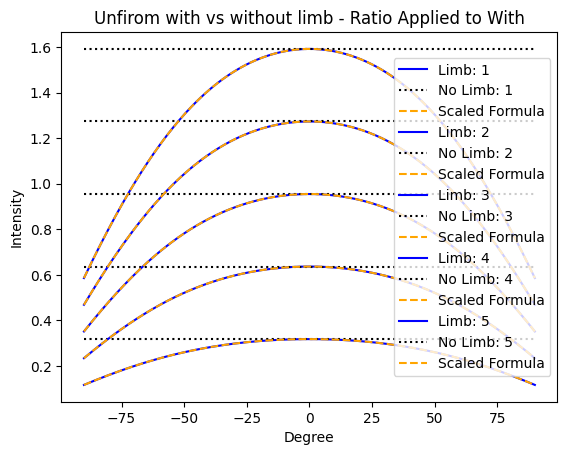

In [22]:
# theta = np.linspace(-90,90,720)
for i in range(1,6):
    rv_star.map.amp = i * reverse_ratio
    no_limb.map.amp = i
    limb = rv_star.map.intensity(lat=0, lon=theta,rv=False).eval()
    limb_less = no_limb.map.intensity(lat=0, lon=theta,rv=False).eval()

    ratio_to_law = limb[0] / limb_law[0]


    plt.plot(theta,limb,color="blue",label=f"Limb: {i}")
    plt.plot(theta,limb_less,color="black",linestyle=":",label=f"No Limb: {i}")
    plt.plot(theta,limb_law * ratio_to_law,color="orange",linestyle="--",label=f"Scaled Formula")
    print(np.max(limb) / np.max(limb_less))

ratio = np.max(limb) / np.max(limb_less)

plt.title("Unfirom with vs without limb - Ratio Applied to With")
plt.xlabel("Degree")
plt.ylabel("Intensity")
plt.legend(loc="center right")
plt.show()

##### Chaning it to 20 degrees!

1.183853749023831
0.3768323521100297
0.3183098861837908
1.183853749023831
0.7536647042200594
0.6366197723675816
1.183853749023831
1.1304970563300891
0.9549296585513725
1.183853749023831
1.5073294084401188
1.2732395447351632
1.183853749023831
1.8841617605501484
1.591549430918954


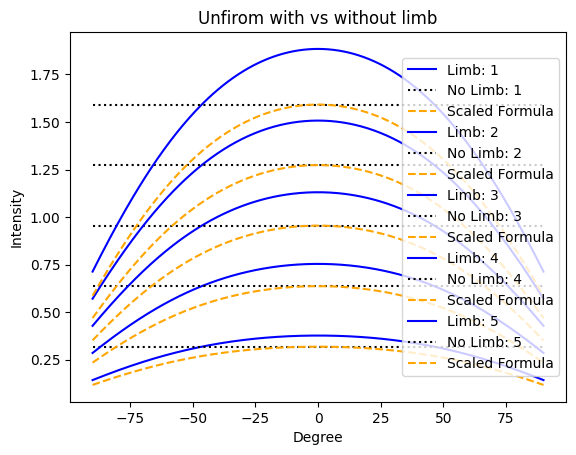

In [23]:
# theta = np.linspace(-90,90,720)

for i in range(1,6):
    rv_star.map.amp = i
    no_limb.map.amp = i
    limb = rv_star.map.intensity(lat=20, lon=theta,rv=False).eval()
    limb_less = no_limb.map.intensity(lat=20, lon=theta,rv=False).eval()
    
    
    plt.plot(theta,limb,color="blue",label=f"Limb: {i}")
    plt.plot(theta,limb_less,color="black",linestyle=":",label=f"No Limb: {i}")

    plt.plot(theta,limb_law * limb_less,color="orange",linestyle="--",label=f"Scaled Formula")
    
    print(np.max(limb) / np.max(limb_less))
    print(np.max(limb))
    print(np.max(limb_less))

# ratio = np.max(limb) / np.max(limb_less)
# reverse_ratio = np.max(limb_less) / np.max(limb)

plt.title("Unfirom with vs without limb")
plt.xlabel("Degree")
plt.ylabel("Intensity")
plt.legend(loc="center right")
plt.show()

In [24]:
print(np.max(rv_star.map.intensity(lat=0, lon=theta,rv=False).eval()))
print(np.max(rv_star.map.intensity(lat=20, lon=theta,rv=False).eval()))

1.9366153446243963
1.8841617605501484


In [25]:
theta_new = np.linspace(-70,110,360)

mu_new = np.cos((theta_new - 20) * np.pi/180)

limb_law_new = 1 - udeg[0]*(1-mu_new) - udeg[1] * (1-mu_new)**2

In [26]:
print(np.max(limb_law),np.argmax(limb_law))
print(np.max(limb_law_new),np.argmax(limb_law_new))

0.9999958130208929 179
0.9999958130208929 179


In [27]:
theta_new[np.argmax(limb_law_new)]

19.749303621169915

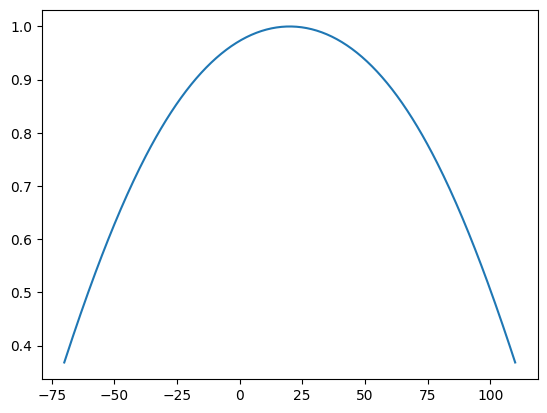

In [28]:
plt.plot(theta_new,limb_law_new)

In [29]:
rv_star.map.inc = 70

1.0
1.0
1.0
1.0
1.0000000000000002


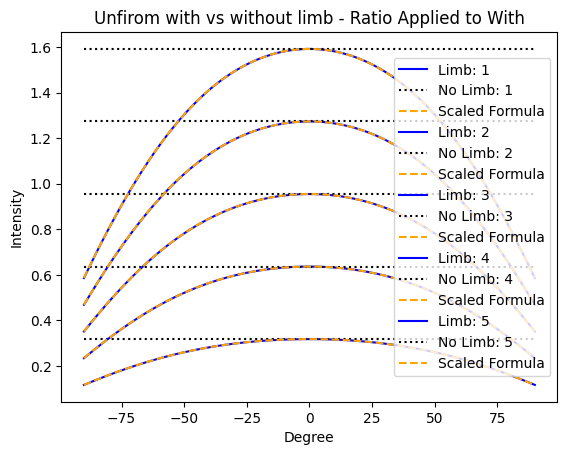

In [30]:
for i in range(1,6):
    rv_star.map.amp = i * reverse_ratio
    no_limb.map.amp = i
    limb = rv_star.map.intensity(lat=0, lon=theta,rv=False).eval()
    limb_less = no_limb.map.intensity(lat=0, lon=theta,rv=False).eval()

    ratio_to_law = limb[0] / limb_law[0]


    plt.plot(theta,limb,color="blue",label=f"Limb: {i}")
    plt.plot(theta,limb_less,color="black",linestyle=":",label=f"No Limb: {i}")
    plt.plot(theta,limb_law * limb_less,color="orange",linestyle="--",label=f"Scaled Formula")
    print(np.max(limb) / np.max(limb_less))

ratio = np.max(limb) / np.max(limb_less)

plt.title("Unfirom with vs without limb - Ratio Applied to With")
plt.xlabel("Degree")
plt.ylabel("Intensity")
plt.legend(loc="center right")
plt.show()

In [31]:
theta_t = np.linspace(-180,180,40)
print(theta_t)
rv_star.map.intensity(lat=0, lon=theta_t,rv=False).eval()

[-180.         -170.76923077 -161.53846154 -152.30769231 -143.07692308
 -133.84615385 -124.61538462 -115.38461538 -106.15384615  -96.92307692
  -87.69230769  -78.46153846  -69.23076923  -60.          -50.76923077
  -41.53846154  -32.30769231  -23.07692308  -13.84615385   -4.61538462
    4.61538462   13.84615385   23.07692308   32.30769231   41.53846154
   50.76923077   60.           69.23076923   78.46153846   87.69230769
   96.92307692  106.15384615  115.38461538  124.61538462  133.84615385
  143.07692308  152.30769231  161.53846154  170.76923077  180.        ]


array([-1.03769457, -1.01271324, -0.93902918, -0.82032647, -0.66243517,
       -0.47289664, -0.26041298, -0.03423117,  0.19648172,  0.42321657,
        0.63860335,  0.8367562 ,  1.01345749,  1.16617294,  1.29390706,
        1.39692429,  1.47637443,  1.5338699 ,  1.57106622,  1.58929545,
        1.58929545,  1.57106622,  1.5338699 ,  1.47637443,  1.39692429,
        1.29390706,  1.16617294,  1.01345749,  0.8367562 ,  0.63860335,
        0.42321657,  0.19648172, -0.03423117, -0.26041298, -0.47289664,
       -0.66243517, -0.82032647, -0.93902918, -1.01271324, -1.03769457])

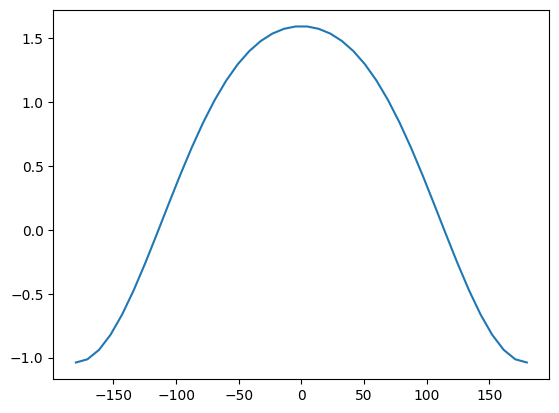

In [32]:
plt.plot(theta_t,rv_star.map.intensity(lat=0, lon=theta_t,rv=False).eval())

In [33]:
theta_t = np.linspace(-180,180,20)
print(theta_t)
no_limb.map.intensity(lat=theta_t, lon=0,rv=False).eval()

[-180.         -161.05263158 -142.10526316 -123.15789474 -104.21052632
  -85.26315789  -66.31578947  -47.36842105  -28.42105263   -9.47368421
    9.47368421   28.42105263   47.36842105   66.31578947   85.26315789
  104.21052632  123.15789474  142.10526316  161.05263158  180.        ]


array([1.59154943, 1.59154943, 1.59154943, 1.59154943, 1.59154943,
       1.59154943, 1.59154943, 1.59154943, 1.59154943, 1.59154943,
       1.59154943, 1.59154943, 1.59154943, 1.59154943, 1.59154943,
       1.59154943, 1.59154943, 1.59154943, 1.59154943, 1.59154943])

In [34]:
mu_t = np.cos(theta_t * np.pi/180)

limb_law_t = 1 - udeg[0]*(1-mu_t) - udeg[1] * (1-mu_t)**2
limb_law_t

array([-0.652     , -0.58676004, -0.40452898, -0.14160447,  0.15381986,
        0.43518554,  0.66874833,  0.83860716,  0.9444593 ,  0.99399829,
        0.99399829,  0.9444593 ,  0.83860716,  0.66874833,  0.43518554,
        0.15381986, -0.14160447, -0.40452898, -0.58676004, -0.652     ])

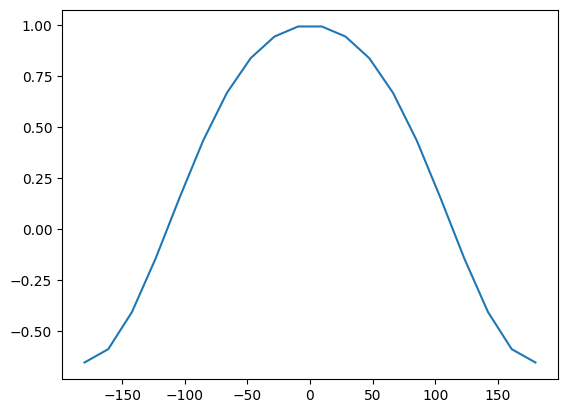

In [35]:
# plt.plot(theta_t,no_limb.map.intensity(lat=0, lon=theta_t,rv=False).eval())
plt.plot(theta_t,limb_law_t)

## Putting it alll together

In [36]:
#load in data/set up stars
realistic_star = utils.initstar(fit, lmax, udeg=udeg, include_rv=True)
base_star = utils.initstar(fit, lmax, include_rv=True)

inv_realistic_star = utils.initstar(fit, lmax, udeg=udeg, include_rv=True)
inv_base_star = utils.initstar(fit, lmax, include_rv=True)

uni_star_limb = utils.initstar(fit, lmax, udeg=udeg, include_rv=True)
uni_star = utils.initstar(fit, lmax, include_rv=True)

null_eigney = np.loadtxt(f"test_corrections/null_eigeny.txt")
null_neg_eigney = np.loadtxt(f"test_corrections/null_neg_eigeny.txt")

theta_0 = np.linspace(0, 360, 60)
theta_neg_90 = np.linspace(-90,90,720)

In [37]:
#test we have right map
map_null_2 = null_neg_eigney[2]
map_2 = null_eigney[2]

realistic_star.map[0,0] = map_2[0]
realistic_star.map[1:,:] = 0
yi = 1
for l in range(1, lmax + 1):
    for mn in range(-l, l + 1):
        realistic_star.map[l, mn] = map_2[yi]
        yi += 1

print(realistic_star.map.flux(theta=theta_0).eval())

[ 1.07878116e-16  1.38777878e-17 -9.71445147e-17 -1.38777878e-16
 -1.11022302e-16 -1.80411242e-16 -1.11022302e-16 -5.55111512e-17
  0.00000000e+00  8.32667268e-17  1.66533454e-16  2.22044605e-16
  3.60822483e-16  4.44089210e-16  4.16333634e-16  3.88578059e-16
  4.16333634e-16  4.44089210e-16  4.71844785e-16  4.44089210e-16
  3.88578059e-16  4.44089210e-16  3.05311332e-16  3.33066907e-16
  4.16333634e-16  4.44089210e-16  4.99600361e-16  7.21644966e-16
  7.14706072e-16  8.50014503e-16  9.90527105e-16  1.06858966e-15
  1.08246745e-15  1.23512311e-15  1.26287869e-15  1.38777878e-15
  1.33226763e-15  1.38777878e-15  1.47104551e-15  1.52655666e-15
  1.55431223e-15  1.63757896e-15  1.52655666e-15  1.69309011e-15
  1.69309011e-15  1.63757896e-15  1.69309011e-15  1.66533454e-15
  1.49880108e-15  1.60982339e-15  1.55431223e-15  1.44328993e-15
  1.16573418e-15  1.16573418e-15  8.88178420e-16  7.91033905e-16
  6.52256027e-16  3.12250226e-16  2.28983499e-16  1.04733930e-16]


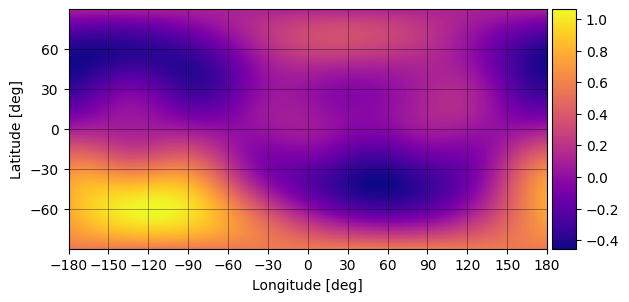

In [38]:
realistic_star.map.show(projection="rect",rv=False,colorbar=True)

In [39]:
#reset the star, create version without limb darkening, and create versions of unfirom stars
realistic_star.map[0,0] = map_null_2[0]
realistic_star.map[1:,:] = 0

base_star.map[0,0] = map_null_2[0]
base_star.map[1:,:] = 0

uni_comp = 1

uni_star.map[0,0] = uni_comp
uni_star.map[1:,:] = 0

uni_star_limb.map[0,0] = uni_comp
uni_star_limb.map[1:,:] = 0

In [40]:
# pull out ratio of max intensity in uni_star to one with limb darkening 
# (this is independent of harmonic as long they are the same across stars)

uni_I = uni_star.map.intensity(lat=0, lon=theta_neg_90,rv=False).eval()
uni_I_limb = uni_star_limb.map.intensity(lat=0, lon=theta_neg_90,rv=False).eval()

ratio_no_limb = np.max(uni_I) / np.max(uni_I_limb)

In [41]:
np.max(uni_I_limb)

0.3873242863429529

In [42]:
np.max(uni_I)

0.3183098861837908

In [43]:
#set up both stars with basic componets to determine needed changes

realistic_star.map[0,0] = map_null_2[0] + uni_comp
realistic_star.map[1:,:] = 0
yi = 1
for l in range(1, lmax + 1):
    for mn in range(-l, l + 1):
        realistic_star.map[l, mn] = map_null_2[yi]
        yi += 1

base_star.map[0,0] = map_null_2[0] + uni_comp
base_star.map[1:,:] = 0
yi = 1
for l in range(1, lmax + 1):
    for mn in range(-l, l + 1):
        base_star.map[l, mn] = map_null_2[yi]
        yi += 1



In [44]:
#test minimize gives the same value
assert realistic_star.map.minimize()[-1].eval() == base_star.map.minimize()[-1].eval(), "Minimize not same, issues with set up"

In [45]:
#create inverse versions

inv_realistic_star.map[0,0] = map_2[0] + uni_comp
inv_realistic_star.map[1:,:] = 0
yi = 1
for l in range(1, lmax + 1):
    for mn in range(-l, l + 1):
        inv_realistic_star.map[l, mn] = map_2[yi]
        yi += 1

inv_base_star.map[0,0] = map_2[0] + uni_comp
inv_base_star.map[1:,:] = 0
yi = 1
for l in range(1, lmax + 1):
    for mn in range(-l, l + 1):
        inv_base_star.map[l, mn] = map_2[yi]
        yi += 1

In [46]:
#test minimize gives the same value
assert inv_realistic_star.map.minimize()[-1].eval() == inv_base_star.map.minimize()[-1].eval(), "Minimize not same, issues with inverse set up"

#test minimize is different for inverse and not
assert inv_realistic_star.map.minimize()[-1].eval() != realistic_star.map.minimize()[-1].eval(), "Minimize not same, issues with realistic"
assert base_star.map.minimize()[-1].eval() != inv_base_star.map.minimize()[-1].eval(), "Minimize not same, issues with base"


#test minimize is same difference from 1
assert np.isclose(uni_I[0] - realistic_star.map.minimize()[-1].eval(),
                  inv_realistic_star.map.render(projection="rect",rv=False).eval().max() - uni_I[0],rtol=1e-3), "Problem with difference from uni comp (1)"
assert np.isclose(uni_I[0] - inv_realistic_star.map.minimize()[-1].eval(),
                  realistic_star.map.render(projection="rect",rv=False).eval().max() - uni_I[0],rtol=1e-3), "Problem with difference from uni comp (2)"

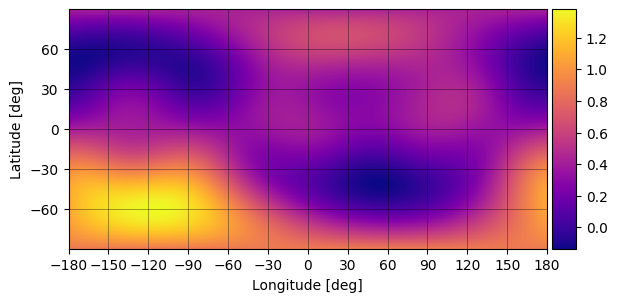

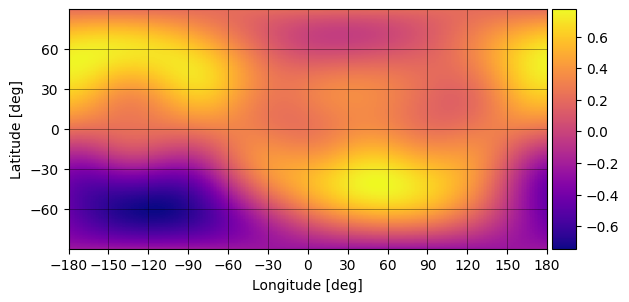

In [47]:
inv_realistic_star.map.show(projection="rect",rv=False,colorbar=True)
realistic_star.map.show(projection="rect",rv=False,colorbar=True)

In [48]:
#time to alter the star to match light curve with no limb

realistic_star.map[0,0] = map_null_2[0] + uni_comp * ratio_no_limb
realistic_star.map[1:,:] = 0
yi = 1
for l in range(1, lmax + 1):
    for mn in range(-l, l + 1):
        realistic_star.map[l, mn] = map_null_2[yi]
        yi += 1

inv_realistic_star.map[0,0] = map_2[0] + uni_comp * ratio_no_limb
inv_realistic_star.map[1:,:] = 0
yi = 1
for l in range(1, lmax + 1):
    for mn in range(-l, l + 1):
        inv_realistic_star.map[l, mn] = map_2[yi]
        yi += 1

In [49]:
#testing that uniform componet was changed correctly
assert np.isclose(uni_I[0] * ratio_no_limb - realistic_star.map.minimize()[-1].eval(),
                  inv_realistic_star.map.render(projection="rect",rv=False).eval().max() - uni_I[0] * ratio_no_limb,rtol=1e-3), "Problem with difference from uni comp (1)"
assert np.isclose(uni_I[0] * ratio_no_limb - inv_realistic_star.map.minimize()[-1].eval(),
                  realistic_star.map.render(projection="rect",rv=False).eval().max() - uni_I[0] * ratio_no_limb,rtol=1e-3), "Problem with difference from uni comp (2)"

In [50]:
#changin star to match realistic parameters
# max = 1.35x uniform
# min = 0.42x uniform

uni_comp = 5.8

#uniform to compare with 
#standard one without limb.  This represents max of uniform added to map with limb applied

uni_star_limb.map[0,0] = uni_comp * ratio_no_limb
uni_star_limb.map[1:,:] = 0
uni_value = np.max(uni_star_limb.map.intensity(lat=0, lon=theta_neg_90,rv=False).eval())

#setting up star without scaling for limb
#doing this to find ranges of lowest and max value since minimize doesn't use limb
#will apply ratio_no_limb after scaling completed
realistic_star.map[0,0] = map_null_2[0] + uni_comp
realistic_star.map[1:,:] = 0
yi = 1
for l in range(1, lmax + 1):
    for mn in range(-l, l + 1):
        realistic_star.map[l, mn] = map_null_2[yi]
        yi += 1

inv_realistic_star.map[0,0] = map_2[0] + uni_comp
inv_realistic_star.map[1:,:] = 0
yi = 1
for l in range(1, lmax + 1):
    for mn in range(-l, l + 1):
        inv_realistic_star.map[l, mn] = map_2[yi]
        yi += 1


amount_below_uni = uni_value - realistic_star.map.minimize()[-1].eval()
amount_above_uni = uni_value - inv_realistic_star.map.minimize()[-1].eval()
print("Amount uni/below/above:",round(uni_value,2),round(amount_below_uni,2),round(amount_above_uni,2))

ratio_below = (uni_value - amount_below_uni) / uni_value
ratio_above = (amount_above_uni + uni_value) / uni_value
print("Ratio below/above:",round(ratio_below,2),round(ratio_above,2))
print("Value uni/below/above:",round(uni_value,2),round(ratio_below*uni_value,2),round(ratio_above*uni_value,2))

Amount uni/below/above: 1.85 1.06 0.45
Ratio below/above: 0.43 1.25
Value uni/below/above: 1.85 0.78 2.3


In [51]:
#recreating map with uniform component scaled physically
realistic_star.map[0,0] = map_null_2[0] + uni_comp #* ratio_no_limb
realistic_star.map[1:,:] = 0
yi = 1
for l in range(1, lmax + 1):
    for mn in range(-l, l + 1):
        realistic_star.map[l, mn] = map_null_2[yi]
        yi += 1


# realistic_star.map[:,:] *= ratio_no_limb
realistic_star.map.amp = ratio_no_limb

In [74]:
realistic_star.map.show(projection="rect",rv=False,colorbar=True,file="test_grid.png")

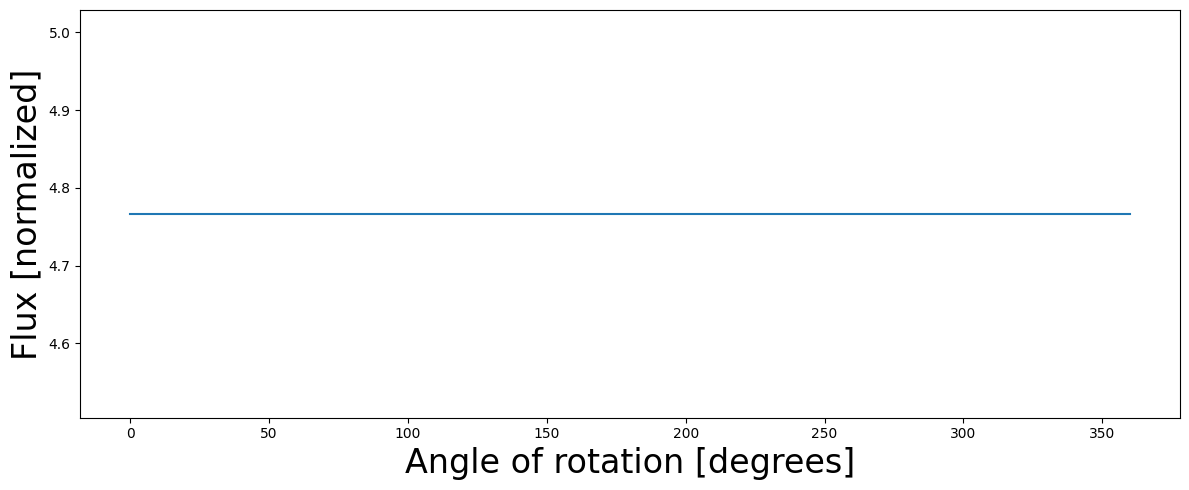

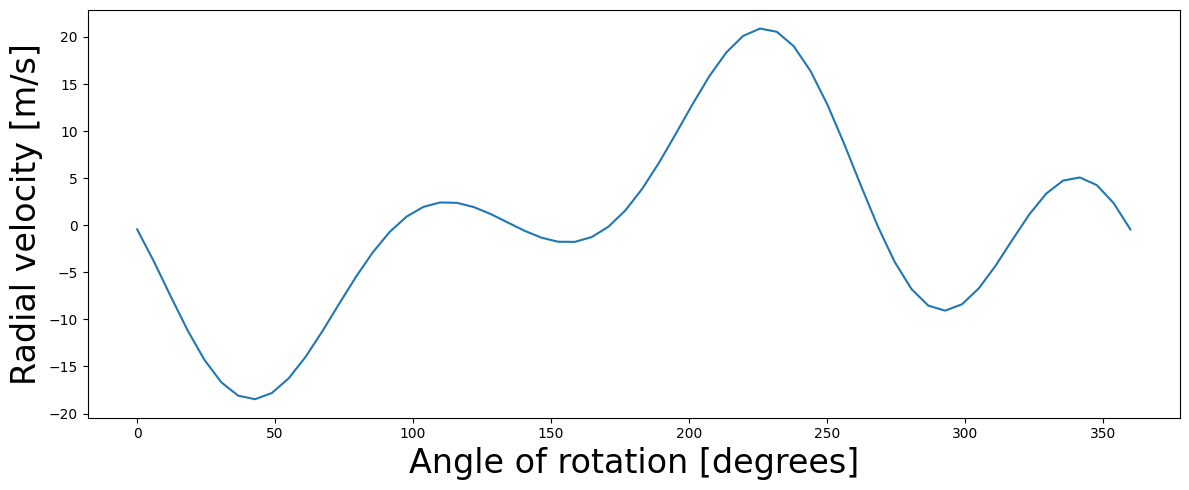

In [53]:
flux1 = realistic_star.map.flux(theta=theta_0).eval()

# Plot the flux
plt.figure(figsize=(12, 5))
plt.plot(theta_0, flux1)
plt.xlabel("Angle of rotation [degrees]", fontsize=24)
plt.ylabel("Flux [normalized]", fontsize=24)
# plt.gca().yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
# plt.yticks([flux1[0]])
plt.tight_layout()
plt.show()

# Plot the radial velocity
plt.figure(figsize=(12, 5))
plt.plot(theta_0, realistic_star.map.rv(theta=theta_0).eval())
plt.xlabel("Angle of rotation [degrees]", fontsize=24)
plt.ylabel("Radial velocity [m/s]", fontsize=24)
plt.tight_layout()
plt.show()

In [54]:
# print(theta_0)
plt.close()

In [55]:
# realistic_star.map.rv(theta_0).eval()

In [56]:
import create_rv

#fix this by running the cell after crash??? Yes, no clue why!

create_rv.map_curve_ani(realistic_star,theta_0,cbar_pos="bottom",fname="test_map_3.mp4")

In [57]:
realistic_star.map.show(rv=False, colorbar=True,theta=theta_0)

In [58]:
realistic_star.map.show(rv=True, colorbar=True,theta=theta_0)

In [59]:
#Now to scale the map to real units

# flux_conv = 5.1247e7 / realistic_star.map.flux(theta=theta_0).eval()[0] #W/m^2*1e7

# realistic_star.map.amp = flux_conv

# realistic_star.map.amp = 1

In [60]:
# print(realistic_star.map.minimize()[-1].eval())

In [61]:
# realistic_star.map.show(projection="rect",rv=False,colorbar=True)

In [62]:
# flux1 = realistic_star.map.flux(theta=theta).eval()

# # Plot the flux
# plt.figure(figsize=(12, 5))
# plt.plot(theta, flux1)
# plt.xlabel("Angle of rotation [degrees]", fontsize=24)
# plt.ylabel("Flux [normalized]", fontsize=24)
# # plt.gca().yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
# # plt.yticks([flux1[0]])
# plt.tight_layout()
# plt.show()

# # Plot the radial velocity
# plt.figure(figsize=(12, 5))
# plt.plot(theta, realistic_star.map.rv(theta=theta).eval())
# plt.xlabel("Angle of rotation [degrees]", fontsize=24)
# plt.ylabel("Radial velocity [m/s]", fontsize=24)
# plt.tight_layout()
# plt.show()

In [63]:
# create_rv.map_curve_ani(realistic_star,theta_0,fname="test_map_2.mp4")

In [64]:
# realistic_star.map.show(rv=False, colorbar=True,theta=theta_0)

In [65]:
# realistic_star.map.show(rv=True, colorbar=True,theta=theta_0)

In [66]:
# realistic_star.map.amp = 1

In [67]:
fig, axes = plt.subplots(nrows=2, ncols=1, squeeze=False,
                            sharex=False, sharey=False, figsize=(12, 6))

ax = axes[1,0]

# theta = np.linspace(0, 360, 60)

new_theta = np.linspace(-180, 180, 61)[:-1]

# lon_theta = np.linspace(-90, 90, 61)[:-1]

# limb = realistic_star.map.intensity(lat=0, lon=0, theta=new_theta,rv=False).eval()

limb = realistic_star.map.render(rv=False,theta=new_theta).eval()[:,150,150]

limb_image = ax.plot(new_theta, limb,label="sample")
ax.axvline(x=0, color='gray', linestyle='--', linewidth=1)
ax.axhline(y=uni_value*1.35, color='red', linestyle='--', linewidth=1,label="sample")
L_limb = ax.legend(loc="upper left",handlelength=0)
# ax.set_xlim(-30,30)

ax.set_xlabel("Angle of rotation [degrees]", fontsize=16)
ax.set_ylabel("Relative Intensity", fontsize=16)

ax.set_title("Intensity versus Lon Degree",fontsize=20)

plt.tight_layout()

# print(L_limb.get_texts()[1])

realistic_star.map.show(theta=theta_0,rv=False, ax=axes[0,0],show_image=True, colorbar="bottom", 
                        extra_lines = [(limb,limb_image)],
                        legend_list = [L_limb],
                        uni_int = uni_value,
                        file="testing_intensity.mp4")



In [68]:
theta_0

array([  0.        ,   6.10169492,  12.20338983,  18.30508475,
        24.40677966,  30.50847458,  36.61016949,  42.71186441,
        48.81355932,  54.91525424,  61.01694915,  67.11864407,
        73.22033898,  79.3220339 ,  85.42372881,  91.52542373,
        97.62711864, 103.72881356, 109.83050847, 115.93220339,
       122.03389831, 128.13559322, 134.23728814, 140.33898305,
       146.44067797, 152.54237288, 158.6440678 , 164.74576271,
       170.84745763, 176.94915254, 183.05084746, 189.15254237,
       195.25423729, 201.3559322 , 207.45762712, 213.55932203,
       219.66101695, 225.76271186, 231.86440678, 237.96610169,
       244.06779661, 250.16949153, 256.27118644, 262.37288136,
       268.47457627, 274.57627119, 280.6779661 , 286.77966102,
       292.88135593, 298.98305085, 305.08474576, 311.18644068,
       317.28813559, 323.38983051, 329.49152542, 335.59322034,
       341.69491525, 347.79661017, 353.89830508, 360.        ])

In [69]:
fig, axes = plt.subplots(nrows=2, ncols=1, squeeze=False,
                            sharex=False, sharey=False, figsize=(12, 6))

ax = axes[1,0]

# theta = np.linspace(0, 360, 60)

new_theta = np.linspace(-180, 180, 61)[:-1]

# lon_theta = np.linspace(-90, 90, 61)[:-1]

# limb = realistic_star.map.intensity(lat=0, lon=0, theta=new_theta,rv=False).eval()

limb = realistic_star.map.render(rv=False,theta=new_theta).eval()[:,150,150]

limb_image = ax.plot(new_theta, limb,label="sample")
ax.axvline(x=0, color='gray', linestyle='--', linewidth=1)
ax.axhline(y=uni_value*1.35, color='red', linestyle='--', linewidth=1,label="sample")
L_limb = ax.legend(loc="upper left",handlelength=0)
# ax.set_xlim(-30,30)

ax.set_xlabel("Angle of rotation [degrees]", fontsize=16)
ax.set_ylabel("Relative Intensity", fontsize=16)

ax.set_title("Intensity versus Lon Degree",fontsize=20)

plt.tight_layout()

# print(L_limb.get_texts()[1])

realistic_star.map.show(theta=theta_0,rv=False, ax=axes[0,0],show_image=True, colorbar="bottom", 
                        extra_lines = [(limb,limb_image)],
                        legend_list = [L_limb],
                        uni_int = uni_value,
                        file="extra_testing_intensity.mp4")


In [70]:
uni_star_test = utils.initstar(fit, lmax, udeg=udeg, include_rv=True)
print(uni_star_test.map.inc.eval())

70.0


In [71]:
max_val = float("-inf")

for i in range(0,300,15):

    # vals = uni_star_test.map.render(rv=False,theta=new_theta).eval()[0,i,150]

    vals = uni_star_test.map.intensity(lat=i, lon=theta_neg_90,rv=False).eval()

    # grid = uni_star_test.map.get_latlon_grid()


    print(np.max(vals))
    # print(grid[0].eval()[i][0])
    print(i)
    if np.max(vals) > max_val:
        max_val = np.max(vals)
        max_i = i


print(max_val,max_i)


0.3873242863429529
0
0.38146420692177946
15
0.3632760770599538
30
0.3312475396101926
45
0.28380219200335643
60
0.22041426180502688
75
0.14265168356465174
90
0.14265168356465174
105
0.1426516835646517
120
0.1426516835646517
135
0.1426516835646517
150
0.1426516835646517
165
0.1426516835646517
180
0.1426516835646517
195
0.1426516835646517
210
0.14265168356465172
225
0.14265168356465172
240
0.14265168356465172
255
0.14265168356465172
270
0.22041426180502674
285
0.3873242863429529 0


In [72]:
grid[0].eval()[max_i][150]

NameError: name 'grid' is not defined

In [ ]:
print(grid[0].eval()[285][150])

81.00570019000551


In [ ]:
grid = uni_star_test.map.get_latlon_grid(projection="rect")

grid[0].eval()[15][190]

-80.99969998999971

In [ ]:
grid[1].eval()

array([[-180.       , -178.79996  , -177.59992  , ...,  176.4118804,
         177.6119204,  178.8119604],
       [-180.       , -178.79996  , -177.59992  , ...,  176.4118804,
         177.6119204,  178.8119604],
       [-180.       , -178.79996  , -177.59992  , ...,  176.4118804,
         177.6119204,  178.8119604],
       ...,
       [-180.       , -178.79996  , -177.59992  , ...,  176.4118804,
         177.6119204,  178.8119604],
       [-180.       , -178.79996  , -177.59992  , ...,  176.4118804,
         177.6119204,  178.8119604],
       [-180.       , -178.79996  , -177.59992  , ...,  176.4118804,
         177.6119204,  178.8119604]])

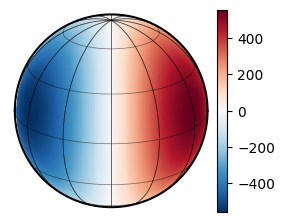

In [ ]:
uni_star_test.map.show(grid=True,colorbar=True)

In [ ]:
val2 = uni_star_test.map.render(rv=False,theta=new_theta).eval()[0,150,150]

vals1 = uni_star_test.map.intensity(lat=0, lon=theta_neg_90,rv=False).eval()

In [ ]:
val2

0.3873246904570142

In [ ]:
np.max(vals1)

0.3873242863429529

[1.77837403]


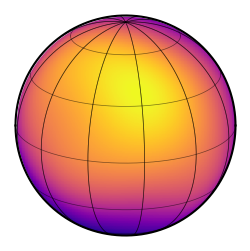

In [ ]:
realistic_star.map.inc = 70
realistic_star.map.obl = 0
print(realistic_star.map.intensity(lat=0, lon=0,rv=False).eval())
realistic_star.map.show(rv=False,theta=100)

In [ ]:
theta3 = np.linspace(-180,180,360)


mu3 = np.cos((theta3) * np.pi/180)

limb_law3 = 1 - udeg[0]*(1-mu3) - udeg[1] * (1-mu3)**2

In [ ]:
no_limb3 = realistic_star.map.intensity(lat=0, lon=theta3,rv=False,limbdarken=False).eval()
# no_limb3

i3 = realistic_star.map.intensity(lat=0, lon=theta3,rv=False).eval()

In [ ]:
# limb_law3 / i3

In [ ]:
factor3 = np.max(no_limb3*limb_law3 / i3)
factor3

0.8218166666666775

In [ ]:
ratio_no_limb

0.8218175245069608

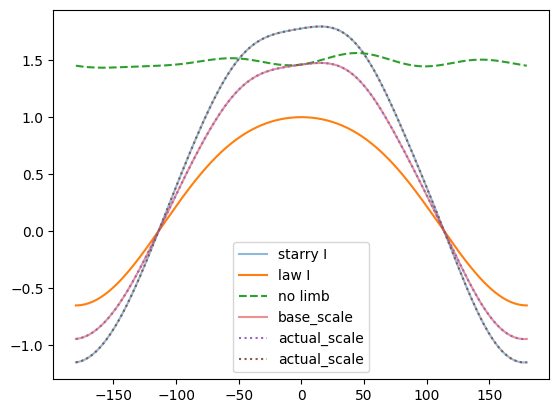

In [ ]:
plt.plot(theta3,i3,label="starry I",alpha=.5)
plt.plot(theta3,limb_law3,label="law I")
plt.plot(theta3,no_limb3,ls="--",label="no limb")
plt.plot(theta3,no_limb3*limb_law3,label="base_scale",alpha=.5)
plt.plot(theta3,i3 * factor3,label="actual_scale",ls=":")
plt.plot(theta3,no_limb3*limb_law3 / factor3,label="actual_scale",ls=":")
plt.legend()

In [ ]:
# realistic_star.map.show(theta=theta,rv=False)

In [ ]:
# realistic_star.map.intensity(lat=0, lon=np.linspace(-90, 90, 61)[:-1],rv=False).eval()

In [ ]:
# np.min(realistic_star.map.render(theta=np.linspace(-180, 180, 61)[:-1],rv=False).eval()[~np.isnan(realistic_star.map.render(theta=np.linspace(-90, 90, 61)[:-1],rv=False).eval())])

In [ ]:
# realistic_star.map.show(theta=np.linspace(-180, 180, 61)[:-1],rv=False)

In [ ]:
# np.linspace(0, 360, 61)[:-1]


In [ ]:
# realistic_star.map.intensity(lat=0, lon=0, theta=np.linspace(-180, 180, 61)[:-1],rv=False).eval()

In [ ]:
# test_grid = realistic_star.map.render(rv=False,theta=np.linspace(-180, 180, 61)[:-1]).eval()

In [ ]:
# test_grid[1][test_grid.shape[1]//2]

In [ ]:
# realistic_star.map.get_latlon_grid(res=300, projection='rect')[0].eval()[0].shape

In [ ]:
# limb = realistic_star.map.render(rv=False,theta=np.linspace(-180, 180, 61)[:-1]).eval()[:,150,1:]
# limb.shape

[-1.      0.4374  0.1943]


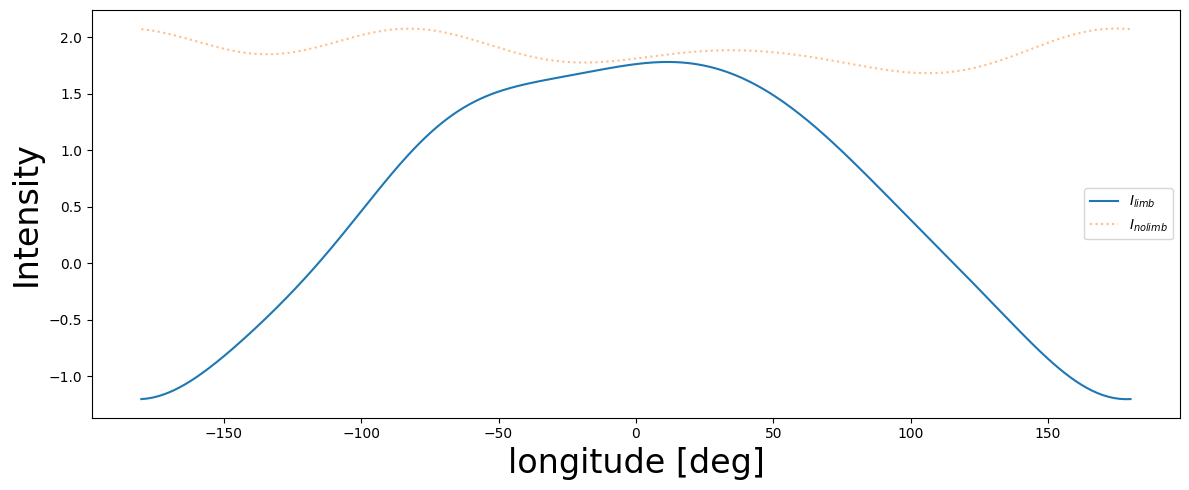

In [ ]:
theta_i = np.linspace(-180,180,360)
mu = np.cos((theta_i) * np.pi/180)

# realistic_star.map[:,:] *= ratio_no_limb
realistic_star.map.amp = ratio_no_limb
star_intensity = realistic_star.map.intensity(lat=20, lon=theta_i,rv=False).eval()
realistic_star.map.amp = 1
no_limb_intenisty = realistic_star.map.intensity(lat=20, lon=theta_i,rv=False,limbdarken=False).eval()
udeg = realistic_star.map.u.eval()
print(udeg)
limb_law = 1 - udeg[0]*(1-mu) - udeg[1] * (1-mu)**2

plt.figure(figsize=(12, 5))
plt.plot(theta_i,star_intensity,label="$I_{limb}$",alpha=1)
plt.plot(theta_i, no_limb_intenisty, ls=":",alpha=.5,label="$I_{no limb}$")
# plt.plot(theta_i, no_limb_intenisty*limb_law / ratio_no_limb, ls=":",alpha=.5,label="test")
plt.xlabel("longitude [deg]", fontsize=24)
plt.ylabel("Intensity", fontsize=24)
plt.tight_layout()
plt.legend()

[-1.      0.4374  0.1943]


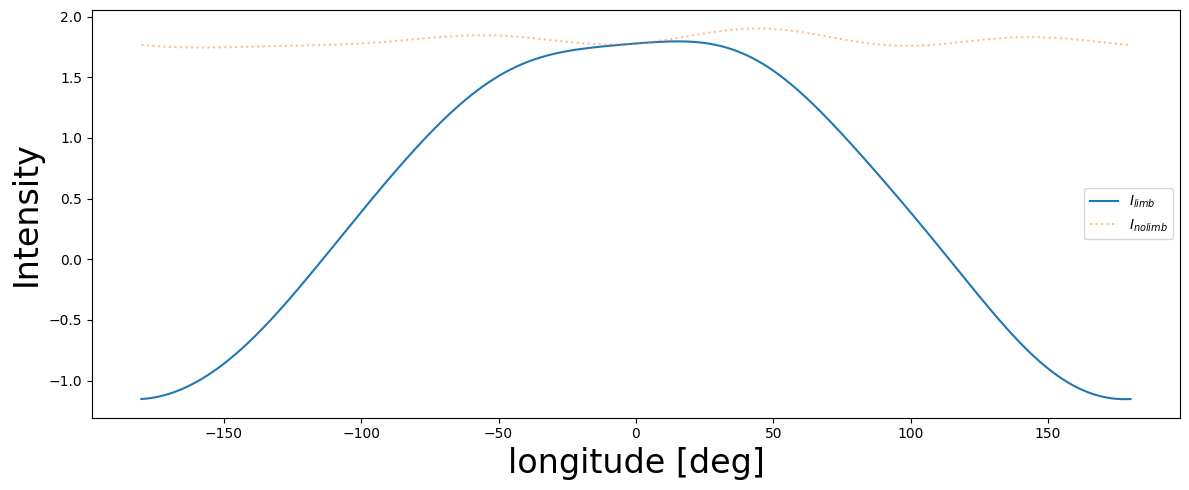

In [ ]:
theta_i = np.linspace(-180,180,360)
mu = np.cos((theta_i) * np.pi/180)

# realistic_star.map[:,:] *= ratio_no_limb
realistic_star.map.amp = ratio_no_limb
star_intensity = realistic_star.map.intensity(lat=0, lon=theta_i,rv=False).eval()
realistic_star.map.amp = 1
no_limb_intenisty = realistic_star.map.intensity(lat=0, lon=theta_i,rv=False,limbdarken=False).eval()
no_limb_intenisty2 = realistic_star.map.intensity(lat=0, lon=theta_i,rv=False,limbdarken=False).eval()
udeg = realistic_star.map.u.eval()
print(udeg)
limb_law = 1 - udeg[0]*(1-mu) - udeg[1] * (1-mu)**2

plt.figure(figsize=(12, 5))
plt.plot(theta_i,star_intensity,label="$I_{limb}$",alpha=1)
plt.plot(theta_i, no_limb_intenisty, ls=":",alpha=.5,label="$I_{no limb}$")
# plt.plot(theta_i, no_limb_intenisty*limb_law / ratio_no_limb, ls=":",alpha=.5,label="test")
plt.xlabel("longitude [deg]", fontsize=24)
plt.ylabel("Intensity", fontsize=24)
plt.tight_layout()
plt.legend()

In [ ]:
plt.plot(no_limb_intenisty)
plt.plot(no_limb_intenisty2)

In [ ]:
# %pip freeze

: 

# GLEAM Poster

In [1]:
#general imports
import os
import sys
import mc3
import pickle
import shutil
import subprocess
import progressbar
import numpy as np
import matplotlib.pyplot as plt
import starry2 as starry

import faulthandler
faulthandler.enable()

# Directory structure
__file__ = os.path.abspath('') # __file__ is not defined in jupyter
maindir    = os.path.dirname(os.path.realpath(__file__))
libdir     = os.path.join(maindir, 'lib')


# Directory structure
maindir    = os.path.dirname(os.path.realpath(__file__))
libdir     = os.path.join(maindir, 'lib')

# Lib imports
sys.path.append(libdir)
print(sys.path)
from jup_lib import utils
from jup_lib import eigen

# py imports
import create_eigens
import create_emaps
import check_eigens
import create_rv
import real_null_maps

#Setting up colored print statements
class style():
    BLACK = '\033[30m'
    RED = '\033[31m'
    GREEN = '\033[32m'
    YELLOW = '\033[33m'
    BLUE = '\033[34m'
    MAGENTA = '\033[35m'
    CYAN = '\033[36m'
    WHITE = '\033[37m'
    UNDERLINE = '\033[4m'
    RESET = '\033[0m'


starry.config.quiet = True

# Starry seems to have a lot of recursion
sys.setrecursionlimit(10000)

#Fix GUI backend that is changed by mc3
import matplotlib
matplotlib.use('TkAgg')
import matplotlib.pyplot as plt

%matplotlib inline

['/Users/a.j.devaux/.pyenv/versions/3.10.17/lib/python310.zip', '/Users/a.j.devaux/.pyenv/versions/3.10.17/lib/python3.10', '/Users/a.j.devaux/.pyenv/versions/3.10.17/lib/python3.10/lib-dynload', '', '/Users/a.j.devaux/Downloads/Research/stellar_null_space/null_rv/.venv/lib/python3.10/site-packages', '/Users/a.j.devaux/Downloads/Research/stellar_null_space/null_rv/.venv/lib/python3.10/site-packages/mc3/lib/', '/Users/a.j.devaux/Downloads/Research/stellar_null_space/null_rv/.venv/lib/python3.10/site-packages/mc3/lib', '/Users/a.j.devaux/Downloads/Research/stellar_null_space/lib']
['/Users/a.j.devaux/.pyenv/versions/3.10.17/lib/python310.zip', '/Users/a.j.devaux/.pyenv/versions/3.10.17/lib/python3.10', '/Users/a.j.devaux/.pyenv/versions/3.10.17/lib/python3.10/lib-dynload', '', '/Users/a.j.devaux/Downloads/Research/stellar_null_space/null_rv/.venv/lib/python3.10/site-packages', '/Users/a.j.devaux/Downloads/Research/stellar_null_space/null_rv/.venv/lib/python3.10/site-packages/mc3/lib/', '

In [2]:
from jup_lib import fitclass  as fc

cfile = "eridani.cfg"

# print("\nCalling create_eigens")
# print("----------------------------------------------------------------------------")
# eigeny, evalues, evectors, ecurves, lcs, star, cfg, fit = \
#     create_eigens.create_eigens(cfile)

fit = fc.Fit()

print("\tReading the configuration file & data.")
fit.read_config(cfile)
cfg = fit.cfg
fit.read_data()

print("Setting current directory")
subdir = cfg.folder
outdir = os.path.join(cfg.outdir, subdir)
rv_path = os.path.join(outdir,"rv_outputs")

if not os.path.isdir(rv_path):
    os.mkdir(rv_path)

print(rv_path)

lmax = cfg.twod.lmax
nsamples = cfg.twod.nsamples
udeg = cfg.twod.udeg



# star = utils.initstar(fit, lmax, include_rv=False)
# limb_star = utils.initstar(fit, lmax, udeg=udeg, include_rv=False)
# rv_star = utils.initstar(fit, lmax, udeg=udeg, include_rv=True)
# rv_star2 = utils.initstar(fit, lmax, udeg=udeg, include_rv=True)
# rv_star3 = utils.initstar(fit, lmax, udeg=udeg, include_rv=True)
# rv_star4 = utils.initstar(fit, lmax, udeg=udeg, include_rv=True)
# rv_star5 = utils.initstar(fit, lmax, udeg=udeg, include_rv=True)


theta = np.linspace(0, 360, 60)

	Reading the configuration file & data.
Setting current directory
eridani-outputs/pos-pca-full-5-quad_limb-results-70i/rv_outputs


In [51]:
eigeny_21 = np.loadtxt("eridani-outputs/pos-pca-full-5-quad_limb-results-70i/realistic_outputs/null_map_21/null_map_eigeny.txt")
eigeny_neg_2 = np.loadtxt("eridani-outputs/pos-pca-full-5-quad_limb-results-70i/realistic_outputs/null_map_-1/null_map_eigeny.txt")


uni_comp, uni_value, ratio_below, ratio_above, corrected_amp = np.loadtxt("eridani-outputs/pos-pca-full-5-quad_limb-results-70i/realistic_outputs/null_map_21/null_map_data.txt")

In [52]:
# corrected_amp = 8.218175245069607726e-01

In [53]:
realistic_star = utils.initstar(fit, lmax, udeg=udeg, include_rv=True)

In [54]:
realistic_star.map[:,:] = eigeny_21

realistic_star.map.amp = corrected_amp

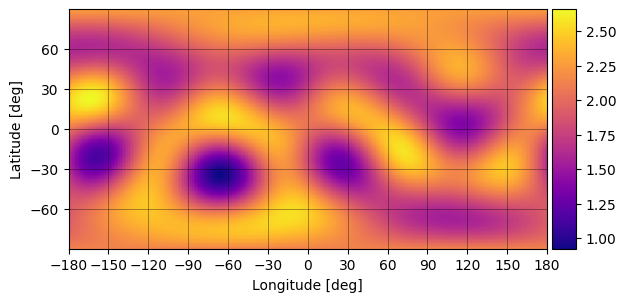

In [55]:
realistic_star.map.amp = 1

realistic_star.map.show(rv=False,projection="rect",colorbar=True)

realistic_star.map.amp = corrected_amp

In [56]:
theta = np.linspace(-180,180,720)

# create_rv.flux_rv_line(realistic_star,theta,flux_name=None,rv_name=None,flux_only=False,rv_only=False)

In [57]:
# map_rv = realistic_star.map.rv(theta=theta).eval()

# max_theta = np.argmax(map_rv)
# min_theta = np.argmax(map_rv)

# map_rv[np.isclose(map_rv,0)]

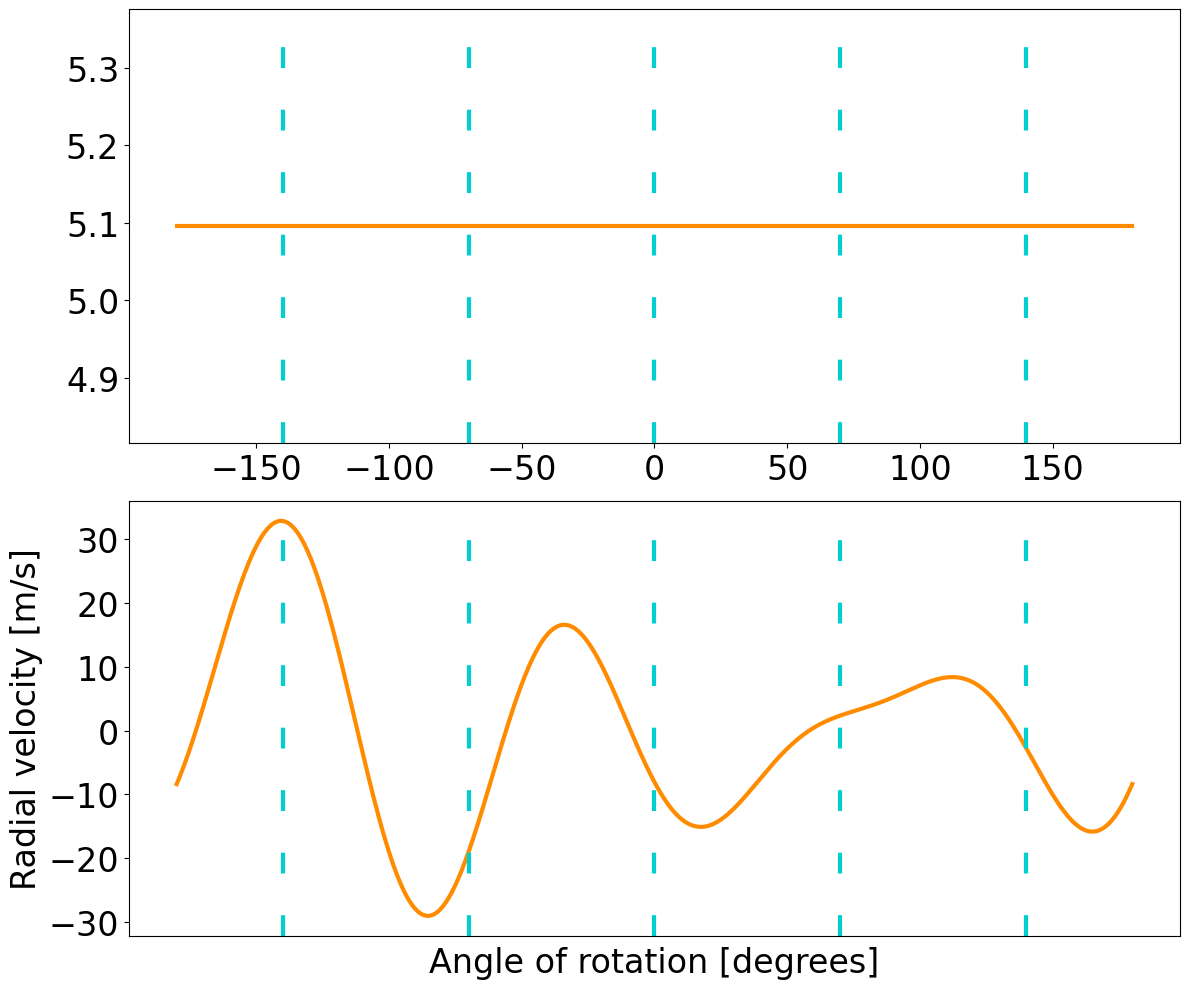

In [84]:
width_line = 3
tick_size = 24

fig, axes = plt.subplots(nrows=2, ncols=1, squeeze=False,
                                    sharex=False, sharey=False, figsize=(12, 10))

# Plot the flux
axes[0,0].plot(theta, realistic_star.map.flux(theta=theta).eval(),c="darkorange",linewidth=width_line)
for i in range(-140,141,70):
    axes[0,0].axvline(i,c="darkturquoise",ls=(0, (5, 10)),alpha=1,linewidth=width_line)
# plt.xlabel("Angle of rotation [degrees]", fontsize=24)
# plt.ylabel("Flux [normalized]", fontsize=24)
axes[0,0].tick_params(axis='both', labelsize=tick_size) 



# Plot the radial velocity
axes[1,0].plot(theta, realistic_star.map.rv(theta=theta).eval(),c="darkorange",linewidth=width_line)
for i in range(-140,141,70):
    axes[1,0].axvline(i,c="darkturquoise",ls=(0, (5, 10)),alpha=1,linewidth=width_line)
plt.xlabel("Angle of rotation [degrees]", fontsize=24)
plt.ylabel("Radial velocity [m/s]", fontsize=24)
axes[1,0].set_xticks([])
plt.xticks(fontsize=tick_size)
plt.yticks(fontsize=tick_size)
plt.tight_layout()
plt.savefig(f"GLEAM Poster/comb_curve.png", dpi = 300, transparent=True)
plt.show()
plt.close()

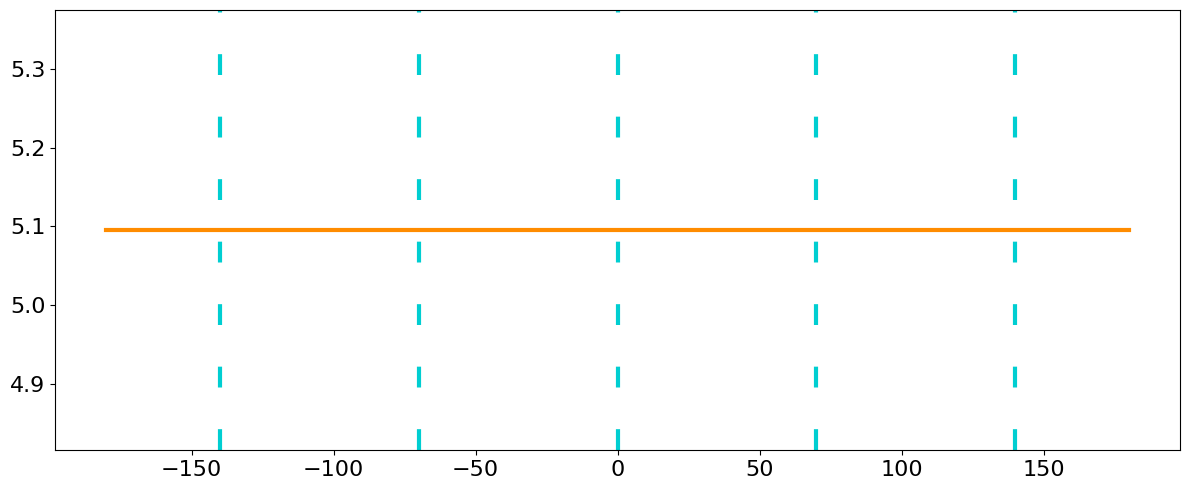

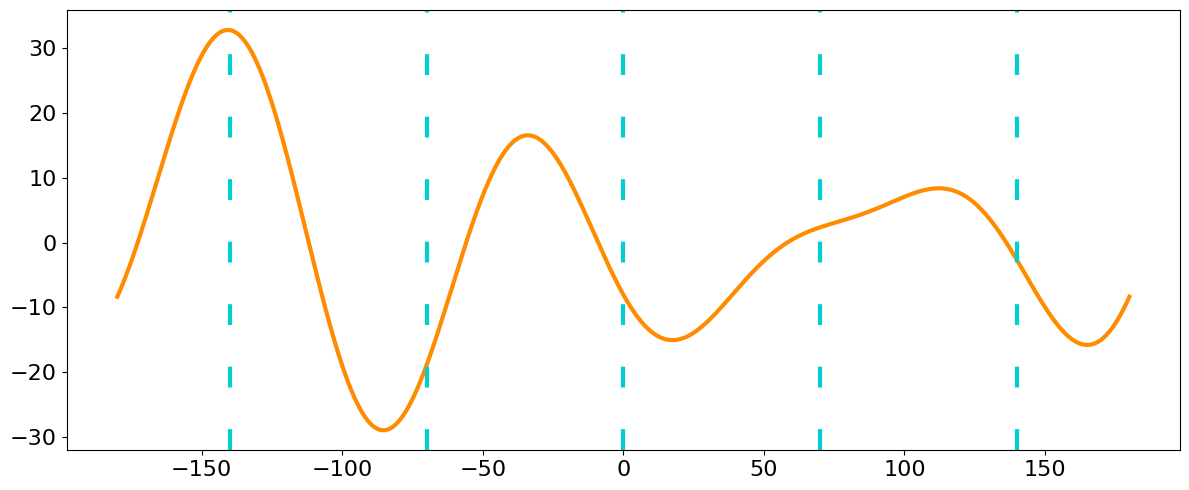

In [59]:
width_line = 3
tick_size = 16



# Plot the flux
plt.figure(figsize=(12, 5))
plt.plot(theta, realistic_star.map.flux(theta=theta).eval(),c="darkorange",linewidth=width_line)
for i in range(-140,141,70):
    plt.axvline(i,c="darkturquoise",ls=(0, (5, 10)),alpha=1,linewidth=width_line)
# plt.xlabel("Angle of rotation [degrees]", fontsize=24)
# plt.ylabel("Flux [normalized]", fontsize=24)
plt.xticks(fontsize=tick_size)
plt.yticks(fontsize=tick_size)
plt.tight_layout()
plt.savefig(f"GLEAM Poster/flux_curve.png", dpi = 300, transparent=True)
plt.show()
plt.close()


# Plot the radial velocity
plt.figure(figsize=(12, 5))
plt.plot(theta, realistic_star.map.rv(theta=theta).eval(),c="darkorange",linewidth=width_line)
for i in range(-140,141,70):
    plt.axvline(i,c="darkturquoise",ls=(0, (5, 10)),alpha=1,linewidth=width_line)
# plt.xlabel("Angle of rotation [degrees]", fontsize=24)
# plt.ylabel("Radial velocity [m/s]", fontsize=24)
plt.xticks(fontsize=tick_size)
plt.yticks(fontsize=tick_size)
plt.tight_layout()
plt.savefig(f"GLEAM Poster/rv_curve.png", dpi = 300, transparent=True)
plt.show()
plt.close()

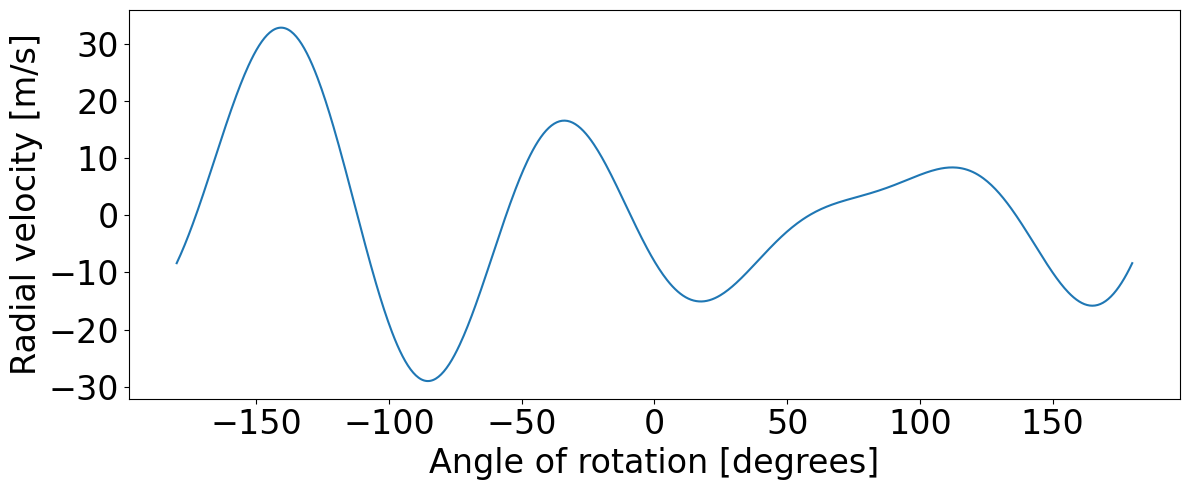

In [94]:
# Plot the radial velocity
plt.figure(figsize=(12, 5))
plt.plot(theta, realistic_star.map.rv(theta=theta).eval())
plt.xlabel("Angle of rotation [degrees]", fontsize=24)
plt.ylabel("Radial velocity [m/s]", fontsize=24)
plt.xticks(fontsize=tick_size)
plt.yticks(fontsize=tick_size)
plt.tight_layout()
plt.show()

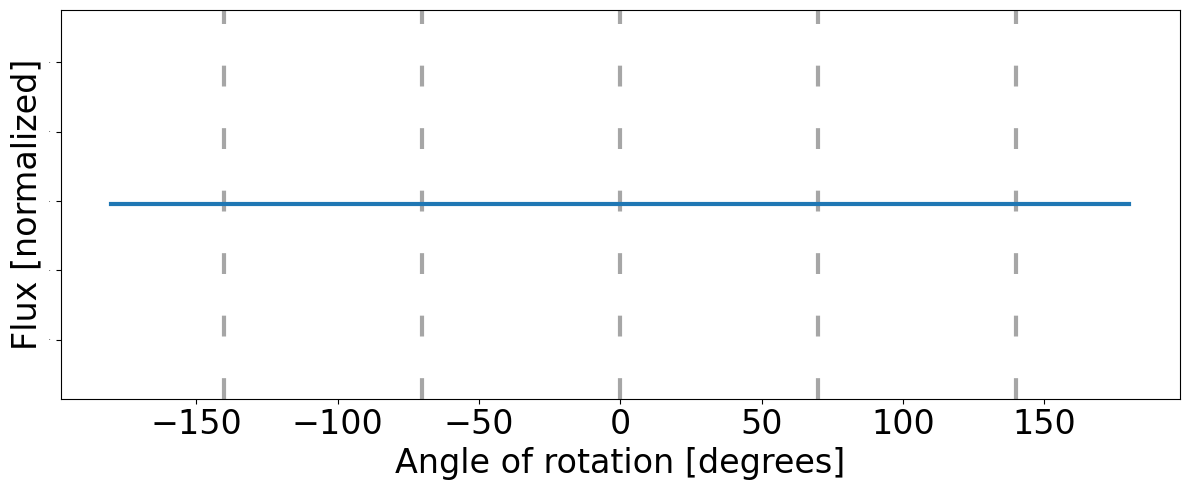

In [100]:
# Plot the radial velocity
plt.figure(figsize=(12, 5))
for i in range(-140,141,70):
    plt.axvline(i,c="grey",ls=(0, (5, 10)),alpha=.7,linewidth=width_line)
plt.plot(theta, realistic_star.map.flux(theta=theta).eval(),linewidth=width_line)
plt.xlabel("Angle of rotation [degrees]", fontsize=24)
plt.ylabel("Flux [normalized]", fontsize=24)
plt.xticks(fontsize=tick_size)
plt.yticks(fontsize=0)
plt.tight_layout()
plt.show()

In [60]:

for i in range(-140,141,70):
    print(i)
    realistic_star.map.show(rv=False,theta=i,file=f"GLEAM Poster/flux_map_{i}.png", transparent=True)
    # realistic_star.map.show(rv=True,theta=i)

for i in range(-140,141,70):
    print(i)
    # realistic_star.map.show(rv=False,theta=i)
    # plt.title(f"{rv_star.map.flux(theta=i).eval()[0]:.3f}")
    realistic_star.map.show(rv=True,theta=i,file=f"GLEAM Poster/rv_map_{i}.png", transparent=True)
    print(realistic_star.map.rv(theta=i).eval())

-140
-70
0
70
140
-140
[32.836224]
-70
[-18.96275778]
0
[-8.06191351]
70
[2.35628368]
140
[-2.69952769]


In [82]:
new_theta = np.linspace(0,360,90)


create_rv.map_curve_ani(realistic_star,new_theta,cbar_pos="bottom",fname="AAS Presentation/all_ani.gif")

MovieWriter imagemagick unavailable; using Pillow instead.


In [81]:
realistic_star.map.show(theta=new_theta,rv=False,file="AAS Presentation/flux_ani_no_back.gif",transparent=True)

MovieWriter imagemagick unavailable; using Pillow instead.


27 0.75
29 0.8055555555555556
25 0.6944444444444444


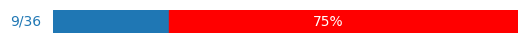

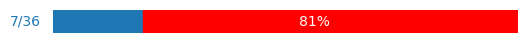

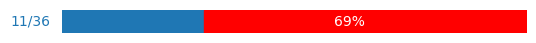

In [62]:
def compute_info(A):
    """Compute some information about the null space of the design matrix A."""
    # Get the Fisher information & compute its rank
    I = A.T.dot(A).eval()
    R = np.linalg.matrix_rank(I)

    # Number of coefficientss
    C = I.shape[0]

    # Size of null space
    N = C - R

    # Fractional size of null space
    F = N / C


    print(N,F)


    # Show it graphically
    fig, ax = plt.subplots(figsize=(6, 0.3))
    ax.set_xlim(0, 1)
    ax.axis("off")
    ax.axvspan(0, 1 - F, color="C0")
    ax.axvspan(1 - F, 1, color="red")
    ax.annotate(
        "{}/{}".format(R, C),
        color="C0",
        fontsize=10,
        xy=(-0.025, 0.5),
        xycoords="axes fraction",
        va="center",
        ha="right",
    )
    ax.annotate(
        "{:.0f}%".format(100 * F),
        color="w",
        fontsize=10,
        xy=(1 - 0.5 * F, 0.5),
        xycoords="axes fraction",
        va="center",
        ha="right",
    )

map = starry.Map(5)
map.inc = 60
A = map.design_matrix(theta=theta)
compute_info(A)

map.inc=90
A = map.design_matrix(theta=theta)
compute_info(A)

map = starry.Map(5,1)
map[1] = 0.5
map.inc=70
A = map.design_matrix(theta=theta)
compute_info(A)

In [63]:
# e_i = "16"

# eigeny_again = np.loadtxt(f"eridani-outputs/pos-pca-full-5-quad_limb-results-70i/realistic_outputs/null_map_{e_i}/null_map_eigeny.txt")


# uni_comp, uni_value, ratio_below, ratio_above, corrected_amp = np.loadtxt(f"eridani-outputs/pos-pca-full-5-quad_limb-results-70i/realistic_outputs/null_map_{e_i}/null_map_data.txt")

In [64]:
# corrected_amp = 8.218175245069607726e-01

In [65]:
# realistic_star = utils.initstar(fit, lmax, udeg=udeg, include_rv=True)

In [66]:
# realistic_star.map[:,:] = eigeny_again

# realistic_star.map.amp = corrected_amp

In [74]:
# realistic_star.map.amp = 1

# realistic_star.map.show(rv=False,projection="rect",colorbar=True)

# realistic_star.map.amp = corrected_amp

In [68]:
# # Plot the flux
# plt.figure(figsize=(12, 5))
# plt.plot(theta, realistic_star.map.flux(theta=theta).eval(),c="darkorange")
# for i in range(-140,141,70):
#     plt.axvline(i,c="darkturquoise",ls=(0, (5, 10)),alpha=1)
# plt.xlabel("Angle of rotation [degrees]", fontsize=24)
# plt.ylabel("Flux [normalized]", fontsize=24)
# plt.tight_layout()
# plt.show()
# plt.close()


# # Plot the radial velocity
# plt.figure(figsize=(12, 5))
# plt.plot(theta, realistic_star.map.rv(theta=theta).eval(),c="darkorange")
# for i in range(-140,141,70):
#     plt.axvline(i,c="darkturquoise",ls=(0, (5, 10)),alpha=1)
# plt.xlabel("Angle of rotation [degrees]", fontsize=24)
# plt.ylabel("Radial velocity [m/s]", fontsize=24)
# plt.tight_layout()
# plt.show()
# plt.close()

In [69]:

# for i in range(-140,141,70):
#     print(i)
#     realistic_star.map.show(rv=False,theta=i)
#     # realistic_star.map.show(rv=True,theta=i)

# for i in range(-140,141,70):
#     print(i)
#     # realistic_star.map.show(rv=False,theta=i)
#     # plt.title(f"{rv_star.map.flux(theta=i).eval()[0]:.3f}")
#     realistic_star.map.show(rv=True,theta=i)
#     print(realistic_star.map.rv(theta=i).eval())

In [70]:
# realistic_star.map[:,:] += eigeny_21

In [71]:
# Plot the flux
# plt.figure(figsize=(12, 5))
# plt.plot(theta, realistic_star.map.flux(theta=theta).eval(),c="darkorange")
# for i in range(-140,141,70):
#     plt.axvline(i,c="darkturquoise",ls=(0, (5, 10)),alpha=1)
# plt.xlabel("Angle of rotation [degrees]", fontsize=24)
# plt.ylabel("Flux [normalized]", fontsize=24)
# plt.tight_layout()
# plt.show()
# plt.close()


# # Plot the radial velocity
# plt.figure(figsize=(12, 5))
# plt.plot(theta, realistic_star.map.rv(theta=theta).eval(),c="darkorange")
# for i in range(-140,141,70):
#     plt.axvline(i,c="darkturquoise",ls=(0, (5, 10)),alpha=1)
# plt.xlabel("Angle of rotation [degrees]", fontsize=24)
# plt.ylabel("Radial velocity [m/s]", fontsize=24)
# plt.title("Combined Map RV",fontsize=24)
# plt.tight_layout()
# plt.show()
# plt.close()

In [72]:
# lmax = 15
# nsamples = 100
# np.random.seed(0)

# # Compute the rank as a function of sph harm degree
# # We'll do this for various inclinations and take
# # the median.
# map = starry.Map(lmax, lazy=False)
# theta = np.linspace(0, 360, 1000)
# R = np.empty((nsamples, lmax))
# for k in range(nsamples):
#     map.inc = 180 / np.pi * np.arccos(np.random.uniform(0, 1))
#     A = map.design_matrix(theta=theta)
#     R[k] = [
#         np.linalg.matrix_rank(A[:, : (l + 1) ** 2]) for l in range(1, lmax + 1)
#     ]
# R = np.median(R, axis=0)

# # Show that the rank is just...
# Rfunc = lambda l: np.maximum(3, 4 * np.floor(l / 2) + 1)
# l = np.arange(1, lmax + 1)
# assert np.allclose(R, Rfunc(l))



In [196]:
bad_eigeny = np.loadtxt("eridani-outputs/pos-pca-full-5-quad_limb-results-70i/stored-eigens/eigeny.txt")[-4]

In [197]:
# bad_eigeny[-4]

In [198]:
bad_star = utils.initstar(fit, lmax, udeg=udeg, include_rv=True)

In [199]:
bad_star.map[:,:] = bad_eigeny

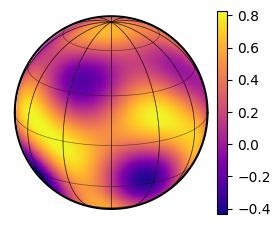

In [200]:
bad_star.map.show(rv=False,colorbar=True)

In [201]:
bad_star.map.show(theta=new_theta,rv=False,file="AAS Presentation/bad_ani_no_back.gif",transparent=True,colorbar="bottom",dpi=330)

MovieWriter imagemagick unavailable; using Pillow instead.


In [202]:
realistic_star.map.show(theta=new_theta,rv=False,file="AAS Presentation/good_ani_no_back.gif",transparent=True,colorbar="bottom",dpi=330)

MovieWriter imagemagick unavailable; using Pillow instead.


In [204]:
bad_star.map[:,:] = bad_eigeny
bad_star.map.minimize()[-1].eval()

array(-0.72997054)

In [185]:
bad_star.map.show(rv=False,theta=new_theta,colorbar="bottom")

In [166]:
expected = 0.31830989

In [172]:
# expected - (-.)